In [1]:
import matplotlib.pyplot as plt
import uproot4 as uproot
import pandas as pd
import numpy as np
import math
from tqdm import tqdm
import scipy.optimize
from scipy.optimize import curve_fit
import random
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)


In [2]:
#Variables that are loaded directly out of the files.
#There are more here than are needed for these compasisons, they can be removed if memory becomes an issue.
bdt_vars = [
    "mip_energy",
    "mip_angle_beam", 
    "spt_angle_vertical",
    "nue_score", 
    "numu_score", 
    "numu_cc_flag",
    "numu_1_score",
    "numu_cc_3_track_length",
    "numu_cc_3_max_length_all",
    "cosmict_2_dQ_dx_front",
    "cosmict_2_dQ_dx_end",
    "cosmict_2_angle_beam",
    "cosmict_2_phi",
    "numu_cc_3_max_length",
    "numu_cc_3_max_muon_length",

    "numu_cc_flag_1",
    "numu_cc_flag_2",
    "numu_cc_flag_3",
    "cosmict_flag",
    
    "numu_cc_1_length",
    "numu_cc_1_direct_length",
    "numu_cc_2_length",
    "numu_cc_2_total_length",

    #"nc_pio_score"
]

bdt_vars_slim = [
    "mip_energy",
    "mip_angle_beam", 
    "spt_angle_vertical",
    "nue_score", 
    "numu_score", 
    "numu_cc_flag",
    "numu_1_score",
    "numu_cc_3_track_length",
    "numu_cc_3_max_length_all",
    "cosmict_2_dQ_dx_front",
    "cosmict_2_dQ_dx_end",
    "cosmict_2_angle_beam",
    "cosmict_2_phi",
    "numu_cc_3_max_length",
    "numu_cc_3_max_muon_length",

    "numu_cc_flag_1",
    "numu_cc_flag_2",
    "numu_cc_flag_3",
    "cosmict_flag",
    
    "numu_cc_1_length",
    "numu_cc_1_direct_length",
    "numu_cc_2_length",
    "numu_cc_2_total_length",

    #"nc_pio_score"
]

kine_vars_data = ["kine_particle_type", "kine_energy_particle", "kine_reco_add_energy", "kine_energy_info",
                 "kine_pio_mass",
                    "kine_pio_flag",
                    "kine_pio_vtx_dis",
                    "kine_pio_energy_1",
                    "kine_pio_theta_1",
                    "kine_pio_phi_1",
                    "kine_pio_dis_1",
                    "kine_pio_energy_2",
                    "kine_pio_theta_2",
                    "kine_pio_phi_2",
                    "kine_pio_dis_2",
                    "kine_pio_angle"]
kine_vars = ["kine_particle_type", "kine_energy_particle", "kine_reco_add_energy", "kine_energy_info"]
pf_eval_data_variables = ["reco_muonMomentum","reco_protonMomentum",'reco_nuvtxX', 'reco_nuvtxY', 'reco_nuvtxZ', 'reco_Nproton', 'reco_Ntrack', 'reco_id', 
                          'reco_pdg','reco_mother','reco_startMomentum', 'reco_endMomentum','reco_startXYZT','reco_endXYZT', 'reco_showervtxX', 
                          'reco_showervtxY', 'reco_showervtxZ', 'reco_showerKE', 'reco_muonvtxX', 'reco_muonvtxY', 'reco_muonvtxZ', 'reco_showerMomentum',
                          'reco_process', 'reco_daughters', 'PMT_ID', "RWM_Time","PMT_TimeProp","PMT_Amp","PMT_Time", "reco_sps_x","reco_sps_y","reco_sps_z"]

pf_eval_mc_variables = ["truth_nuEnergy", "truth_nu_pos", "truth_nuPdg", "truth_nuScatType", "truth_nu_momentum", "truth_vtxX", "truth_vtxY", "truth_vtxZ", "truth_nuTime", "truth_isCC",
                        "truth_muonMomentum", "truth_muonvtxX", "truth_muonvtxY", "truth_muonvtxZ",
                        "truth_muonendX", "truth_muonendY", "truth_muonendZ", "truth_startMomentum", "truth_endMomentum","mcflux_vx", "mcflux_vy", "mcflux_vz",
                        "cor_nu_time", "cor_nu_time_spill", "cor_nu_time_nospill", "cor_nu_deltatime", 'mcflux_dk2gen', 'mcflux_gen2vtx']

eval_data_variables = [
    "run",
    "subrun",
    "event",
    'flash_found', 
    'flash_time', 
    'flash_found_asInt', 'match_found_asInt', 
    'flash_measPe', 'flash_predPe', 
    'match_found', 'match_type', 'match_isFC', 'match_isTgm', 'match_notFC_FV', 'match_notFC_SP','match_notFC_DC', 'match_chargeU', 'match_chargeV', 'match_chargeY', 'match_energyY', 'light_mismatch', 'match_charge', 'match_energy', 
    'stm_eventtype', 'stm_lowenergy', 'stm_LM', 'stm_TGM', 'stm_STM', 'stm_FullDead', 'stm_clusterlength']


eval_data_variables_notbool = [
'flash_time', 
'stm_clusterlength'
 ]

eval_data_variables_energy = [
'match_energyY',
 'match_energy']

eval_data_variables_pe = [
'flash_measPe', 'flash_predPe']

eval_data_variables_charge = [
'match_chargeU', 'match_chargeV', 'match_chargeY','match_charge']

eval_data_variables_cat = [
'match_type','stm_eventtype']

eval_data_variables_bool = [
'flash_found','flash_found_asInt', 'match_found_asInt','match_found','match_isFC',
'match_isTgm', 'match_notFC_FV', 'match_notFC_SP','match_notFC_DC','light_mismatch',
'stm_lowenergy', 'stm_LM', 'stm_TGM', 'stm_STM', 'stm_FullDead']

# Load In Data + MC

In [3]:
def load_numi_data(numi_data_file):
    numi_data_file = uproot.open(numi_data_file)
    f_data_run1 = numi_data_file["wcpselection"]
    f_data_run1_bdt = f_data_run1["T_BDTvars"].arrays(bdt_vars_slim, library='pd')
    f_data_run1_eval = f_data_run1["T_eval"].arrays(eval_data_variables, library='pd')
    f_data_run1_pfeval = f_data_run1["T_PFeval"].arrays(["evtTimeNS"]+pf_eval_data_variables, library='pd')
    f_data_run1_kine = f_data_run1["T_KINEvars"].arrays(kine_vars_data, library='pd')
    f_data_run1B_pot = f_data_run1["T_pot"].arrays(["pot_tor875good","runNo",'subRunNo'], library='pd')
    data_run1B_pot = np.sum(f_data_run1B_pot["pot_tor875good"].to_numpy())
    print(data_run1B_pot)
    df_numi_data = pd.concat([f_data_run1_bdt, f_data_run1_eval, f_data_run1_pfeval, f_data_run1_kine], axis=1, sort=False)
    del f_data_run1
    del f_data_run1_bdt
    del f_data_run1_eval
    del f_data_run1_pfeval
    del f_data_run1_kine

    df_numi_data["rse_num"] = (df_numi_data["run"].astype("object") * 100_000_000_000
                            + df_numi_data["subrun"].astype("object") * 1_000_000
                            + df_numi_data["event"].astype("object"))

    print(df_numi_data.shape[0])
    df_numi_data = df_numi_data.drop_duplicates(subset=['rse_num']).reset_index()
    df_numi_data = df_numi_data.query("evtTimeNS>0")
    print(df_numi_data.shape[0])

    #Set a variable saying this is not EXT data
    df_numi_data["isEXT"] = [0 for i in range(df_numi_data.shape[0])]
    #Set a variable saying this is not a dirt overlay
    df_numi_data["isDirt"] = [0 for i in range(df_numi_data.shape[0])]
    #Set a variable indicating the file type
    df_numi_data["category"] = ["data" for i in range(df_numi_data.shape[0])]
    #Set a vairable saying which run number this is.
    #You can cut on this variable to do un by run comparisons.
    df_numi_data["run_num"] = [2 for i in range(df_numi_data.shape[0])]
    
    return df_numi_data


df_numi_data = load_numi_data("small/SURPRISE_Test_Samples_v10_04_07_05_Run4b_wirecell_standalone_reco2_numi_beam_on_reco2_hist_goodruns_62221095_snapshot_goodruns.root")


1349891.896221813
242390
11496


C:\Users\andre\AppData\Local\Temp\ipykernel_21952\2090180874.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_numi_data["isEXT"] = [0 for i in range(df_numi_data.shape[0])]
C:\Users\andre\AppData\Local\Temp\ipykernel_21952\2090180874.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_numi_data["isDirt"] = [0 for i in range(df_numi_data.shape[0])]
C:\Users\andre\AppData\Local\Temp\ipykernel_21952\2090180874.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

In [4]:
def load_numi_mc(numi_data_file):
    numi_data_file = uproot.open(numi_data_file)
    f_data_run1 = numi_data_file["wcpselection"]
    f_data_run1_bdt = f_data_run1["T_BDTvars"].arrays(bdt_vars_slim, library='pd')
    f_data_run1_eval = f_data_run1["T_eval"].arrays(eval_data_variables, library='pd')
    f_data_run1_pfeval = f_data_run1["T_PFeval"].arrays(["evtTimeNS_cor"]+pf_eval_data_variables + pf_eval_mc_variables, library='pd')
    f_data_run1_kine = f_data_run1["T_KINEvars"].arrays(kine_vars_data, library='pd')
    f_data_run1B_pot = f_data_run1["T_pot"].arrays(["pot_tor875good","runNo",'subRunNo'], library='pd')
    data_run1B_pot = np.sum(f_data_run1B_pot["pot_tor875good"].to_numpy())
    print(data_run1B_pot)
    df_numi_data = pd.concat([f_data_run1_bdt, f_data_run1_eval, f_data_run1_pfeval, f_data_run1_kine], axis=1, sort=False)
    del f_data_run1
    del f_data_run1_bdt
    del f_data_run1_eval
    del f_data_run1_pfeval
    del f_data_run1_kine

    df_numi_data["rse_num"] = (df_numi_data["run"].astype("object") * 100_000_000_000
                            + df_numi_data["subrun"].astype("object") * 1_000_000
                            + df_numi_data["event"].astype("object"))

    print(df_numi_data.shape[0])
    df_numi_data = df_numi_data.drop_duplicates(subset=['rse_num']).reset_index()
    df_numi_data = df_numi_data.query("evtTimeNS_cor>0")
    print(df_numi_data.shape[0])

    #Set a variable saying this is not EXT data
    df_numi_data["isEXT"] = [0 for i in range(df_numi_data.shape[0])]
    #Set a variable saying this is not a dirt overlay
    df_numi_data["isDirt"] = [0 for i in range(df_numi_data.shape[0])]
    #Set a variable indicating the file type
    df_numi_data["category"] = ["data" for i in range(df_numi_data.shape[0])]
    #Set a vairable saying which run number this is.
    #You can cut on this variable to do un by run comparisons.
    df_numi_data["run_num"] = [2 for i in range(df_numi_data.shape[0])]

    return df_numi_data


df_numi_mc = load_numi_mc("small/SURPRISE_Test_Samples_v10_04_07_05_Run4b_wirecell_standalone_reco2_NuMI_nu_overlay_reco2_hist.root")


1.9191267070975214e+20
50603
15857


C:\Users\andre\AppData\Local\Temp\ipykernel_21952\2322722704.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_numi_data["isEXT"] = [0 for i in range(df_numi_data.shape[0])]
C:\Users\andre\AppData\Local\Temp\ipykernel_21952\2322722704.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_numi_data["isDirt"] = [0 for i in range(df_numi_data.shape[0])]
C:\Users\andre\AppData\Local\Temp\ipykernel_21952\2322722704.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

In [5]:
#merge everything into a single peak
#you may have to play around with Shift to get things aligned at 0
numi_gap = 18.831
evtTimeNS = df_numi_data["evtTimeNS"].to_numpy()

new_times = []

for i in range(len(evtTimeNS)):
    
    if np.nan_to_num(evtTimeNS[i],nan=-999999,posinf=-999999,neginf=-999999)<=0:
        new_times.append(-9999)
        continue  
        
    gap=numi_gap
    Shift=0.5073
    TThelp=0

    TThelp = evtTimeNS[i]-Shift+gap*0.5

    TT_merged=(TThelp-(int((TThelp)/gap))*gap)-gap*0.5
        
    new_times.append(TT_merged)

df_numi_data["merge_time"] = new_times

In [6]:
#merge everything into a single peak
#you may have to play around with Shift to get things aligned at 0
numi_gap = 18.831
evtTimeNS = df_numi_mc["evtTimeNS_cor"].to_numpy()

new_times = []

for i in range(len(evtTimeNS)):
    
    if np.nan_to_num(evtTimeNS[i],nan=-999999,posinf=-999999,neginf=-999999)<=0:
        new_times.append(-9999)
        continue  
        
    gap=numi_gap
    Shift=7.1347
    TThelp=0

    TThelp = evtTimeNS[i]-Shift+gap*0.5

    TT_merged=(TThelp-(int((TThelp)/gap))*gap)-gap*0.5
        
    new_times.append(TT_merged)

df_numi_mc["merge_time"] = new_times

# Define Functions

In [7]:
#Used for performing the guassian fit
def gaus(x,a,x0,sigma, offset):
    return a*np.exp(-(x-x0)**2/(2*sigma**2)) + offset

#helper function to get bin centers
def get_bin_centers(x):
    centers = []
    for i in range(len(x)-1): centers.append( x[i] + (x[i+1]-x[i])/2 )
    return centers

#function to calculate the angle wrt the beam
def get_angle(momentum_0,momentum_1,momentum_2):
    momentum_perp = np.sqrt(momentum_0 * momentum_0 + momentum_1 * momentum_1)
    # defined in https://root.cern/doc/master/TVector3_8cxx_source.html
    theta = np.arctan2(momentum_perp, momentum_2)
    phi = np.arctan2(momentum_0, momentum_1)
    return theta, phi



In [8]:
global_query = "merge_time>-9.42 and merge_time<9.42 and numu_score>0.9"

def get_stats(df, query, x_var, merge_time_col, bins, nbins):
    xvar_full_list =  df.query(query)[x_var].to_numpy()
    weight_list =  np.ones_like(df.query(query)[x_var].to_numpy())
    merge_time =  df.query(query)[merge_time_col].to_numpy()

    data = []
    data_weights = []
    means_CCpi0 = []
    mean_errors_CCpi0 = []
    stds_CCpi0 = []
    std_errors_CCpi0 = []

    for i in range(len(bins)-1):
        data.append([])
        data_weights.append([])   

    for event in tqdm(range(len(xvar_full_list))):
        for i in range(len(bins)-1):
            lo = bins[i]
            hi = 0
            if i==len(bins)-2: hi=1000000
            else: hi = bins[i+1]
            if(xvar_full_list[event]>=lo and xvar_full_list[event]<hi):
                data[i].append(merge_time[event])
                data_weights[i].append(weight_list[event])

        
    for i in range(len(bins)-1):

        y,xbins = np.histogram(data[i],bins=nbins,range=(-9.42, 9.42),weights=data_weights[i])
        
        x = get_bin_centers(xbins)
        means_CCpi0.append(np.sum(x*y)/np.sum(y))
        mean_errors_CCpi0.append(np.sqrt(np.sum(y)/np.sum(y)**2))
        stds_CCpi0.append(np.sqrt(np.sum(y*(x-means_CCpi0[-1])**2)/np.sum(y)))
        std_errors_CCpi0.append(np.sqrt(np.sum(y*(x-means_CCpi0[-1])**2)/np.sum(y)**2))
    return means_CCpi0, mean_errors_CCpi0, stds_CCpi0, std_errors_CCpi0
    
#Definitions for some slections and signals that are usefull to examine

em_charge_scale = 0.95

#numucc signal
sig_query = "truth_isCC==1 and truth_nuPdg==14"
#numucc selection
sel_query = "numu_cc_flag>=0 and numu_score > 0.9"
# "NC" selection. mostly just the base for the cut based NCpi0 selection
NC_query = "cosmict_flag==0 and numu_score < 0"
#CC pi0 cut based selection
CCpi0_query = sel_query + ' and ((kine_pio_vtx_dis < 9 ) and kine_pio_energy_1* @em_charge_scale > 40 and kine_pio_energy_2* @em_charge_scale > 25 and kine_pio_dis_1 < 110 and kine_pio_dis_2 < 120 and kine_pio_angle > 0 and kine_pio_angle < 174  and pio_mass > 22 and pio_mass < 300)'
#NC pi0 cut based selection
NCpi0_query = NC_query + ' and ((kine_pio_flag==1 and kine_pio_vtx_dis < 9 or kine_pio_flag==2) and kine_pio_energy_1* em_charge_scale > 40 and kine_pio_energy_2* em_charge_scale > 25 and kine_pio_dis_1 < 110 and kine_pio_dis_2 < 120 and kine_pio_angle > 0 and kine_pio_angle < 174  and pio_mass > 22 and pio_mass < 300)'
#CC+NC pi0 cut based selection
pi0_query = '((kine_pio_flag==1 and kine_pio_vtx_dis < 9 or kine_pio_flag==2) and kine_pio_energy_1* em_charge_scale > 40 and kine_pio_energy_2* em_charge_scale > 25 and kine_pio_dis_1 < 110 and kine_pio_dis_2 < 120 and kine_pio_angle > 0 and kine_pio_angle < 174  and pio_mass > 22 and pio_mass < 300)'
#NC pi0 BDT based selection
NCpi0_bdt_query = 'nc_pio_score > 1.816 and kine_pio_energy_1 > 0 and kine_pio_energy_2 > 0'

In [9]:
def scaling_recalc(data_run4b_super_df):
    
    em_charge_scale = 0.95
    data_run4b_super_df["pio_mass"] = data_run4b_super_df['kine_pio_mass'].to_numpy()* em_charge_scale
    data_run4b_super_df["em_charge_scale"] = np.ones_like(data_run4b_super_df['kine_pio_mass'].to_numpy())* em_charge_scale
    
    #Get the reconstructed neutrino energy, for data we need to apply a scaling to the shower energy
    corrected_kine_reco_Enus = []
    energy_info_lists = data_run4b_super_df["kine_energy_info"].to_numpy()
    energy_lists = data_run4b_super_df["kine_energy_particle"].to_numpy()
    pdg_lists = data_run4b_super_df["kine_particle_type"].to_numpy()
    add_energies = data_run4b_super_df["kine_reco_add_energy"].to_numpy()
    for i in tqdm(range(data_run4b_super_df.shape[0])):
        corrected_kine_reco_Enu = 0.
        energy_list = energy_lists[i]
        pdg_list = pdg_lists[i]
        energy_info_list = energy_info_lists[i]
        for j in range(len(energy_list)):
            if energy_info_list[j] == 2 and pdg_list[j] == 11:
                corrected_kine_reco_Enu += em_charge_scale * energy_list[j]
            else:
                corrected_kine_reco_Enu += energy_list[j]
        corrected_kine_reco_Enu += add_energies[i]
        
        corrected_kine_reco_Enus.append(corrected_kine_reco_Enu) 

    data_run4b_super_df["kine_reco_Enu"] = corrected_kine_reco_Enus

    

    #get the muon and leading proton info out of the pfeval tree
    mu = data_run4b_super_df["reco_muonMomentum"].to_numpy()
    
    '''mu0 = data_run4b_super_df["reco_muonMomentum[0]"].to_numpy()
    mu1 = data_run4b_super_df["reco_muonMomentum[1]"].to_numpy()
    mu2 = data_run4b_super_df["reco_muonMomentum[2]"].to_numpy()
    mu3 = data_run4b_super_df["reco_muonMomentum[3]"].to_numpy()

    p0 = data_run4b_super_df["reco_protonMomentum[0]"].to_numpy()
    p1 = data_run4b_super_df["reco_protonMomentum[1]"].to_numpy()
    p2 = data_run4b_super_df["reco_protonMomentum[2]"].to_numpy()
    p3 = data_run4b_super_df["reco_protonMomentum[3]"].to_numpy()'''

    
    p = data_run4b_super_df["reco_protonMomentum"].to_numpy()

    kine_reco_Enu = data_run4b_super_df["kine_reco_Enu"].to_numpy()

    mu_thetas = []
    mu_phis = []
    mu_costhetas = []
    mu_cosphis = []
    reco_Emuon = []

    p_thetas = []
    p_phis = []
    p_costhetas = []
    p_cosphis = []
    reco_Eproton = []

    Ehadron = []

    print(len(mu))

    for i in range(len(mu)):
        if(mu[i][3]<=0): 
            mu_theta = np.nan
            mu_phi = np.nan
            Ehadron.append(kine_reco_Enu[i])
        else: 
            mu_theta, mu_phi = get_angle(mu[i][0], mu[i][1], mu[i][2])
            Ehadron.append(kine_reco_Enu[i]-mu[i][3]*1000)
        mu_thetas.append(mu_theta)
        mu_phis.append(mu_phi)
        mu_costhetas.append(np.cos(mu_theta))
        mu_cosphis.append(np.cos(mu_phi))
        reco_Emuon.append(mu[i][3]*1000)
        
        if(p[i][3]<=0): 
            p_theta = np.nan
            p_phi = np.nan
            reco_Eproton.append(0)
            
        else: 
            p_theta, p_phi = get_angle(p[i][0], p[i][1], p[i][2])
            reco_Eproton.append(p[i][3]*1000-938.27)
        p_thetas.append(p_theta)
        p_phis.append(p_phi)
        p_costhetas.append(np.cos(p_theta))
        p_cosphis.append(np.cos(p_phi))
        
        
        
        
    print(len(data_run4b_super_df))
    print(len(mu_thetas), len(mu_phis), len(mu_costhetas), len(reco_Emuon))

    data_run4b_super_df["reco_muon_theta"] = mu_thetas
    data_run4b_super_df["reco_muon_phi"] = mu_phis
    data_run4b_super_df["reco_muon_costheta"] = mu_costhetas
    data_run4b_super_df["reco_muon_cosphi"] = mu_cosphis 
    data_run4b_super_df["reco_Emuon"] = reco_Emuon

    data_run4b_super_df["reco_proton_theta"] = p_thetas
    data_run4b_super_df["reco_proton_phi"] = p_phis
    data_run4b_super_df["reco_proton_costheta"] = p_costhetas
    data_run4b_super_df["reco_proton_cosphi"] = p_cosphis 
    data_run4b_super_df["reco_Eproton"] = reco_Eproton

    data_run4b_super_df["Ehadron"] = Ehadron

scaling_recalc(df_numi_data)
scaling_recalc(df_numi_mc)

100%|██████████| 11496/11496 [00:00<00:00, 677748.21it/s]


11496
11496
11496 11496 11496 11496


100%|██████████| 15857/15857 [00:00<00:00, 605690.70it/s]


15857
15857
15857 15857 15857 15857


numuCC: Gaussian      mean: 0.0778   std: 2.6905   C: 0.0588
CCpi0: Gaussian      mean: 0.0069   std: 0.2211   C: 0.1235
NCpi0: Gaussian      mean: 1.0083   std: 0.1211   C: 0.2
loose nueCC: Gaussian      mean: 0.4123   std: 3.0733   C: 0.0316


C:\Users\andre\AppData\Local\Temp\ipykernel_21952\953424195.py:18: OptimizeWarning: Covariance of the parameters could not be estimated
  popt2, pcov2 = curve_fit(gaus, x2, y2 / norm2)
C:\Users\andre\AppData\Local\Temp\ipykernel_21952\953424195.py:25: OptimizeWarning: Covariance of the parameters could not be estimated
  popt3, pcov3 = curve_fit(gaus, x3, y3 / norm3)


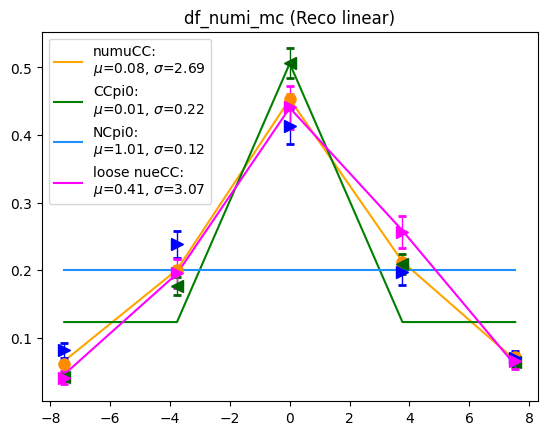

numuCC: Gaussian      mean: -0.0167   std: 3.0498   C: 0.098
CCpi0: Gaussian      mean: 0.4038   std: 3.2269   C: 0.096
NCpi0: Gaussian      mean: -2.4477   std: 2.212   C: 0.1405
loose nueCC: Gaussian      mean: -0.3748   std: 2.2522   C: 0.1475


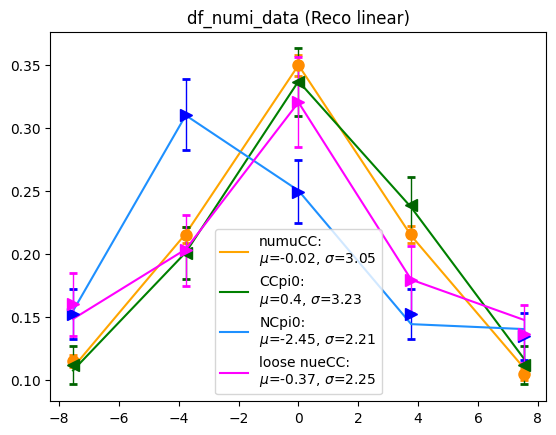

In [10]:
def plot_time_distribution(df, time_col = "merge_time", label=""):
    nbins = 5

    # Helper for query string
    time_query = f"{time_col}>-9.42 and {time_col}<9.42"

    data_numuCC = df.query(time_query).query("numu_score>0.9")[time_col].to_numpy()
    norm1 = len(data_numuCC)
    y, xbins = np.histogram(data_numuCC, bins=nbins, range=(-9.42, 9.42))
    x1 = get_bin_centers(xbins)
    popt, pcov = curve_fit(gaus, x1, y / norm1)
    print("numuCC: Gaussian      mean:", round(popt[1], 4), "  std:", round(popt[2], 4), "  C:", round(popt[3], 4))

    data_CCpi0 = df.query(time_query).query(CCpi0_query)[time_col].to_numpy()
    norm2 = len(data_CCpi0)
    y2, xbins = np.histogram(data_CCpi0, bins=nbins, range=(-9.42, 9.42))
    x2 = get_bin_centers(xbins)
    popt2, pcov2 = curve_fit(gaus, x2, y2 / norm2)
    print("CCpi0: Gaussian      mean:", round(popt2[1], 4), "  std:", round(popt2[2], 4), "  C:", round(popt2[3], 4))

    data_NCpi0 = df.query(time_query).query(NCpi0_query)[time_col].to_numpy()
    norm3 = len(data_NCpi0)
    y3, xbins = np.histogram(data_NCpi0, bins=nbins, range=(-9.42, 9.42))
    x3 = get_bin_centers(xbins)
    popt3, pcov3 = curve_fit(gaus, x3, y3 / norm3)
    print("NCpi0: Gaussian      mean:", round(popt3[1], 4), "  std:", round(popt3[2], 4), "  C:", round(popt3[3], 4))

    data_nueCC = df.query(time_query).query("nue_score>4")[time_col].to_numpy()
    norm4 = len(data_nueCC)
    y4, xbins = np.histogram(data_nueCC, bins=nbins, range=(-9.42, 9.42))
    x4 = get_bin_centers(xbins)
    popt4, pcov4 = curve_fit(gaus, x4, y4 / norm4)
    print("loose nueCC: Gaussian      mean:", round(popt4[1], 4), "  std:", round(popt4[2], 4), "  C:", round(popt4[3], 4))

    if(time_col == "merge_time_linear_sps"):
        label = label + " (spacepoints)"
    else:
        label = label + " (Reco linear)"

    plt.figure()
    plt.title(label)
    plt.errorbar(x1, y / norm1, yerr=np.sqrt(y) / norm1, ms=8, lw=1, fmt='o', ecolor='darkorange', color='darkorange', capsize=3, capthick=2)
    plt.plot(x1, gaus(x1, *popt), color='orange', label='numuCC:' + '\n' + f"$\mu$={round(popt[1],2)}, $\\sigma$={round(abs(popt[2]),2)}")

    plt.errorbar(x2, y2 / norm2, yerr=np.sqrt(y2) / norm2, ms=8, lw=1, fmt='<', ecolor='darkgreen', color='darkgreen', capsize=3, capthick=2)
    plt.plot(x2, gaus(x2, *popt2), color='green', label='CCpi0:' + '\n' + f"$\mu$={round(popt2[1],2)}, $\\sigma$={round(abs(popt2[2]),2)}")

    plt.errorbar(x3, y3 / norm3, yerr=np.sqrt(y3) / norm3, ms=8, lw=1, fmt='>', ecolor='blue', color='blue', capsize=3, capthick=2)
    plt.plot(x3, gaus(x3, *popt3), color='dodgerblue', label='NCpi0:' + '\n' + f"$\mu$={round(popt3[1],2)}, $\\sigma$={round(abs(popt3[2]),2)}")


    plt.errorbar(x4,y4/norm4,yerr=np.sqrt(y4)/norm4,ms=8, lw=1,fmt='>',ecolor = 'magenta',color='magenta', capsize=3, capthick=2)
    plt.plot(x4,gaus(x4,*popt4),color='magenta',label='loose nueCC:'+'\n'+f"$\mu$={round(popt4[1],2)}, $\\sigma$={round(abs(popt4[2]),2)}")

    '''shift_text = f"Shifts:\nCCpi0 = {shift_ccpi0}\nNCpi0 = {shift_ncpi0}\nNue = {shift_nue}"
    plt.gcf().text(1.1, 0.2, shift_text, fontsize=12, va='center', ha='right', bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'))
    '''

    plt.legend()
    plt.show()

plot_time_distribution(df_numi_mc, time_col="merge_time", label="df_numi_mc")
plot_time_distribution(df_numi_data, time_col="merge_time", label="df_numi_data")

In [11]:
def plot_merge_time_spread( x_var, bins, nbins=18, selection_query=CCpi0_query):
    selections = ["numu_score > 0.9", CCpi0_query, NCpi0_query, "nue_score > 4"]
    for selection in selections:
        selection_query = selection
        means_data, mean_errors_data, stds_data, std_errors_data = get_stats(
            df_numi_mc, selection_query, x_var, "merge_time", bins, nbins
        )
        label_select = "CCpi0"
        marker_select = "o"
        color_data = "blue"
        color_mc = "cyan"
        if selection_query == NCpi0_query:
            label_select = "NCpi0"
            marker_select = "s"
            color_data = "red"
            color_mc = "orange"
        if selection_query == "numu_score > 0.9":
            label_select = "NumuCC"
            marker_select = "D"
            color_data = "green"
            color_mc = "lime"
        if selection_query == "nue_score > 4":
            label_select = "NueCC"
            marker_select = "v"
            color_data = "purple"
            color_mc = "violet"
        bin_centers = get_bin_centers(bins)
        plt.title("Numi MC: " + x_var)
        plt.errorbar(bin_centers, means_data, yerr=mean_errors_data, lw=0, ms=5, marker = marker_select, elinewidth=1, label="Data " + label_select, color = color_data)
        plt.xlabel(x_var)
        plt.ylabel("Mean Merged Time (ns)")
        plt.axhline(0, color='gray', linestyle=':', linewidth=1, alpha=0.5) 
        plt.legend(loc='upper left')

In [12]:
target_dir = [-0.46, -0.05, -0.885]
min_a = -122.86902944472968
min_b = 80.60659897339974
min_c = 59.34119182916038

In [13]:


#correction parameters, see here https://github.com/uboone/ubana/blob/develop/ubana/MicroBooNEWireCell/utils/def_filetype.sh
f_ccnd1_a = 0.4343
f_ccnd1_b = 6.2884
f_ccnd2_a = 0.0637
f_ccnd2_b = 1.489
f_ccnd3_a = 0
f_ccnd3_b = 0
f_ccnd3_c = 0
f_ccnd3_d = 0
f_ccnd4_a = 0.0125
f_ccnd4_b = 2.3152
f_ccnd4_1_a = 0
f_ccnd4_1_b = 0
f_ccnd4_2_a = 0
f_ccnd4_2_b = 0
dist_cut_x_cor = 99999

RWM_offset = 5700


# pmt location
PMT_location = [[-11.4545, -28.625, 990.356], [-11.4175, 27.607, 989.712],
               [-11.7755, -56.514, 951.865], [-11.6415, 55.313, 951.861],
               [-12.0585, -56.309, 911.939], [-11.8345, 55.822, 911.065],
               [-12.1765, -0.722, 865.599], [-12.3045, -0.502, 796.208],
               [-12.6045, -56.284, 751.905], [-12.5405, 55.625, 751.884],
               [-12.6125, -56.408, 711.274], [-12.6615, 55.8, 711.073],
               [-12.6245, -0.051, 664.203], [-12.6515, -0.549, 585.284],
               [-12.8735, 55.822, 540.929], [-12.6205, -56.205, 540.616],
               [-12.5945, -56.323, 500.221], [-12.9835, 55.771, 500.134],
               [-12.6185, -0.875, 453.096], [-13.0855, -0.706, 373.839],
               [-12.6485, -57.022, 328.341], [-13.1865, 54.693, 328.212],
               [-13.4175, 54.646, 287.976], [-13.0075, -56.261, 287.639],
               [-13.1505, -0.829, 242.014], [-13.4415, -0.303, 173.743],
               [-13.3965, 55.249, 128.354], [-13.2784, -56.203, 128.18],
               [-13.2375, -56.615, 87.8695], [-13.5415, 55.249, 87.7605],
               [-13.4345, 27.431, 51.1015], [-13.1525, -28.576, 50.4745]]




#PMT timing ofsets
offset = [1.03002, -5.18104, -2.11164, -5.99395, -1.25798, 0.633079, 2.87666, 2.21969, 0.885092, 2.35423, -1.63039, -1.83775, -0.859883, 3.4741, 1.84833, 1.58233, -2.71783, 0, 3.18776, 0.982666, 0.728438, 0.280592, -5.27068,-3.27857, -1.41196, 1.59643, 1.41425, -1.62682, -2.55772, 1.49136, -0.522791, 0.974533]

sol = 0.033356
sol_Ar = 0.0746


In [14]:
# functions needed to utilize PID for more realistic velocities.

def get_time(momentum,startXYZT,endXYZT,pdg,mother_time):
    dx_i = 0.5
    dx = dx_i
    time_position_points = []
    length = np.sqrt( pow(startXYZT[0]-endXYZT[0],2) + pow(startXYZT[1]-endXYZT[1],2) + pow(startXYZT[2]-endXYZT[2],2) )
    residual_range = length
    x_pos = startXYZT[0]
    y_pos = startXYZT[1]
    z_pos = startXYZT[2]            
    mass = 0
    if pdg == 13: mass = 0.1057
    if pdg == 2212: mass = 0.9397933 #Don't do neutrons, KE is not assigned well so just assume c
    if pdg == 211: mass = 0.13982067  
    KE = momentum[3] - mass
    KE_R = momentum[3] - mass
    v_i = np.nan_to_num(sol*1/np.sqrt( 1-pow(mass/(mass+KE),2) ),nan=sol)
    if pdg==22 or pdg==2112 or pdg==11: v_i = sol
    v = v_i
    v_R = v_i
    tPh = mother_time
    tPh_R = mother_time
    gamma = 0
    DPh = np.sqrt( pow(startXYZT[0]-x_pos,2) + pow(startXYZT[1]-y_pos,2) + pow(startXYZT[2]-z_pos,2) )
    tPh_alt = DPh*v_i+mother_time
    while residual_range>=0:       
        #save this point
        time_position_points.append([x_pos,y_pos,z_pos,tPh])
        #update for the next point
        if residual_range<dx and dx==dx_i:
            dx = residual_range*1.0000001
        tPh += v*dx 
        dedx = get_dE_dx_range(residual_range,pdg)/1000
        de = dedx*dx #automatically 0 for showers and neutrons, so just useing the "alt" treatment
        KE = KE-de
        v = np.nan_to_num(sol*1/np.sqrt( 1-pow(mass/(mass+KE),2) ),nan=sol)
        if pdg==22 or pdg==2112 or pdg==11: v = sol
            
        tPh_R += v_R*dx
        if(pdg==13 or pdg==2212 or abs(pdg)==211): KE_R = get_T_range(residual_range,pdg)/1000
        v_R= np.nan_to_num(sol*1/np.sqrt( 1-pow(mass/(mass+KE_R),2) ),nan=sol)
        if pdg==22 or pdg==2112 or pdg==11: v_R = sol

        gamma+=(dx/length)
        x_pos = startXYZT[0] + gamma*(endXYZT[0]-startXYZT[0])
        y_pos = startXYZT[1] + gamma*(endXYZT[1]-startXYZT[1])
        z_pos = startXYZT[2] + gamma*(endXYZT[2]-startXYZT[2])
        residual_range = length - np.sqrt( pow(startXYZT[0]-x_pos,2) + pow(startXYZT[1]-y_pos,2) + pow(startXYZT[2]-z_pos,2)) 
        DPh = np.sqrt( pow(startXYZT[0]-x_pos,2) + pow(startXYZT[1]-y_pos,2) + pow(startXYZT[2]-z_pos,2) )
        tPh_alt = DPh*v_i+mother_time
    return time_position_points

def set_particle_propegation_times(momentum,startXYZT,endXYZT,ID,pdg,mother):

    dx = 3

    particle_times = {}

    #first round, just do the primary
    for part in range(len(pdg)):
        # Check to see if we already added this particle
        if ID[part] in particle_times: continue  
        # Daughter particles get added after their mother to do the cummulative time right
        if mother[part] != 0: continue

        time_position_points = get_time(momentum[part],startXYZT[part],endXYZT[part],pdg[part],0)       
        particle_times.update({ID[part]:time_position_points})
        
        #check for daughters
        daughters = []
        
        for daught_part in range(len(pdg)): 
            if mother[daught_part] == ID[part]: 
                if len(particle_times[ID[part]])>0: daughters.append([ID[daught_part],daught_part,particle_times[ID[part]][-1][3]])
                else: daughters.append([ID[daught_part],daught_part,0])

        while len(daughters) > 0 :
            this_daughter = daughters[0]
            daughters_id = this_daughter[0]
            #double check we have not already added this particle
            if daughters_id in particle_times: 
                daughters.remove(this_daughter)
                continue 
            daughters_index = this_daughter[1]
            mothers_time = this_daughter[2]
            time_position_points = get_time(momentum[daughters_index],startXYZT[daughters_index],endXYZT[daughters_index],pdg[daughters_index],mothers_time)       
            particle_times.update({daughters_id:time_position_points})  
            #add the daughters of the daughters
            for daught_part in range(len(pdg)): 
                if mother[daught_part] == daughters_id and not(ID[daught_part] in particle_times): 
                    if len(particle_times[daughters_id])>0: daughters.append([ID[daught_part],daught_part,particle_times[daughters_id][-1][3]])
                    else: daughters.append([ID[daught_part],daught_part,0])
            daughters.remove(this_daughter)
            
    return particle_times

In [15]:
def get_dE_dx(dqdx):
    alpha = 0.93
    beta = 0.212
    dedx = (np.exp((dqdx) * 23.6e-6*beta/1.38/0.273) - alpha)/(beta/1.38/0.273)
    return dedx
    
def get_dE_dx_range(R,pdg):
    if pdg==22 or pdg==11 or pdg==2112: return 0
    A = 8 
    b = -0.37 
    if pdg==2212:    
        A = 17
        b = -0.42
    dedx = A*pow(R,b)
    return dedx

def get_T_range(R,pdg):
    if pdg==22 or pdg==11 or pdg==2112: return 0
    A = 8 
    b = -0.37 
    if pdg==2212:    
        A = 17
        b = -0.42
    T = A/(b+1)*pow(R,b+1)
    return T



# Processing

In [16]:
#Get the reconstructed neutrino energy
em_charge_scale = 0.95
corrected_kine_reco_Enus = []
energy_info_lists = df_numi_data["kine_energy_info"].to_numpy()
energy_lists = df_numi_data["kine_energy_particle"].to_numpy()
pdg_lists = df_numi_data["kine_particle_type"].to_numpy()
add_energies = df_numi_data["kine_reco_add_energy"].to_numpy()
for i in tqdm(range(df_numi_data.shape[0])):
    corrected_kine_reco_Enu = 0.
    energy_list = energy_lists[i]
    pdg_list = pdg_lists[i]
    energy_info_list = energy_info_lists[i]
    for j in range(len(energy_list)):
        if energy_info_list[j] == 2 and pdg_list[j] == 11:
            corrected_kine_reco_Enu += em_charge_scale * energy_list[j]
        else:
            corrected_kine_reco_Enu += energy_list[j]
    corrected_kine_reco_Enu += add_energies[i]
    
    corrected_kine_reco_Enus.append(corrected_kine_reco_Enu) 

df_numi_data["kine_reco_Enu"] = corrected_kine_reco_Enus

100%|██████████| 11496/11496 [00:00<00:00, 288683.91it/s]


In [17]:
#Get the reconstructed neutrino energy
em_charge_scale = 0.95
corrected_kine_reco_Enus = []
energy_info_lists = df_numi_mc["kine_energy_info"].to_numpy()
energy_lists = df_numi_mc["kine_energy_particle"].to_numpy()
pdg_lists = df_numi_mc["kine_particle_type"].to_numpy()
add_energies = df_numi_mc["kine_reco_add_energy"].to_numpy()
for i in tqdm(range(df_numi_mc.shape[0])):
    corrected_kine_reco_Enu = 0.
    energy_list = energy_lists[i]
    pdg_list = pdg_lists[i]
    energy_info_list = energy_info_lists[i]
    for j in range(len(energy_list)):
        if energy_info_list[j] == 2 and pdg_list[j] == 11:
            corrected_kine_reco_Enu += em_charge_scale * energy_list[j]
        else:
            corrected_kine_reco_Enu += energy_list[j]
    corrected_kine_reco_Enu += add_energies[i]
    
    corrected_kine_reco_Enus.append(corrected_kine_reco_Enu) 

df_numi_mc["kine_reco_Enu"] = corrected_kine_reco_Enus

100%|██████████| 15857/15857 [00:00<00:00, 340059.00it/s]


In [18]:
kine_pio_energy_1 = []
kine_pio_energy_2 = []

for idx in range(len(df_numi_data["kine_pio_energy_1"])):
    if df_numi_data["kine_pio_energy_1"].iloc[idx] >= df_numi_data["kine_pio_energy_2"].iloc[idx]:
        kine_pio_energy_1.append(df_numi_data["kine_pio_energy_1"].iloc[idx])
        kine_pio_energy_2.append(df_numi_data["kine_pio_energy_2"].iloc[idx])

    else:
        kine_pio_energy_2.append(df_numi_data["kine_pio_energy_1"].iloc[idx])
        kine_pio_energy_1.append(df_numi_data["kine_pio_energy_2"].iloc[idx])
        
df_numi_data["kine_pio_energy_1"] = kine_pio_energy_1
df_numi_data["kine_pio_energy_2"] = kine_pio_energy_2

kine_pio_energy_1 = []
kine_pio_energy_2 = []

for idx in range(len(df_numi_mc["kine_pio_energy_1"])):
    if df_numi_mc["kine_pio_energy_1"].iloc[idx] >= df_numi_mc["kine_pio_energy_2"].iloc[idx]:
        kine_pio_energy_1.append(df_numi_mc["kine_pio_energy_1"].iloc[idx])
        kine_pio_energy_2.append(df_numi_mc["kine_pio_energy_2"].iloc[idx])

    else:
        kine_pio_energy_2.append(df_numi_mc["kine_pio_energy_1"].iloc[idx])
        kine_pio_energy_1.append(df_numi_mc["kine_pio_energy_2"].iloc[idx])
        
df_numi_mc["kine_pio_energy_1"] = kine_pio_energy_1
df_numi_mc["kine_pio_energy_2"] = kine_pio_energy_2


def pi0_processing(all_df):
    RAD = 2*np.pi/360
    kine_pio_energy_1 = all_df["kine_pio_energy_1"].to_numpy()
    kine_pio_energy_2 = all_df["kine_pio_energy_2"].to_numpy()
    kine_pio_theta_1 = all_df["kine_pio_theta_1"].to_numpy()
    kine_pio_theta_2 = all_df["kine_pio_theta_2"].to_numpy()
    kine_pio_phi_1 = all_df["kine_pio_phi_1"].to_numpy()
    kine_pio_phi_2 = all_df["kine_pio_phi_2"].to_numpy()
    kine_pio_angle = all_df["kine_pio_angle"].to_numpy()

    pi0_momentum_lst = []
    pi0_momentum_0_lst = []
    pi0_momentum_1_lst = []
    pi0_momentum_2_lst = []
    pi0_phi_lst = []
    pi0_cosphi_lst = []
    pi0_theta_lst = []
    pi0_costheta_lst = []
    pi0_costheta_CM_lst = []
    gamma_1_mom_0_lst = []
    gamma_2_mom_0_lst = []
    gamma_lead_mom_0_lst = []
    gamma_trail_mom_0_lst = []

    for i in tqdm(range(len(kine_pio_energy_1))):
        
        pi0_momentum = -1000
        pi0_mom_0 = -1000
        pi0_mom_1 = -1000
        pi0_mom_2 = -1000
        pi0_costheta = -1000
        pi0_costheta_CM = -1000
        pi0_phi = -1000
        pi0_cosphi = -1000
        pi0_theta = -1000
        pi0_costheta = -1000

        if(kine_pio_energy_1[i] > 0 and kine_pio_energy_2[i] > 0):
            pi0_mass = 135;
            alpha = abs((kine_pio_energy_1[i] - kine_pio_energy_2[i])/(kine_pio_energy_1[i] + kine_pio_energy_2[i]));
            pi0_total_energy = pi0_mass * np.sqrt(2./(1-alpha*alpha)/(1-np.cos(kine_pio_angle[i]*RAD)));
            pi0_momentum = np.sqrt(pi0_total_energy*pi0_total_energy - pi0_mass*pi0_mass);
            pi0_costheta_CM = pi0_total_energy/pi0_momentum * alpha
            
            gamma_1_mom_0 = kine_pio_energy_1[i]*np.cos(kine_pio_phi_1[i]*RAD)*np.sin(kine_pio_theta_1[i]*RAD) 
            gamma_1_mom_1 = kine_pio_energy_1[i]*np.sin(kine_pio_phi_1[i]*RAD)*np.sin(kine_pio_theta_1[i]*RAD) 
            gamma_1_mom_2 = kine_pio_energy_1[i]*np.cos(kine_pio_theta_1[i]*RAD)
            
            gamma_2_mom_0 = kine_pio_energy_2[i]*np.cos(kine_pio_phi_2[i]*RAD)*np.sin(kine_pio_theta_2[i]*RAD) 
            gamma_2_mom_1 = kine_pio_energy_2[i]*np.sin(kine_pio_phi_2[i]*RAD)*np.sin(kine_pio_theta_2[i]*RAD) 
            gamma_2_mom_2 = kine_pio_energy_2[i]*np.cos(kine_pio_theta_2[i]*RAD)

            pi0_mom_0 = gamma_1_mom_0 + gamma_2_mom_0
            pi0_mom_1 = gamma_1_mom_1 + gamma_2_mom_1
            pi0_mom_2 = gamma_1_mom_2 + gamma_2_mom_2
            
            pi0_theta, pi0_phi = get_angle(pi0_mom_0, pi0_mom_1, pi0_mom_2)
            
            #with pio energy
            gamma_1_mom_0_lst.append(gamma_1_mom_0)
            gamma_2_mom_0_lst.append(gamma_2_mom_0)
            
            if abs(gamma_1_mom_0) > abs(gamma_2_mom_0):
                gamma_lead_mom_0 = gamma_1_mom_0
                gamma_trail_mom_0 = gamma_2_mom_0
            else:
                gamma_lead_mom_0 = gamma_2_mom_0
                gamma_trail_mom_0 = gamma_1_mom_0
            
            #with bigger x-momentum
            gamma_lead_mom_0_lst.append(gamma_lead_mom_0)
            gamma_trail_mom_0_lst.append(gamma_trail_mom_0)
        else:
            gamma_1_mom_0_lst.append(-1000)
            gamma_2_mom_0_lst.append(-1000)
            gamma_lead_mom_0_lst.append(-1000)
            gamma_trail_mom_0_lst.append(-1000)
        
        pi0_momentum_lst.append(pi0_momentum)
        pi0_momentum_0_lst.append(pi0_mom_0)
        pi0_momentum_1_lst.append(pi0_mom_1)
        pi0_momentum_2_lst.append(pi0_mom_2)
        pi0_phi_lst.append(pi0_phi)
        if pi0_phi != -1000: pi0_cosphi_lst.append(np.cos(pi0_phi))
        else: pi0_cosphi_lst.append(-1000)
        pi0_theta_lst.append(pi0_theta)
        if pi0_theta != -1000: pi0_costheta_lst.append(np.cos(pi0_theta))
        else: pi0_costheta_lst.append(-1000)
        pi0_costheta_CM_lst.append(pi0_costheta_CM)

    all_df["reco_pi0_mom"] = pi0_momentum_lst
    all_df["reco_pi0_mom_0"] = pi0_momentum_0_lst
    all_df["reco_pi0_mom_1"] = pi0_momentum_1_lst
    all_df["reco_pi0_mom_2"] = pi0_momentum_2_lst
    all_df["reco_pi0_phi"] = pi0_phi_lst
    all_df["reco_pi0_cosphi"] = pi0_cosphi_lst
    all_df["reco_pi0_theta"] = pi0_theta_lst
    all_df["reco_pi0_costheta"] = pi0_costheta_lst
    all_df["reco_pi0_costheta_CM"] = pi0_costheta_CM_lst   
    all_df["gamma_1_mom_0"] = gamma_1_mom_0_lst
    all_df["gamma_2_mom_0"] = gamma_2_mom_0_lst
    all_df["gamma_lead_mom_0"] = gamma_lead_mom_0_lst
    all_df["gamma_trail_mom_0"] = gamma_trail_mom_0_lst
    
pi0_processing(df_numi_data)
pi0_processing(df_numi_mc)

100%|██████████| 15857/15857 [00:00<00:00, 88928.48it/s]


In [19]:
kine_pio_theta_lead = []
kine_pio_theta_trail = []
kine_pio_phi_lead = []
kine_pio_phi_trail = []
kine_pio_dis_lead = []
kine_pio_dis_trail = []

for idx in range(len(df_numi_data["kine_pio_energy_1"])):
    if df_numi_data["kine_pio_energy_1"].iloc[idx] >= df_numi_data["kine_pio_energy_2"].iloc[idx]:
        kine_pio_theta_lead.append(df_numi_data["kine_pio_theta_1"].iloc[idx])
        kine_pio_theta_trail.append(df_numi_data["kine_pio_theta_2"].iloc[idx])
        kine_pio_phi_lead.append(df_numi_data["kine_pio_phi_1"].iloc[idx])
        kine_pio_phi_trail.append(df_numi_data["kine_pio_phi_2"].iloc[idx])
        kine_pio_dis_lead.append(df_numi_data["kine_pio_dis_1"].iloc[idx])
        kine_pio_dis_trail.append(df_numi_data["kine_pio_dis_2"].iloc[idx])
    else:
        kine_pio_theta_lead.append(df_numi_data["kine_pio_theta_2"].iloc[idx])
        kine_pio_theta_trail.append(df_numi_data["kine_pio_theta_1"].iloc[idx])
        kine_pio_phi_lead.append(df_numi_data["kine_pio_phi_2"].iloc[idx])
        kine_pio_phi_trail.append(df_numi_data["kine_pio_phi_1"].iloc[idx])
        kine_pio_dis_lead.append(df_numi_data["kine_pio_dis_2"].iloc[idx])
        kine_pio_dis_trail.append(df_numi_data["kine_pio_dis_1"].iloc[idx])

df_numi_data["kine_pio_theta_lead"] = kine_pio_theta_lead
df_numi_data["kine_pio_theta_trail"] = kine_pio_theta_trail
df_numi_data["kine_pio_phi_lead"] = kine_pio_phi_lead
df_numi_data["kine_pio_phi_trail"] = kine_pio_phi_trail
df_numi_data["kine_pio_dis_lead"] = kine_pio_dis_lead
df_numi_data["kine_pio_dis_trail"] = kine_pio_dis_trail

kine_pio_theta_lead = []
kine_pio_theta_trail = []
kine_pio_phi_lead = []
kine_pio_phi_trail = []
kine_pio_dis_lead = []
kine_pio_dis_trail = []

for idx in range(len(df_numi_mc["kine_pio_energy_1"])):
    if df_numi_mc["kine_pio_energy_1"].iloc[idx] >= df_numi_mc["kine_pio_energy_2"].iloc[idx]:
        kine_pio_theta_lead.append(df_numi_mc["kine_pio_theta_1"].iloc[idx])
        kine_pio_theta_trail.append(df_numi_mc["kine_pio_theta_2"].iloc[idx])
        kine_pio_phi_lead.append(df_numi_mc["kine_pio_phi_1"].iloc[idx])
        kine_pio_phi_trail.append(df_numi_mc["kine_pio_phi_2"].iloc[idx])
        kine_pio_dis_lead.append(df_numi_mc["kine_pio_dis_1"].iloc[idx])
        kine_pio_dis_trail.append(df_numi_mc["kine_pio_dis_2"].iloc[idx])
    else:
        kine_pio_theta_lead.append(df_numi_mc["kine_pio_theta_2"].iloc[idx])
        kine_pio_theta_trail.append(df_numi_mc["kine_pio_theta_1"].iloc[idx])
        kine_pio_phi_lead.append(df_numi_mc["kine_pio_phi_2"].iloc[idx])
        kine_pio_phi_trail.append(df_numi_mc["kine_pio_phi_1"].iloc[idx])
        kine_pio_dis_lead.append(df_numi_mc["kine_pio_dis_2"].iloc[idx])
        kine_pio_dis_trail.append(df_numi_mc["kine_pio_dis_1"].iloc[idx])

df_numi_mc["kine_pio_theta_lead"] = kine_pio_theta_lead
df_numi_mc["kine_pio_theta_trail"] = kine_pio_theta_trail
df_numi_mc["kine_pio_phi_lead"] = kine_pio_phi_lead
df_numi_mc["kine_pio_phi_trail"] = kine_pio_phi_trail
df_numi_mc["kine_pio_dis_lead"] = kine_pio_dis_lead
df_numi_mc["kine_pio_dis_trail"] = kine_pio_dis_trail

In [ ]:
'''mu = df_numi_data["reco_muonMomentum"]

p = df_numi_data["reco_showerMomentum"]

kine_reco_Enu = df_numi_data["kine_reco_Enu"].to_numpy()

mu_thetas = []
mu_phis = []
mu_costhetas = []
mu_cosphis = []
reco_Emuon = []

p_thetas = []
p_phis = []
p_costhetas = []
p_cosphis = []
reco_Eproton = []

Ehadron = []

for i in range(len(mu)):
    if(mu.iloc[i][3]<=0): 
        mu_theta = np.nan
        mu_phi = np.nan
        Ehadron.append(kine_reco_Enu[i])
    else: 
        mu_theta, mu_phi = get_angle(mu[i][0], mu[i][1], mu[i][2])
        Ehadron.append(kine_reco_Enu[i]-mu[i][3]*1000)
    mu_thetas.append(mu_theta)
    mu_phis.append(mu_phi)
    mu_costhetas.append(np.cos(mu_theta))
    mu_cosphis.append(np.cos(mu_phi))
    reco_Emuon.append(mu[i][3]*1000)
    
    if(p.iloc[i][3]<=0): 
        p_theta = np.nan
        p_phi = np.nan
        reco_Eproton.append(0)
        
    else: 
        p_theta, p_phi = get_angle(p[i][0], p[i][1], p[i][2])
        reco_Eproton.append(p[i][3]*1000)
    p_thetas.append(p_theta)
    p_phis.append(p_phi)
    p_costhetas.append(np.cos(p_theta))
    p_cosphis.append(np.cos(p_phi))
    
    
df_numi_data["reco_muon_theta"] = mu_thetas
df_numi_data["reco_muon_phi"] = mu_phis
df_numi_data["reco_muon_costheta"] = mu_costhetas
df_numi_data["reco_muon_cosphi"] = mu_cosphis 
df_numi_data["reco_Emuon"] = reco_Emuon

df_numi_data["reco_shower_theta"] = p_thetas
df_numi_data["reco_shower_phi"] = p_phis
df_numi_data["reco_shower_costheta"] = p_costhetas
df_numi_data["reco_shower_cosphi"] = p_cosphis 
df_numi_data["reco_showerMomentum"] = reco_Eproton

df_numi_data["Ehadron"] = Ehadron'''

KeyError: 0

In [21]:
mu = df_numi_mc["reco_muonMomentum"]

p = df_numi_mc["reco_showerMomentum"]

kine_reco_Enu = df_numi_mc["kine_reco_Enu"].to_numpy()

mu_thetas = []
mu_phis = []
mu_costhetas = []
mu_cosphis = []
reco_Emuon = []

p_thetas = []
p_phis = []
p_costhetas = []
p_cosphis = []
reco_Eproton = []

Ehadron = []

for i in range(len(mu)):
    if(mu.iloc[i][3]<=0): 
        mu_theta = np.nan
        mu_phi = np.nan
        Ehadron.append(kine_reco_Enu[i])
    else: 
        mu_theta, mu_phi = get_angle(mu.iloc[i][0], mu.iloc[i][1], mu.iloc[i][2])
        Ehadron.append(kine_reco_Enu[i]-mu.iloc[i][3]*1000)
    mu_thetas.append(mu_theta)
    mu_phis.append(mu_phi)
    mu_costhetas.append(np.cos(mu_theta))
    mu_cosphis.append(np.cos(mu_phi))
    reco_Emuon.append(mu.iloc[i][3]*1000)
    
    if(p.iloc[i][3]<=0): 
        p_theta = np.nan
        p_phi = np.nan
        reco_Eproton.append(0)
        
    else: 
        p_theta, p_phi = get_angle(p.iloc[i][0], p.iloc[i][1], p.iloc[i][2])
        reco_Eproton.append(p.iloc[i][3]*1000)
    p_thetas.append(p_theta)
    p_phis.append(p_phi)
    p_costhetas.append(np.cos(p_theta))
    p_cosphis.append(np.cos(p_phi))
    
    
df_numi_mc["reco_muon_theta"] = mu_thetas
df_numi_mc["reco_muon_phi"] = mu_phis
df_numi_mc["reco_muon_costheta"] = mu_costhetas
df_numi_mc["reco_muon_cosphi"] = mu_cosphis 
df_numi_mc["reco_Emuon"] = reco_Emuon

df_numi_mc["reco_shower_theta"] = p_thetas
df_numi_mc["reco_shower_phi"] = p_phis
df_numi_mc["reco_shower_costheta"] = p_costhetas
df_numi_mc["reco_shower_cosphi"] = p_cosphis 
df_numi_mc["reco_showerMomentum"] = reco_Eproton

df_numi_mc["Ehadron"] = Ehadron

In [60]:
#add saving track pdgs
reco_muonMoms0 = df_numi_mc["reco_muonMomentum"].iloc[0].to_numpy()
reco_muonMoms1 = df_numi_mc["reco_muonMomentum"].iloc[1].to_numpy()
reco_muonMoms2 = df_numi_mc["reco_muonMomentum"].iloc[2].to_numpy()
reco_muonMoms3 = df_numi_mc["reco_muonMomentum"].iloc[3].to_numpy()

reco_hadMoms0 = []
reco_hadMoms1 = []
reco_hadMoms2 = []
reco_hadMoms3 = []

reco_hadMoms_prim0 = []
reco_hadMoms_prim1 = []
reco_hadMoms_prim2 = []
reco_hadMoms_prim3 = []

reco_hadMoms_con0 = []
reco_hadMoms_con1 = []
reco_hadMoms_con2 = []
reco_hadMoms_con3 = []

reco_hadMoms_allcon0 = []
reco_hadMoms_allcon1 = []
reco_hadMoms_allcon2 = []
reco_hadMoms_allcon3 = []

reco_nuMoms0 = []
reco_nuMoms1 = []
reco_nuMoms2 = []
reco_nuMoms3 = []

reco_nuMoms_prim0 = []
reco_nuMoms_prim1 = []
reco_nuMoms_prim2 = []
reco_nuMoms_prim3 = []

reco_nuMoms_con0 = []
reco_nuMoms_con1 = []
reco_nuMoms_con2 = []
reco_nuMoms_con3 = []

reco_nuMoms_allcon0 = []
reco_nuMoms_allcon1 = []
reco_nuMoms_allcon2 = []
reco_nuMoms_allcon3 = []

track_1_KEs = []
track_2_KEs = []
prim_track_1_KEs = []
prim_track_2_KEs = []
con_track_1_KEs = []
con_track_2_KEs = []
allcon_track_1_KEs = []
allcon_track_2_KEs = []

e_1_KEs = []
e_2_KEs = []
prim_e_1_KEs = []
prim_e_2_KEs = []
con_e_1_KEs = []
con_e_2_KEs = []
allcon_e_1_KEs = []
allcon_e_2_KEs = []


g_1_KEs = []
g_2_KEs = []
prim_g_1_KEs = []
prim_g_2_KEs = []
con_g_1_KEs = []
con_g_2_KEs = []
allcon_g_1_KEs = []
allcon_g_2_KEs = []

nu_thetas = []
nu_phis = []
cos_nu_thetas = []
cos_nu_phis = []

nu_prim_thetas = []
nu_prim_phis = []
cos_nu_prim_thetas = []
cos_nu_prim_phis = []

nu_con_thetas = []
nu_con_phis = []
cos_nu_con_thetas = []
cos_nu_con_phis = []

nu_allcon_thetas = []
nu_allcon_phis = []
cos_nu_allcon_thetas = []
cos_nu_allcon_phis = []

nu_numi_thetas = []
nu_numi_phis = []
cos_nu_numi_thetas = []
cos_nu_numi_phis = []

nu_prim_numi_thetas = []
nu_prim_numi_phis = []
cos_nu_prim_numi_thetas = []
cos_nu_prim_numi_phis = []

nu_con_numi_thetas = []
nu_con_numi_phis = []
cos_nu_con_numi_thetas = []
cos_nu_con_numi_phis = []

nu_allcon_numi_thetas = []
nu_allcon_numi_phis = []
cos_nu_allcon_numi_thetas = []
cos_nu_allcon_numi_phis = []

track_thetas = []
track_phis = []
cos_track_thetas = []
cos_track_phis = []

track_prim_thetas = []
track_prim_phis = []
cos_track_prim_thetas = []
cos_track_prim_phis = []

track_con_thetas = []
track_con_phis = []
cos_track_con_thetas = []
cos_track_con_phis = []

track_allcon_thetas = []
track_allcon_phis = []
cos_track_allcon_thetas = []
cos_track_allcon_phis = []

track_numi_thetas = []
track_numi_phis = []
cos_track_numi_thetas = []
cos_track_numi_phis = []

track_prim_numi_thetas = []
track_prim_numi_phis = []
cos_track_prim_numi_thetas = []
cos_track_prim_numi_phis = []

track_con_numi_thetas = []
track_con_numi_phis = []
cos_track_con_numi_thetas = []
cos_track_con_numi_phis = []

track_allcon_numi_thetas = []
track_allcon_numi_phis = []
cos_track_allcon_numi_thetas = []
cos_track_allcon_numi_phis = []

muon_1_Es = []
muon_2_Es = []
prim_muon_1_Es = []
prim_muon_2_Es = []
con_muon_1_Es = []
con_muon_2_Es = []
allcon_muon_1_Es = []
allcon_muon_2_Es = []

p_1_Es = []
p_2_Es = []
prim_p_1_Es = []
prim_p_2_Es = []
con_p_1_Es = []
con_p_2_Es = []
allcon_p_1_Es = []
allcon_p_2_Es = []

reco_startMomentums = df_numi_mc["reco_startMomentum"].to_numpy()
reco_endMomentums = df_numi_mc["reco_endMomentum"].to_numpy()
reco_startPos = df_numi_mc["reco_startXYZT"].to_numpy()
reco_endPos = df_numi_mc["reco_endXYZT"].to_numpy()
mothers = df_numi_mc["reco_mother"].to_numpy()
pdgs = df_numi_mc["reco_pdg"].to_numpy()
ids = df_numi_mc["reco_id"].to_numpy()


for i in tqdm(range(df_numi_mc.shape[0])):
    reco_muonMoms = df_numi_mc["reco_muonMomentum"].iloc[i]
    reco_muonMom0 = reco_muonMoms[0]
    reco_muonMom1 = reco_muonMoms[1]
    reco_muonMom2 = reco_muonMoms[2]
    reco_muonMom3 = reco_muonMoms[3]

    reco_hadMom0 = 0
    reco_hadMom1 = 0
    reco_hadMom2 = 0
    reco_hadMom3 = 0   
    
    reco_hadMom_prim0 = 0
    reco_hadMom_prim1 = 0
    reco_hadMom_prim2 = 0
    reco_hadMom_prim3 = 0 
    
    reco_hadMom_con0 = 0
    reco_hadMom_con1 = 0
    reco_hadMom_con2 = 0
    reco_hadMom_con3 = 0 

    reco_hadMom_allcon0 = 0
    reco_hadMom_allcon1 = 0
    reco_hadMom_allcon2 = 0
    reco_hadMom_allcon3 = 0 
    
    track_1_KE = -1000
    track_2_KE = -1000
    prim_track_1_KE = -1000
    prim_track_2_KE = -1000
    con_track_1_KE = -1000
    con_track_2_KE = -1000
    allcon_track_1_KE = -1000
    allcon_track_2_KE = -1000
    track_1 = [0,0,0,0]
    track_2 = [0,0,0,0]
    prim_track_1 = [0,0,0,0]
    prim_track_2 = [0,0,0,0]
    con_track_1 = [0,0,0,0]
    con_track_2 = [0,0,0,0]
    allcon_track_1 = [0,0,0,0]
    allcon_track_2 = [0,0,0,0]
    
    e_1_KE = -1000
    e_2_KE = -1000
    prim_e_1_KE = -1000
    prim_e_2_KE = -1000
    con_e_1_KE = -1000
    con_e_2_KE = -1000
    allcon_e_1_KE = -1000
    allcon_e_2_KE = -1000

    g_1_KE = -1000
    g_2_KE = -1000
    prim_g_1_KE = -1000
    prim_g_2_KE = -1000
    con_g_1_KE = -1000
    con_g_2_KE = -1000
    allcon_g_1_KE = -1000
    allcon_g_2_KE = -1000
    
    muon_1_E = -1000
    muon_2_E = -1000
    prim_muon_1_E = -1000
    prim_muon_2_E = -1000
    con_muon_1_E = -1000
    con_muon_2_E = -1000
    allcon_muon_1_E = -1000
    allcon_muon_2_E = -1000

    p_1_E = -1000
    p_2_E = -1000
    prim_p_1_E = -1000
    prim_p_2_E = -1000
    con_p_1_E = -1000
    con_p_2_E = -1000
    allcon_p_1_E = -1000
    allcon_p_2_E = -1000
    
    mother_list = mothers[i]
    connected_lst = []
    pdg_list = pdgs[i]
    id_lst = ids[i]
    #Ntrack = Ntracks[i]
    reco_startMomentum_list = reco_startMomentums[i]
    reco_endMomentum_list = reco_endMomentums[i]
    
    reco_startPos_list = reco_startPos[i]
    reco_endPos_list = reco_endPos[i]
    

    for j in range(len(mother_list)):
        flag_connected = True
        flag_all_connected = True
        mass = 0
        
        
        if (abs(pdg_list[j])<10000 and (abs(pdg_list[j])<3000 or abs(pdg_list[j])>4000) 
        and reco_startMomentum_list[j][0]!=1 and reco_startMomentum_list[j][1]!=1 and reco_startMomentum_list[j][2]!=1
        and reco_startMomentum_list[j][3]>=0 and reco_endMomentum_list[j][3]>=0):
            
            
            reco_hadMom0 +=reco_startMomentum_list[j][0]
            reco_hadMom1 +=reco_startMomentum_list[j][1]
            reco_hadMom2 +=reco_startMomentum_list[j][2]
            reco_hadMom3 +=reco_startMomentum_list[j][3]-reco_endMomentum_list[j][3]
            if mother_list[j] == 0: 
                reco_hadMom_prim0 +=reco_startMomentum_list[j][0]
                reco_hadMom_prim1 +=reco_startMomentum_list[j][1]
                reco_hadMom_prim2 +=reco_startMomentum_list[j][2]
                reco_hadMom_prim3 +=reco_startMomentum_list[j][3]-reco_endMomentum_list[j][3]
                
                reco_hadMom_con0 +=reco_startMomentum_list[j][0]
                reco_hadMom_con1 +=reco_startMomentum_list[j][1]
                reco_hadMom_con2 +=reco_startMomentum_list[j][2]
                reco_hadMom_con3 +=reco_startMomentum_list[j][3]-reco_endMomentum_list[j][3]
                connected_lst.append(flag_connected)
                
            else:
                #flag_connected = True
                #flag_all_connected = True
                
                mother_ID = mother_list[j]
                mother_index = -1000
                daughter_index = j
                count = 0
                while mother_ID!=0:
                    
                    dist = 100000000000
                    
                    for mother in range(len(mother_list)):
                        if id_lst[mother] == mother_ID:
                            mother_index = mother
                            break

                    if mother_index>0:

                        temp_dist_x = reco_endPos_list[daughter_index][0] - reco_endPos_list[mother_index][0]
                        temp_dist_y = reco_endPos_list[daughter_index][1] - reco_endPos_list[mother_index][1]
                        temp_dist_z = reco_endPos_list[daughter_index][2] - reco_endPos_list[mother_index][2]
                        temp_dist = np.sqrt( temp_dist_x**2 + temp_dist_y**2 + temp_dist_z**2)
                        if temp_dist>dist: dist = temp_dist
                        temp_dist_x = reco_startPos_list[daughter_index][0] - reco_endPos_list[mother_index][0]
                        temp_dist_y = reco_startPos_list[daughter_index][1] - reco_endPos_list[mother_index][1]
                        temp_dist_z = reco_startPos_list[daughter_index][2] - reco_endPos_list[mother_index][2]
                        temp_dist = np.sqrt( temp_dist_x**2 + temp_dist_y**2 + temp_dist_z**2)
                        if temp_dist>dist: dist = temp_dist
                        temp_dist_x = reco_endPos_list[daughter_index][0] - reco_startPos_list[mother_index][0]
                        temp_dist_y = reco_endPos_list[daughter_index][1] - reco_startPos_list[mother_index][1]
                        temp_dist_z = reco_endPos_list[daughter_index][2] - reco_startPos_list[mother_index][2]
                        temp_dist = np.sqrt( temp_dist_x**2 + temp_dist_y**2 + temp_dist_z**2)
                        if temp_dist>dist: dist = temp_dist
                        temp_dist_x = reco_startPos_list[daughter_index][0] - reco_startPos_list[mother_index][0]
                        temp_dist_y = reco_startPos_list[daughter_index][1] - reco_startPos_list[mother_index][1]
                        temp_dist_z = reco_startPos_list[daughter_index][2] - reco_startPos_list[mother_index][2]
                        temp_dist = np.sqrt( temp_dist_x**2 + temp_dist_y**2 + temp_dist_z**2)
                        if temp_dist<dist: dist = temp_dist

                    if dist>5 and mother_ID == mother_list[j]: flag_connected=False #just the imediate mother
                    if dist>5: 
                        flag_all_connected = False
                        break
                    mother_ID = mother_list[mother_index] #set up to check the next mother
                    daughter_index = mother_index
                    #mother_index = daughter_index
                    count+=1
                    if count>30: 
                        flag_all_connected = False
                        break
                    
                if flag_connected:
                    reco_hadMom_con0 +=reco_startMomentum_list[j][0]
                    reco_hadMom_con1 +=reco_startMomentum_list[j][1]
                    reco_hadMom_con2 +=reco_startMomentum_list[j][2]
                    reco_hadMom_con3 +=reco_startMomentum_list[j][3]-reco_endMomentum_list[j][3]
                connected_lst.append(flag_connected)
                
                if flag_all_connected:
                    reco_hadMom_allcon0 +=reco_startMomentum_list[j][0]
                    reco_hadMom_allcon1 +=reco_startMomentum_list[j][1]
                    reco_hadMom_allcon2 +=reco_startMomentum_list[j][2]
                    reco_hadMom_allcon3 +=reco_startMomentum_list[j][3]-reco_endMomentum_list[j][3]

              
        if abs(pdg_list[j])==13 or abs(pdg_list[j])==2212 or abs(pdg_list[j])==211:
            if abs(pdg_list[j])==13: 
                mass = 0.1056
                if muon_1_E<reco_startMomentum_list[j][3]:
                    muon_2_KE = muon_1_E
                    muon_1_E = reco_startMomentum_list[j][3]
                elif muon_2_E<reco_startMomentum_list[j][3]:
                    muon_2_E = reco_startMomentum_list[j][3]
            if abs(pdg_list[j])==2212: 
                mass = 0.938
                if p_1_E<reco_startMomentum_list[j][3]:
                    p_2_KE = p_1_E
                    p_1_E = reco_startMomentum_list[j][3]
                elif p_2_E<reco_startMomentum_list[j][3]:
                    p_2_E = reco_startMomentum_list[j][3]
            if abs(pdg_list[j])==211: 
                mass = 0.139
                
            if track_1_KE<reco_startMomentum_list[j][3]-mass:
                track_2_KE = track_1_KE
                track_2 = track_1
                track_1_KE = reco_startMomentum_list[j][3]-mass
                track_1 = [reco_startMomentum_list[j][0],reco_startMomentum_list[j][1],reco_startMomentum_list[j][2],reco_startMomentum_list[j][3]]
            elif track_2_KE<reco_startMomentum_list[j][3]-mass:
                track_2_KE = reco_startMomentum_list[j][3]-mass
                track_2 = [reco_startMomentum_list[j][0],reco_startMomentum_list[j][1],reco_startMomentum_list[j][2],reco_startMomentum_list[j][3]]
                
            if mother_list[j] == 0:
                if prim_track_1_KE<reco_startMomentum_list[j][3]-mass:
                    prim_track_2_KE = prim_track_1_KE
                    prim_track_2 = prim_track_1
                    prim_track_1_KE = reco_startMomentum_list[j][3]-mass
                    prim_track_1 = [reco_startMomentum_list[j][0],reco_startMomentum_list[j][1],reco_startMomentum_list[j][2],reco_startMomentum_list[j][3]]
                elif prim_track_2_KE<reco_startMomentum_list[j][3]-mass:
                    prim_track_2_KE = reco_startMomentum_list[j][3]-mass  
                    prim_track_2 = [reco_startMomentum_list[j][0],reco_startMomentum_list[j][1],reco_startMomentum_list[j][2],reco_startMomentum_list[j][3]]                    
                if abs(pdg_list[j])==13: 
                    if prim_muon_1_E<reco_startMomentum_list[j][3]:
                        prim_muon_2_KE = prim_muon_1_E
                        prim_muon_1_E = reco_startMomentum_list[j][3]
                    elif prim_muon_2_E<reco_startMomentum_list[j][3]:
                        prim_muon_2_E = reco_startMomentum_list[j][3]
                if abs(pdg_list[j])==2212: 
                    if prim_p_1_E<reco_startMomentum_list[j][3]:
                        prim_p_2_KE = prim_p_1_E
                        prim_p_1_E = reco_startMomentum_list[j][3]
                    elif prim_p_2_E<reco_startMomentum_list[j][3]:
                        prim_p_2_E = reco_startMomentum_list[j][3]
                        
        if abs(pdg_list[j])==11:
            mass = 0.0005
            if e_1_KE<reco_startMomentum_list[j][3]-mass:
                e_2_KE = e_1_KE
                e_1_KE = reco_startMomentum_list[j][3]-mass
            elif e_2_KE<reco_startMomentum_list[j][3]-mass:
                e_2_KE = reco_startMomentum_list[j][3]-mass
            
            if mother_list[j] == 0:
                if prim_e_1_KE<reco_startMomentum_list[j][3]-mass:
                    prim_e_2_KE = prim_e_1_KE
                    prim_e_1_KE = reco_startMomentum_list[j][3]-mass
                elif prim_e_2_KE<reco_startMomentum_list[j][3]-mass:
                    prim_e_2_KE = reco_startMomentum_list[j][3]-mass
                    
        if abs(pdg_list[j])==22:
            mass = 0
            if g_1_KE<reco_startMomentum_list[j][3]-mass:
                g_2_KE = g_1_KE
                g_1_KE = reco_startMomentum_list[j][3]-mass
            elif g_2_KE<reco_startMomentum_list[j][3]-mass:
                g_2_KE = reco_startMomentum_list[j][3]-mass
            
            if mother_list[j] == 0:
                if prim_g_1_KE<reco_startMomentum_list[j][3]-mass:
                    prim_g_2_KE = prim_g_1_KE
                    prim_g_1_KE = reco_startMomentum_list[j][3]-mass
                elif prim_g_2_KE<reco_startMomentum_list[j][3]-mass:
                    prim_g_2_KE = reco_startMomentum_list[j][3]-mass
        
        if flag_connected:
            if abs(pdg_list[j])==13 or abs(pdg_list[j])==2212 or abs(pdg_list[j])==211:
                if con_track_1_KE<reco_startMomentum_list[j][3]-mass:
                    con_track_2_KE = con_track_1_KE
                    con_track_2 = con_track_1
                    con_track_1_KE = reco_startMomentum_list[j][3]-mass
                    con_track_1 = [reco_startMomentum_list[j][0],reco_startMomentum_list[j][1],reco_startMomentum_list[j][2],reco_startMomentum_list[j][3]]
                elif con_track_2_KE<reco_startMomentum_list[j][3]-mass:
                    con_track_2_KE = reco_startMomentum_list[j][3]-mass  
                    con_track_2 = [reco_startMomentum_list[j][0],reco_startMomentum_list[j][1],reco_startMomentum_list[j][2],reco_startMomentum_list[j][3]]                    
            if abs(pdg_list[j])==13: 
                if con_muon_1_E<reco_startMomentum_list[j][3]:
                    con_muon_2_KE = con_muon_1_E
                    con_muon_1_E = reco_startMomentum_list[j][3]
                elif con_muon_2_E<reco_startMomentum_list[j][3]:
                    con_muon_2_E = reco_startMomentum_list[j][3]
            if abs(pdg_list[j])==2212: 
                if con_p_1_E<reco_startMomentum_list[j][3]:
                    con_p_2_KE = con_p_1_E
                    con_p_1_E = reco_startMomentum_list[j][3]
                elif con_p_2_E<reco_startMomentum_list[j][3]:
                    con_p_2_E = reco_startMomentum_list[j][3]

            if abs(pdg_list[j])==11:
                if con_e_1_KE<reco_startMomentum_list[j][3]-mass:
                    con_e_2_KE = con_e_1_KE
                    con_e_1_KE = reco_startMomentum_list[j][3]-mass
                elif con_e_2_KE<reco_startMomentum_list[j][3]-mass:
                    con_e_2_KE = reco_startMomentum_list[j][3]-mass

            if abs(pdg_list[j])==22:
                if con_g_1_KE<reco_startMomentum_list[j][3]-mass:
                    con_g_2_KE = con_g_1_KE
                    con_g_1_KE = reco_startMomentum_list[j][3]-mass
                elif con_g_2_KE<reco_startMomentum_list[j][3]-mass:
                    con_g_2_KE = reco_startMomentum_list[j][3]-mass

                    
        if flag_all_connected:
            if abs(pdg_list[j])==13 or abs(pdg_list[j])==2212 or abs(pdg_list[j])==211:
                if allcon_track_1_KE<reco_startMomentum_list[j][3]-mass:
                    allcon_track_2_KE = allcon_track_1_KE
                    allcon_track_2 = allcon_track_1
                    allcon_track_1_KE = reco_startMomentum_list[j][3]-mass
                    allcon_track_1 = [reco_startMomentum_list[j][0],reco_startMomentum_list[j][1],reco_startMomentum_list[j][2],reco_startMomentum_list[j][3]]
                elif allcon_track_2_KE<reco_startMomentum_list[j][3]-mass:
                    allcon_track_2_KE = reco_startMomentum_list[j][3]-mass  
                    allcon_track_2 = [reco_startMomentum_list[j][0],reco_startMomentum_list[j][1],reco_startMomentum_list[j][2],reco_startMomentum_list[j][3]]                    
            if abs(pdg_list[j])==13: 
                if allcon_muon_1_E<reco_startMomentum_list[j][3]:
                    allcon_muon_2_KE = allcon_muon_1_E
                    allcon_muon_1_E = reco_startMomentum_list[j][3]
                elif allcon_muon_2_E<reco_startMomentum_list[j][3]:
                    allcon_muon_2_E = reco_startMomentum_list[j][3]
            if abs(pdg_list[j])==2212: 
                if allcon_p_1_E<reco_startMomentum_list[j][3]:
                    allcon_p_2_KE = allcon_p_1_E
                    allcon_p_1_E = reco_startMomentum_list[j][3]
                elif allcon_p_2_E<reco_startMomentum_list[j][3]:
                    allcon_p_2_E = reco_startMomentum_list[j][3]

            if abs(pdg_list[j])==11:
                if allcon_e_1_KE<reco_startMomentum_list[j][3]-mass:
                    allcon_e_2_KE = allcon_e_1_KE
                    allcon_e_1_KE = reco_startMomentum_list[j][3]-mass
                elif allcon_e_2_KE<reco_startMomentum_list[j][3]-mass:
                    allcon_e_2_KE = reco_startMomentum_list[j][3]-mass

            if abs(pdg_list[j])==22:
                if allcon_g_1_KE<reco_startMomentum_list[j][3]-mass:
                    allcon_g_2_KE = allcon_g_1_KE
                    allcon_g_1_KE = reco_startMomentum_list[j][3]-mass
                elif allcon_g_2_KE<reco_startMomentum_list[j][3]-mass:
                    allcon_g_2_KE = reco_startMomentum_list[j][3]-mass



        



    if reco_muonMom3>0:
        reco_hadMoms0.append((reco_hadMom0-reco_muonMom0)*1000)
        reco_hadMoms1.append((reco_hadMom1-reco_muonMom1)*1000)
        reco_hadMoms2.append((reco_hadMom2-reco_muonMom2)*1000)
        reco_hadMoms3.append((reco_hadMom3-reco_muonMom3)*1000)
        
        reco_hadMoms_prim0.append((reco_hadMom_prim0-reco_muonMom0)*1000)
        reco_hadMoms_prim1.append((reco_hadMom_prim1-reco_muonMom1)*1000)
        reco_hadMoms_prim2.append((reco_hadMom_prim2-reco_muonMom2)*1000)
        reco_hadMoms_prim3.append((reco_hadMom_prim3-reco_muonMom3)*1000)
        
        reco_hadMoms_con0.append((reco_hadMom_con0-reco_muonMom0)*1000)
        reco_hadMoms_con1.append((reco_hadMom_con1-reco_muonMom1)*1000)
        reco_hadMoms_con2.append((reco_hadMom_con2-reco_muonMom2)*1000)
        reco_hadMoms_con3.append((reco_hadMom_con3-reco_muonMom3)*1000)
        
        reco_hadMoms_allcon0.append((reco_hadMom_allcon0-reco_muonMom0)*1000)
        reco_hadMoms_allcon1.append((reco_hadMom_allcon1-reco_muonMom1)*1000)
        reco_hadMoms_allcon2.append((reco_hadMom_allcon2-reco_muonMom2)*1000)
        reco_hadMoms_allcon3.append((reco_hadMom_allcon3-reco_muonMom3)*1000)

    else:
        reco_hadMoms0.append((reco_hadMom0)*1000)
        reco_hadMoms1.append((reco_hadMom1)*1000)
        reco_hadMoms2.append((reco_hadMom2)*1000)
        reco_hadMoms3.append((reco_hadMom3)*1000)
        
        reco_hadMoms_prim0.append((reco_hadMom_prim0)*1000)
        reco_hadMoms_prim1.append((reco_hadMom_prim1)*1000)
        reco_hadMoms_prim2.append((reco_hadMom_prim2)*1000)
        reco_hadMoms_prim3.append((reco_hadMom_prim3)*1000)
        
        reco_hadMoms_con0.append((reco_hadMom_con0)*1000)
        reco_hadMoms_con1.append((reco_hadMom_con1)*1000)
        reco_hadMoms_con2.append((reco_hadMom_con2)*1000)
        reco_hadMoms_con3.append((reco_hadMom_con3)*1000)
        
        reco_hadMoms_allcon0.append((reco_hadMom_allcon0)*1000)
        reco_hadMoms_allcon1.append((reco_hadMom_allcon1)*1000)
        reco_hadMoms_allcon2.append((reco_hadMom_allcon2)*1000)
        reco_hadMoms_allcon3.append((reco_hadMom_allcon3)*1000)
        
    reco_nuMoms0.append((reco_hadMom0)*1000)
    reco_nuMoms1.append((reco_hadMom1)*1000)
    reco_nuMoms2.append((reco_hadMom2)*1000)
    reco_nuMoms3.append((reco_hadMom3)*1000)
    
    if reco_hadMom3>0:
    #if 1:
        nu_theta ,nu_phi = get_angle(reco_hadMom0,reco_hadMom1,reco_hadMom2)

        nu_thetas.append(nu_theta)
        nu_phis.append(nu_phi)
        cos_nu_thetas.append(np.cos(nu_theta))
        cos_nu_phis.append(np.cos(nu_phi))
        
        nu_numi_theta ,nu_numi_phi = get_angle(reco_hadMom0,reco_hadMom1,reco_hadMom2,to_numi=True)

        nu_numi_thetas.append(nu_numi_theta)
        nu_numi_phis.append(nu_numi_phi)
        cos_nu_numi_thetas.append(np.cos(nu_numi_theta))
        cos_nu_numi_phis.append(np.cos(nu_numi_phi))
    else:
        nu_thetas.append(-1000)
        nu_phis.append(-1000)
        cos_nu_thetas.append(-1000)
        cos_nu_phis.append(-1000)
        
        nu_numi_thetas.append(-1000)
        nu_numi_phis.append(-1000)
        cos_nu_numi_thetas.append(-1000)
        cos_nu_numi_phis.append(-1000)
        
    reco_nuMoms_prim0.append((reco_hadMom_prim0)*1000)
    reco_nuMoms_prim1.append((reco_hadMom_prim1)*1000)
    reco_nuMoms_prim2.append((reco_hadMom_prim2)*1000)
    reco_nuMoms_prim3.append((reco_hadMom_prim3)*1000)
    
    #FIX
    if reco_hadMom_prim3>0:        
        nu_theta ,nu_phi = get_angle(reco_hadMom_prim0,reco_hadMom_prim1,reco_hadMom_prim2)

        nu_prim_thetas.append(nu_theta)
        nu_prim_phis.append(nu_phi)
        cos_nu_prim_thetas.append(np.cos(nu_theta))
        cos_nu_prim_phis.append(np.cos(nu_phi))
        
        nu_numi_theta ,nu_numi_phi = get_angle(reco_hadMom_prim0,reco_hadMom_prim1,reco_hadMom_prim2,to_numi=True)

        nu_prim_numi_thetas.append(nu_numi_theta)
        nu_prim_numi_phis.append(nu_numi_phi)
        cos_nu_prim_numi_thetas.append(np.cos(nu_numi_theta))
        cos_nu_prim_numi_phis.append(np.cos(nu_numi_phi))
        
    else:
        nu_prim_thetas.append(-1000)
        nu_prim_phis.append(-1000)
        cos_nu_prim_thetas.append(-1000)
        cos_nu_prim_phis.append(-1000)
        
        nu_prim_numi_thetas.append(-1000)
        nu_prim_numi_phis.append(-1000)
        cos_nu_prim_numi_thetas.append(-1000)
        cos_nu_prim_numi_phis.append(-1000)
                
    if reco_hadMom_con3>0:        
        nu_theta ,nu_phi = get_angle(reco_hadMom_con0,reco_hadMom_con1,reco_hadMom_con2)

        nu_con_thetas.append(nu_theta)
        nu_con_phis.append(nu_phi)
        cos_nu_con_thetas.append(np.cos(nu_theta))
        cos_nu_con_phis.append(np.cos(nu_phi))
        
        nu_numi_theta ,nu_numi_phi = get_angle(reco_hadMom_con0,reco_hadMom_con1,reco_hadMom_con2,to_numi=True)

        nu_con_numi_thetas.append(nu_numi_theta)
        nu_con_numi_phis.append(nu_numi_phi)
        cos_nu_con_numi_thetas.append(np.cos(nu_numi_theta))
        cos_nu_con_numi_phis.append(np.cos(nu_numi_phi))
        
    else:
        nu_con_thetas.append(-1000)
        nu_con_phis.append(-1000)
        cos_nu_con_thetas.append(-1000)
        cos_nu_con_phis.append(-1000)
        
        nu_con_numi_thetas.append(-1000)
        nu_con_numi_phis.append(-1000)
        cos_nu_con_numi_thetas.append(-1000)
        cos_nu_con_numi_phis.append(-1000)
        
        
    if reco_hadMom_allcon3>0:        
        nu_theta ,nu_phi = get_angle(reco_hadMom_allcon0,reco_hadMom_allcon1,reco_hadMom_allcon2)

        nu_allcon_thetas.append(nu_theta)
        nu_allcon_phis.append(nu_phi)
        cos_nu_allcon_thetas.append(np.cos(nu_theta))
        cos_nu_allcon_phis.append(np.cos(nu_phi))
        
        nu_numi_theta ,nu_numi_phi = get_angle(reco_hadMom_allcon0,reco_hadMom_allcon1,reco_hadMom_allcon2,to_numi=True)

        nu_allcon_numi_thetas.append(nu_numi_theta)
        nu_allcon_numi_phis.append(nu_numi_phi)
        cos_nu_allcon_numi_thetas.append(np.cos(nu_numi_theta))
        cos_nu_allcon_numi_phis.append(np.cos(nu_numi_phi))
        
    else:
        nu_allcon_thetas.append(-1000)
        nu_allcon_phis.append(-1000)
        cos_nu_allcon_thetas.append(-1000)
        cos_nu_allcon_phis.append(-1000)
        
        nu_allcon_numi_thetas.append(-1000)
        nu_allcon_numi_phis.append(-1000)
        cos_nu_allcon_numi_thetas.append(-1000)
        cos_nu_allcon_numi_phis.append(-1000)
        
        
    if track_2_KE>0:
    #if 1:
        track_theta ,track_phi = get_angle(track_1[0]+track_2[0],track_1[1]+track_2[1],track_1[2]+track_2[2])

        track_thetas.append(track_theta)
        track_phis.append(track_phi)
        cos_track_thetas.append(np.cos(track_theta))
        cos_track_phis.append(np.cos(track_phi))
        
        track_numi_theta ,track_numi_phi = get_angle(track_1[0]+track_2[0],track_1[1]+track_2[1],track_1[2]+track_2[2],to_numi=True)

        track_numi_thetas.append(track_numi_theta)
        track_numi_phis.append(track_numi_phi)
        cos_track_numi_thetas.append(np.cos(track_numi_theta))
        cos_track_numi_phis.append(np.cos(track_numi_phi))
    else:
        track_thetas.append(-1000)
        track_phis.append(-1000)
        cos_track_thetas.append(-1000)
        cos_track_phis.append(-1000)
        
        track_numi_thetas.append(-1000)
        track_numi_phis.append(-1000)
        cos_track_numi_thetas.append(-1000)
        cos_track_numi_phis.append(-1000)
    
    
    if prim_track_2_KE>0:        
        prim_track_theta ,prim_track_phi = get_angle(prim_track_1[0]+prim_track_2[0],prim_track_1[1]+prim_track_2[1],prim_track_1[2]+prim_track_2[2])

        track_prim_thetas.append(prim_track_theta)
        track_prim_phis.append(prim_track_phi)
        cos_track_prim_thetas.append(np.cos(prim_track_theta))
        cos_track_prim_phis.append(np.cos(prim_track_phi))
        
        prim_track_numi_theta ,prim_track_numi_phi = get_angle(prim_track_1[0]+prim_track_2[0],prim_track_1[1]+prim_track_2[1],prim_track_1[2]+prim_track_2[2],to_numi=True)

        track_prim_numi_thetas.append(prim_track_numi_theta)
        track_prim_numi_phis.append(prim_track_numi_phi)
        cos_track_prim_numi_thetas.append(np.cos(prim_track_numi_theta))
        cos_track_prim_numi_phis.append(np.cos(prim_track_numi_phi))
        
    else:
        track_prim_thetas.append(-1000)
        track_prim_phis.append(-1000)
        cos_track_prim_thetas.append(-1000)
        cos_track_prim_phis.append(-1000)
        
        track_prim_numi_thetas.append(-1000)
        track_prim_numi_phis.append(-1000)
        cos_track_prim_numi_thetas.append(-1000)
        cos_track_prim_numi_phis.append(-1000)        
        
    if con_track_2_KE>0:        
        con_track_theta ,con_track_phi = get_angle(con_track_1[0]+con_track_2[0],con_track_1[1]+con_track_2[1],con_track_1[2]+con_track_2[2])

        track_con_thetas.append(con_track_theta)
        track_con_phis.append(con_track_phi)
        cos_track_con_thetas.append(np.cos(con_track_theta))
        cos_track_con_phis.append(np.cos(con_track_phi))
        
        con_track_numi_theta ,con_track_numi_phi = get_angle(con_track_1[0]+con_track_2[0],con_track_1[1]+con_track_2[1],con_track_1[2]+con_track_2[2],to_numi=True)

        track_con_numi_thetas.append(con_track_numi_theta)
        track_con_numi_phis.append(con_track_numi_phi)
        cos_track_con_numi_thetas.append(np.cos(con_track_numi_theta))
        cos_track_con_numi_phis.append(np.cos(con_track_numi_phi))
        
    else:
        track_con_thetas.append(-1000)
        track_con_phis.append(-1000)
        cos_track_con_thetas.append(-1000)
        cos_track_con_phis.append(-1000)
        
        track_con_numi_thetas.append(-1000)
        track_con_numi_phis.append(-1000)
        cos_track_con_numi_thetas.append(-1000)
        cos_track_con_numi_phis.append(-1000) 
        
    if allcon_track_2_KE>0:        
        allcon_track_theta ,allcon_track_phi = get_angle(allcon_track_1[0]+allcon_track_2[0],allcon_track_1[1]+allcon_track_2[1],allcon_track_1[2]+allcon_track_2[2])

        track_allcon_thetas.append(allcon_track_theta)
        track_allcon_phis.append(allcon_track_phi)
        cos_track_allcon_thetas.append(np.cos(allcon_track_theta))
        cos_track_allcon_phis.append(np.cos(allcon_track_phi))
        
        allcon_track_numi_theta ,allcon_track_numi_phi = get_angle(allcon_track_1[0]+allcon_track_2[0],allcon_track_1[1]+allcon_track_2[1],allcon_track_1[2]+allcon_track_2[2],to_numi=True)

        track_allcon_numi_thetas.append(allcon_track_numi_theta)
        track_allcon_numi_phis.append(allcon_track_numi_phi)
        cos_track_allcon_numi_thetas.append(np.cos(allcon_track_numi_theta))
        cos_track_allcon_numi_phis.append(np.cos(allcon_track_numi_phi))
        
    else:
        track_allcon_thetas.append(-1000)
        track_allcon_phis.append(-1000)
        cos_track_allcon_thetas.append(-1000)
        cos_track_allcon_phis.append(-1000)
        
        track_allcon_numi_thetas.append(-1000)
        track_allcon_numi_phis.append(-1000)
        cos_track_allcon_numi_thetas.append(-1000)
        cos_track_allcon_numi_phis.append(-1000) 
        
    track_1_KEs.append(track_1_KE)
    track_2_KEs.append(track_2_KE)
    prim_track_1_KEs.append(prim_track_1_KE)
    prim_track_2_KEs.append(prim_track_2_KE)
    con_track_1_KEs.append(con_track_1_KE)
    con_track_2_KEs.append(con_track_2_KE)
    allcon_track_1_KEs.append(allcon_track_1_KE)
    allcon_track_2_KEs.append(allcon_track_2_KE)

    e_1_KEs.append(e_1_KE)
    e_2_KEs.append(e_2_KE)
    prim_e_1_KEs.append(prim_e_1_KE)
    prim_e_2_KEs.append(prim_e_2_KE)
    con_e_1_KEs.append(con_e_1_KE)
    con_e_2_KEs.append(con_e_2_KE)
    allcon_e_1_KEs.append(allcon_e_1_KE)
    allcon_e_2_KEs.append(allcon_e_2_KE)
    
    muon_1_Es.append(muon_1_E)
    muon_2_Es.append(muon_2_E)
    prim_muon_1_Es.append(prim_muon_1_E)
    prim_muon_2_Es.append(prim_muon_2_E)
    con_muon_1_Es.append(con_muon_1_E)
    con_muon_2_Es.append(con_muon_2_E)
    allcon_muon_1_Es.append(allcon_muon_1_E)
    allcon_muon_2_Es.append(allcon_muon_2_E)

    p_1_Es.append(p_1_E)
    p_2_Es.append(p_2_E)
    prim_p_1_Es.append(prim_p_1_E)
    prim_p_2_Es.append(prim_p_2_E)
    con_p_1_Es.append(con_p_1_E)
    con_p_2_Es.append(con_p_2_E)
    allcon_p_1_Es.append(allcon_p_1_E)
    allcon_p_2_Es.append(allcon_p_2_E)
    
    g_1_KEs.append(g_1_KE)
    g_2_KEs.append(g_2_KE)
    prim_g_1_KEs.append(prim_g_1_KE)
    prim_g_2_KEs.append(prim_g_2_KE)
    con_g_1_KEs.append(con_g_1_KE)
    con_g_2_KEs.append(con_g_2_KE)
    allcon_g_1_KEs.append(allcon_g_1_KE)
    allcon_g_2_KEs.append(allcon_g_2_KE)
    
    
df_numi_mc["reco_hadMom0"] = reco_hadMoms0
df_numi_mc["reco_hadMom1"] = reco_hadMoms1
df_numi_mc["reco_hadMom2"] = reco_hadMoms2
df_numi_mc["reco_hadMom3"] = reco_hadMoms3

df_numi_mc["reco_hadMom_prim0"] = reco_hadMoms_prim0
df_numi_mc["reco_hadMom_prim1"] = reco_hadMoms_prim1
df_numi_mc["reco_hadMom_prim2"] = reco_hadMoms_prim2
df_numi_mc["reco_hadMom_prim3"] = reco_hadMoms_prim3

df_numi_mc["reco_hadMom_con0"] = reco_hadMoms_con0
df_numi_mc["reco_hadMom_con1"] = reco_hadMoms_con1
df_numi_mc["reco_hadMom_con2"] = reco_hadMoms_con2
df_numi_mc["reco_hadMom_con3"] = reco_hadMoms_con3

df_numi_mc["reco_hadMom_allcon0"] = reco_hadMoms_allcon0
df_numi_mc["reco_hadMom_allcon1"] = reco_hadMoms_allcon1
df_numi_mc["reco_hadMom_allcon2"] = reco_hadMoms_allcon2
df_numi_mc["reco_hadMom_allcon3"] = reco_hadMoms_allcon3

df_numi_mc["reco_nuMom0"] = reco_nuMoms0
df_numi_mc["reco_nuMom1"] = reco_nuMoms1
df_numi_mc["reco_nuMom2"] = reco_nuMoms2
df_numi_mc["reco_nuMom3"] = reco_nuMoms3

df_numi_mc["reco_nuMom_prim0"] = reco_nuMoms_prim0
df_numi_mc["reco_nuMom_prim1"] = reco_nuMoms_prim1
df_numi_mc["reco_nuMom_prim2"] = reco_nuMoms_prim2
df_numi_mc["reco_nuMom_prim3"] = reco_nuMoms_prim3

df_numi_mc["reco_nu_theta"] = nu_thetas
df_numi_mc["reco_nu_phi"] = nu_phis
df_numi_mc["reco_cos_nu_theta"] = cos_nu_thetas
df_numi_mc["reco_cos_nu_phi"] = cos_nu_phis

df_numi_mc["reco_nu_prim_theta"] = nu_prim_thetas
df_numi_mc["reco_nu_prim_phi"] = nu_prim_phis
df_numi_mc["reco_cos_nu_prim_theta"] = cos_nu_prim_thetas
df_numi_mc["reco_cos_nu_prim_phi"] = cos_nu_prim_phis

df_numi_mc["reco_nu_con_theta"] = nu_con_thetas
df_numi_mc["reco_nu_con_phi"] = nu_con_phis
df_numi_mc["reco_cos_nu_con_theta"] = cos_nu_con_thetas
df_numi_mc["reco_cos_nu_con_phi"] = cos_nu_con_phis

df_numi_mc["reco_nu_allcon_theta"] = nu_allcon_thetas
df_numi_mc["reco_nu_allcon_phi"] = nu_allcon_phis
df_numi_mc["reco_cos_nu_allcon_theta"] = cos_nu_allcon_thetas
df_numi_mc["reco_cos_nu_allcon_phi"] = cos_nu_allcon_phis

df_numi_mc["reco_nu_numi_theta"] = nu_numi_thetas
df_numi_mc["reco_nu_numi_phi"] = nu_numi_phis
df_numi_mc["reco_cos_nu_numi_theta"] = cos_nu_numi_thetas
df_numi_mc["reco_cos_nu_numi_phi"] = cos_nu_numi_phis

df_numi_mc["reco_nu_prim_numi_theta"] = nu_prim_numi_thetas
df_numi_mc["reco_nu_prim_numi_phi"] = nu_prim_numi_phis
df_numi_mc["reco_cos_nu_prim_numi_theta"] = cos_nu_prim_numi_thetas
df_numi_mc["reco_cos_nu_prim_numi_phi"] = cos_nu_prim_numi_phis

df_numi_mc["reco_nu_con_numi_theta"] = nu_con_numi_thetas
df_numi_mc["reco_nu_con_numi_phi"] = nu_con_numi_phis
df_numi_mc["reco_cos_nu_con_numi_theta"] = cos_nu_con_numi_thetas
df_numi_mc["reco_cos_nu_con_numi_phi"] = cos_nu_con_numi_phis

df_numi_mc["reco_nu_allcon_numi_theta"] = nu_allcon_numi_thetas
df_numi_mc["reco_nu_allcon_numi_phi"] = nu_allcon_numi_phis
df_numi_mc["reco_cos_nu_allcon_numi_theta"] = cos_nu_allcon_numi_thetas
df_numi_mc["reco_cos_nu_allcon_numi_phi"] = cos_nu_allcon_numi_phis

df_numi_mc["reco_track_theta"] = track_thetas
df_numi_mc["reco_track_phi"] = track_phis
df_numi_mc["reco_cos_track_theta"] = cos_track_thetas
df_numi_mc["reco_cos_track_phi"] = cos_track_phis

df_numi_mc["reco_track_prim_theta"] = track_prim_thetas
df_numi_mc["reco_track_prim_phi"] = track_prim_phis
df_numi_mc["reco_cos_track_prim_theta"] = cos_track_prim_thetas
df_numi_mc["reco_cos_track_prim_phi"] = cos_track_prim_phis

df_numi_mc["reco_track_con_theta"] = track_con_thetas
df_numi_mc["reco_track_con_phi"] = track_con_phis
df_numi_mc["reco_cos_track_con_theta"] = cos_track_con_thetas
df_numi_mc["reco_cos_track_con_phi"] = cos_track_con_phis

df_numi_mc["reco_track_allcon_theta"] = track_allcon_thetas
df_numi_mc["reco_track_allcon_phi"] = track_allcon_phis
df_numi_mc["reco_cos_track_allcon_theta"] = cos_track_allcon_thetas
df_numi_mc["reco_cos_track_allcon_phi"] = cos_track_allcon_phis

df_numi_mc["reco_track_numi_theta"] = track_numi_thetas
df_numi_mc["reco_track_numi_phi"] = track_numi_phis
df_numi_mc["reco_cos_track_numi_theta"] = cos_track_numi_thetas
df_numi_mc["reco_cos_track_numi_phi"] = cos_track_numi_phis

df_numi_mc["reco_track_prim_numi_theta"] = track_prim_numi_thetas
df_numi_mc["reco_track_prim_numi_phi"] = track_prim_numi_phis
df_numi_mc["reco_cos_track_prim_numi_theta"] = cos_track_prim_numi_thetas
df_numi_mc["reco_cos_track_prim_numi_phi"] = cos_track_prim_numi_phis

df_numi_mc["reco_track_con_numi_theta"] = track_con_numi_thetas
df_numi_mc["reco_track_con_numi_phi"] = track_con_numi_phis
df_numi_mc["reco_cos_track_con_numi_theta"] = cos_track_con_numi_thetas
df_numi_mc["reco_cos_track_con_numi_phi"] = cos_track_con_numi_phis

df_numi_mc["reco_track_allcon_numi_theta"] = track_allcon_numi_thetas
df_numi_mc["reco_track_allcon_numi_phi"] = track_allcon_numi_phis
df_numi_mc["reco_cos_track_allcon_numi_theta"] = cos_track_allcon_numi_thetas
df_numi_mc["reco_cos_track_allcon_numi_phi"] = cos_track_allcon_numi_phis

df_numi_mc["track_1_KE"] = track_1_KEs
df_numi_mc["track_2_KE"] = track_2_KEs
df_numi_mc["prim_track_1_KE"] = prim_track_1_KEs
df_numi_mc["prim_track_2_KE"] = prim_track_2_KEs
df_numi_mc["con_track_1_KE"] = con_track_1_KEs
df_numi_mc["con_track_2_KE"] = con_track_2_KEs
df_numi_mc["allcon_track_1_KE"] = allcon_track_1_KEs
df_numi_mc["allcon_track_2_KE"] = allcon_track_2_KEs

df_numi_mc["e_1_KE"] = e_1_KEs
df_numi_mc["e_2_KE"] = e_2_KEs
df_numi_mc["prim_e_1_KE"] = prim_e_1_KEs
df_numi_mc["prim_e_2_KE"] = prim_e_2_KEs
df_numi_mc["con_e_1_KE"] = con_e_1_KEs
df_numi_mc["con_e_2_KE"] = con_e_2_KEs
df_numi_mc["allcon_e_1_KE"] = allcon_e_1_KEs
df_numi_mc["allcon_e_2_KE"] = allcon_e_2_KEs

df_numi_mc["pf_muon_1_E"] = muon_1_Es
df_numi_mc["pf_muon_2_E"] = muon_2_Es
df_numi_mc["pf_prim_muon_1_E"] = prim_muon_1_Es
df_numi_mc["pf_prim_muon_2_E"] = prim_muon_2_Es
df_numi_mc["pf_con_muon_1_E"] = con_muon_1_Es
df_numi_mc["pf_con_muon_2_E"] = con_muon_2_Es
df_numi_mc["pf_allcon_muon_1_E"] = allcon_muon_1_Es
df_numi_mc["pf_allcon_muon_2_E"] = allcon_muon_2_Es

df_numi_mc["pf_p_1_E"] = p_1_Es
df_numi_mc["pf_p_2_E"] = p_2_Es
df_numi_mc["pf_prim_p_1_E"] = prim_p_1_Es
df_numi_mc["pf_prim_p_2_E"] = prim_p_2_Es
df_numi_mc["pf_con_p_1_E"] = con_p_1_Es
df_numi_mc["pf_con_p_2_E"] = con_p_2_Es
df_numi_mc["pf_allcon_p_1_E"] = allcon_p_1_Es
df_numi_mc["pf_allcon_p_2_E"] = allcon_p_2_Es

df_numi_mc["g_1_KE"] = g_1_KEs
df_numi_mc["g_2_KE"] = g_2_KEs
df_numi_mc["prim_g_1_KE"] = prim_g_1_KEs
df_numi_mc["prim_g_2_KE"] = prim_g_2_KEs
df_numi_mc["con_g_1_KE"] = con_g_1_KEs
df_numi_mc["con_g_2_KE"] = con_g_2_KEs
df_numi_mc["allcon_g_1_KE"] = allcon_g_1_KEs
df_numi_mc["allcon_g_2_KE"] = allcon_g_2_KEs


100%|██████████| 15857/15857 [00:08<00:00, 1861.84it/s]
C:\Users\andre\AppData\Local\Temp\ipykernel_21952\3390290675.py:884: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_numi_mc["reco_cos_nu_allcon_theta"] = cos_nu_allcon_thetas
C:\Users\andre\AppData\Local\Temp\ipykernel_21952\3390290675.py:885: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_numi_mc["reco_cos_nu_allcon_phi"] = cos_nu_allcon_phis
C:\Users\andre\AppData\Local\Temp\ipykernel_21952\3390290675.py:887: PerformanceWarning: DataFrame is highly fragmented.  This i

In [61]:
'''# calculate the reconstructed time, this is similar to the code here: https://github.com/uboone/ubana/blob/develop/ubana/MicroBooNEWireCell/WireCellAnaTree_module.cc#L7860
PMT_ID_list =  df_numi_data["PMT_ID"].to_numpy()
PMT_Time_list =  df_numi_data["PMT_Time"].to_numpy()
PMT_Amp_list =  df_numi_data["PMT_Amp"].to_numpy()
RWM_Time_list =  df_numi_data["RWM_Time"].to_numpy()

reco_nuvtxX_list =  df_numi_data["reco_nuvtxX"].to_numpy()
reco_nuvtxY_list =  df_numi_data["reco_nuvtxY"].to_numpy()
reco_nuvtxZ_list =  df_numi_data["reco_nuvtxZ"].to_numpy()
reco_id_list =  df_numi_data["reco_id"].to_numpy()
reco_pdg_list =  df_numi_data["reco_pdg"].to_numpy()
reco_startMomentum_list =  df_numi_data["reco_startMomentum"].to_numpy()
reco_startXYZT_list =  df_numi_data["reco_startXYZT"].to_numpy()
reco_endXYZT_list =  df_numi_data["reco_endXYZT"].to_numpy()
reco_mother_list =  df_numi_data["reco_mother"].to_numpy()

reco_sps_x_list =  df_numi_data["reco_sps_x"].to_numpy()
reco_sps_y_list =  df_numi_data["reco_sps_y"].to_numpy()
reco_sps_z_list =  df_numi_data["reco_sps_z"].to_numpy()

evtTimeNS_endpoints = []
evtTimeNS_endpoints_nocor = []
evtTimeNS_linear = []
evtTimeNS_linear_nocor = []

DLh_endpoints_all = []
DPh_endpoints_all = []
DLh_linear_all = []
DPh_linear_all = []

nu_tof = []

TT3_endpoints_array_all = []
TT3_endpoints_array_nocor_all = []
TT3_linear_array_all = []
TT3_linear_array_nocor_all = []

timeProp_endpoints_all = []
timeProp_linear_all = []


Ph_Tot_all = []

for event in tqdm(range(len(PMT_ID_list))):
   
    PMT_ID = PMT_ID_list[event]
    PMT_Time = PMT_Time_list[event] 
    PMT_Amp = PMT_Amp_list[event]
    RWM_Time = RWM_Time_list[event] 

    reco_nuvtxX = reco_nuvtxX_list[event]
    reco_nuvtxY = reco_nuvtxY_list[event]
    reco_nuvtxZ = reco_nuvtxZ_list[event]
    reco_id = reco_id_list[event]
    reco_pdg = reco_pdg_list[event]
    reco_startMomentum = reco_startMomentum_list[event]
    reco_startXYZT = reco_startXYZT_list[event]
    reco_endXYZT = reco_endXYZT_list[event]
    reco_mother = reco_mother_list[event]
    
    reco_sps_x = reco_sps_x_list[event]
    reco_sps_y = reco_sps_y_list[event]
    reco_sps_z = reco_sps_z_list[event]  
    
    N_PMT = len(PMT_ID)

    #Not enought PMTs above threshold to do the timing
    if(N_PMT<3):
        
        evtTimeNS_endpoints.append(-99999)
        evtTimeNS_endpoints_nocor.append(-99999)
        evtTimeNS_linear.append(-99999)
        evtTimeNS_linear_nocor.append(-99999)
        
        nu_tof.append(-99999)

        DPh_endpoints_all.append([])
        DLh_endpoints_all.append([])
        DPh_linear_all.append([])
        DLh_linear_all.append([])

        TT3_endpoints_array_all.append([])
        TT3_endpoints_array_nocor_all.append([])
        TT3_linear_array_all.append([])
        TT3_linear_array_nocor_all.append([])

        timeProp_endpoints_all.append([])
        timeProp_linear_all.append([])

        Ph_Tot_all.append(-99999)
        
        continue
            
    Ph_Tot = 0
    
    timeProp_endpoints = []
    timeProp_linear = []
    
    TT3_endpoints_array = []
    TT3_endpoints_array_nocor = []    
    TT3_linear_array = []
    TT3_linear_array_nocor = []
    
    ccnd1 = 0
    ccnd2 = 0
    ccnd3 = 0
    ccnd4 = 0

    DPh_endpoints_event = []
    DLh_endpoints_event = []
    DPh_linear_event = []
    DLh_linear_event = []
    
    # For numi, we correct back to a plane close to the from face of the detector that is perpendicular to the beam direction.
    dist = ( (min_a-reco_nuvtxX)*target_dir[0] + (min_b-reco_nuvtxY)*target_dir[1] + (min_c-reco_nuvtxZ)*target_dir[2] ) / np.sqrt(target_dir[0]*target_dir[0] + target_dir[1]*target_dir[1] + target_dir[2]*target_dir[2] )
    nuToF=dist*0.033356;
    nu_tof.append(nuToF)

    particle_times = set_particle_propegation_times(reco_startMomentum,reco_startXYZT,reco_endXYZT,reco_id,reco_pdg,reco_mother)
   
    for pmt in range(N_PMT):

        pmt_id = PMT_ID[pmt]
        
        Ph_Tot=Ph_Tot+PMT_Amp[pmt]

        tp_endpoints=5000000000.0
        tp_linear=5000000000.0
        
        DPh_endpoints_event.append(0)
        DLh_endpoints_event.append(0)        
        DPh_linear_event.append(0)
        DLh_linear_event.append(0)

        # Future goal, can we switch this out for the full set of spacepoints? Can we also incorporate particle velocities?
        for point in range(len(reco_sps_x)):
            DPh_endpoints = np.sqrt( pow(reco_nuvtxX-reco_sps_x[point],2) + pow(reco_nuvtxY-reco_sps_y[point],2) + pow(reco_nuvtxZ-reco_sps_z[point],2) )  
            DLh_endpoints = np.sqrt( pow(PMT_location[pmt_id][0]-reco_sps_x[point],2) + pow(PMT_location[pmt_id][1]-reco_sps_y[point],2) + pow(PMT_location[pmt_id][2]-reco_sps_z[point],2) )
            tPhelp_endpoints = (DPh_endpoints*sol)+(DLh_endpoints*sol_Ar)
            if tPhelp_endpoints<tp_endpoints: 
                tp_endpoints=tPhelp_endpoints
                DPh_endpoints_event[pmt] = DPh_endpoints
                DLh_endpoints_event[pmt] = DLh_endpoints
                
        for part in particle_times:
            particle_time = particle_times[part]
            pdg = 0
            mother = 0
            for i in range(len(reco_id)): 
                if reco_id[i]==part: 
                    pdg = reco_pdg[i]
                    mother = reco_mother[i]

            #Linear extrapolation between start and endpoints, uses particle velocities
            for point in range(len(particle_time)):
                particle_time_point = particle_time[point]
                x_pos = particle_time_point[0]
                y_pos = particle_time_point[1]
                z_pos = particle_time_point[2]
                DLh_linear = np.sqrt( pow(PMT_location[pmt_id][0]-x_pos,2) + pow(PMT_location[pmt_id][1]-y_pos,2) + pow(PMT_location[pmt_id][2]-z_pos,2) )
                DPh_linear = np.sqrt( pow(reco_nuvtxX-x_pos,2) + pow(reco_nuvtxY-y_pos,2) + pow(reco_nuvtxZ-z_pos,2) ) 
                tPhelp_linear = particle_time_point[3]+(DLh_linear*sol_Ar)
                if tPhelp_linear<tp_linear: 
                    tp_linear=tPhelp_linear
                    DPh_linear_event[pmt] = particle_time_point[3]
                    DLh_linear_event[pmt] = DLh_linear
                
        timeProp_endpoints.append(tp_endpoints)  
        timeProp_linear.append(tp_linear)
        
    DPh_endpoints_all.append(DPh_endpoints_event)
    DLh_endpoints_all.append(DLh_endpoints_event)    
    timeProp_endpoints_all.append(timeProp_endpoints) 
    
    DPh_linear_all.append(DPh_linear_event)
    DLh_linear_all.append(DLh_linear_event)    
    timeProp_linear_all.append(timeProp_linear) 
    
    Ph_Tot_all.append(Ph_Tot)
   
    for pmt in range(N_PMT):
        
        pmt_id = PMT_ID[pmt]

        ccnd2 = PMT_Amp[pmt]*(f_ccnd2_a)-(f_ccnd2_b)
        if Ph_Tot>150: ccnd3=f_ccnd3_a-f_ccnd3_b*Ph_Tot+f_ccnd3_c*Ph_Tot*Ph_Tot 
        else: ccnd3=f_ccnd3_d
            
        if reco_nuvtxX<dist_cut_x_cor: ccnd4 = reco_nuvtxX*(f_ccnd4_a)-(f_ccnd4_b)
        else: ccnd4 = reco_nuvtxX*(f_ccnd4_2_a)-(f_ccnd4_2_b)

        ccnd1 = timeProp_endpoints[pmt]*(f_ccnd1_a)-(f_ccnd1_b)
        TT3_endpoints_array.append( PMT_Time[pmt] - RWM_Time_list[event] + RWM_offset - nuToF - timeProp_endpoints[pmt] - offset[pmt_id] +ccnd1+ccnd2+ccnd3+ccnd4 )
        TT3_endpoints_array_nocor.append( PMT_Time[pmt] - RWM_Time_list[event] + RWM_offset - nuToF - timeProp_endpoints[pmt] - offset[pmt_id] )       

        ccnd1 = timeProp_linear[pmt]*(f_ccnd1_a)-(f_ccnd1_b)
        TT3_linear_array.append( PMT_Time[pmt] - RWM_Time_list[event] + RWM_offset - nuToF - timeProp_linear[pmt] - offset[pmt_id] +ccnd1+ccnd2+ccnd3+ccnd4 )
        TT3_linear_array_nocor.append( PMT_Time[pmt] - RWM_Time_list[event] + RWM_offset - nuToF - timeProp_linear[pmt] - offset[pmt_id] )

    Med_TT3_endpoints = np.median(TT3_endpoints_array)
    evtTimeNS_endpoints.append(Med_TT3_endpoints)
    TT3_endpoints_array_all.append(TT3_endpoints_array)
    
    Med_TT3_endpoints_nocor = np.median(TT3_endpoints_array_nocor)
    evtTimeNS_endpoints_nocor.append(Med_TT3_endpoints_nocor)
    TT3_endpoints_array_nocor_all.append(TT3_endpoints_array_nocor)  

    Med_TT3_linear = np.median(TT3_linear_array)
    evtTimeNS_linear.append(Med_TT3_linear)
    TT3_linear_array_all.append(TT3_linear_array)
    
    Med_TT3_linear_nocor = np.median(TT3_linear_array_nocor)
    evtTimeNS_linear_nocor.append(Med_TT3_linear_nocor)
    TT3_linear_array_nocor_all.append(TT3_linear_array_nocor) 


'''

'# calculate the reconstructed time, this is similar to the code here: https://github.com/uboone/ubana/blob/develop/ubana/MicroBooNEWireCell/WireCellAnaTree_module.cc#L7860\nPMT_ID_list =  df_numi_data["PMT_ID"].to_numpy()\nPMT_Time_list =  df_numi_data["PMT_Time"].to_numpy()\nPMT_Amp_list =  df_numi_data["PMT_Amp"].to_numpy()\nRWM_Time_list =  df_numi_data["RWM_Time"].to_numpy()\n\nreco_nuvtxX_list =  df_numi_data["reco_nuvtxX"].to_numpy()\nreco_nuvtxY_list =  df_numi_data["reco_nuvtxY"].to_numpy()\nreco_nuvtxZ_list =  df_numi_data["reco_nuvtxZ"].to_numpy()\nreco_id_list =  df_numi_data["reco_id"].to_numpy()\nreco_pdg_list =  df_numi_data["reco_pdg"].to_numpy()\nreco_startMomentum_list =  df_numi_data["reco_startMomentum"].to_numpy()\nreco_startXYZT_list =  df_numi_data["reco_startXYZT"].to_numpy()\nreco_endXYZT_list =  df_numi_data["reco_endXYZT"].to_numpy()\nreco_mother_list =  df_numi_data["reco_mother"].to_numpy()\n\nreco_sps_x_list =  df_numi_data["reco_sps_x"].to_numpy()\nreco_s

In [62]:
'''df_numi_data["evtTimeNS_endpoints"] = evtTimeNS_endpoints
df_numi_data["evtTimeNS_endpoints_nocor"] = evtTimeNS_endpoints_nocor
df_numi_data["evtTimeNS_linear"] = evtTimeNS_linear
df_numi_data["evtTimeNS_linear_nocor"] = evtTimeNS_linear_nocor

df_numi_data["TT3_array_endpoints"] = TT3_endpoints_array_all
df_numi_data["TT3_array_endpoints_nocor"] = TT3_endpoints_array_nocor_all
df_numi_data["TT3_array_linear"] = TT3_linear_array_all
df_numi_data["TT3_array_linear_nocor"] = TT3_linear_array_nocor_all

df_numi_data["timeProp_spacepoints_all"] = timeProp_endpoints_all
df_numi_data["timeProp_linear_all"] = timeProp_linear_all

df_numi_data["nu_tof"] = nu_tof

df_numi_data["DPh_endpoints_all"] = DPh_endpoints_all
df_numi_data["DLh_endpoints_all"] = DLh_endpoints_all
df_numi_data["DPh_linear_all"] = DPh_linear_all
df_numi_data["DLh_linear_all"] = DLh_linear_all

df_numi_data["Ph_Tot"] = Ph_Tot_all'''

'df_numi_data["evtTimeNS_endpoints"] = evtTimeNS_endpoints\ndf_numi_data["evtTimeNS_endpoints_nocor"] = evtTimeNS_endpoints_nocor\ndf_numi_data["evtTimeNS_linear"] = evtTimeNS_linear\ndf_numi_data["evtTimeNS_linear_nocor"] = evtTimeNS_linear_nocor\n\ndf_numi_data["TT3_array_endpoints"] = TT3_endpoints_array_all\ndf_numi_data["TT3_array_endpoints_nocor"] = TT3_endpoints_array_nocor_all\ndf_numi_data["TT3_array_linear"] = TT3_linear_array_all\ndf_numi_data["TT3_array_linear_nocor"] = TT3_linear_array_nocor_all\n\ndf_numi_data["timeProp_spacepoints_all"] = timeProp_endpoints_all\ndf_numi_data["timeProp_linear_all"] = timeProp_linear_all\n\ndf_numi_data["nu_tof"] = nu_tof\n\ndf_numi_data["DPh_endpoints_all"] = DPh_endpoints_all\ndf_numi_data["DLh_endpoints_all"] = DLh_endpoints_all\ndf_numi_data["DPh_linear_all"] = DPh_linear_all\ndf_numi_data["DLh_linear_all"] = DLh_linear_all\n\ndf_numi_data["Ph_Tot"] = Ph_Tot_all'

In [63]:
#pd.to_pickle(df_numi_data, "numi_run4b_data.pkl")

In [64]:
#df_numi_data = pd.read_pickle("df_numi_data_velocity_full.pkl")

numuCC: Gaussian      mean: 0.0011   std: 2.9618   C: 0.0267
CCpi0: Gaussian      mean: 0.5343   std: 2.8568   C: 0.0272
NCpi0: Gaussian      mean: -2.284   std: 2.8018   C: 0.038
loose nueCC: Gaussian      mean: -0.4794   std: 2.8255   C: 0.0364


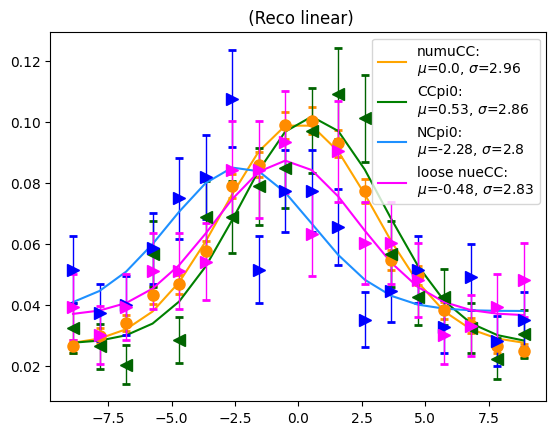

In [65]:
#reco_Eproton>35 Np
#reco_Eproton<35 0p

time_col = "merge_time"
df = df_numi_data
label = ""

nbins = 18

# Helper for query string
time_query = f"{time_col}>-9.42 and {time_col}<9.42"

data_numuCC = df.query(time_query).query("numu_score>0.9")[time_col].to_numpy()
norm1 = len(data_numuCC)
y, xbins = np.histogram(data_numuCC, bins=nbins, range=(-9.42, 9.42))
x1 = get_bin_centers(xbins)
popt, pcov = curve_fit(gaus, x1, y / norm1)
print("numuCC: Gaussian      mean:", round(popt[1], 4), "  std:", round(popt[2], 4), "  C:", round(popt[3], 4))

data_CCpi0 = df.query(time_query).query(CCpi0_query)[time_col].to_numpy()
norm2 = len(data_CCpi0)
y2, xbins = np.histogram(data_CCpi0, bins=nbins, range=(-9.42, 9.42))
x2 = get_bin_centers(xbins)
popt2, pcov2 = curve_fit(gaus, x2, y2 / norm2)
print("CCpi0: Gaussian      mean:", round(popt2[1], 4), "  std:", round(popt2[2], 4), "  C:", round(popt2[3], 4))

data_NCpi0 = df.query(time_query).query(NCpi0_query)[time_col].to_numpy()
norm3 = len(data_NCpi0)
y3, xbins = np.histogram(data_NCpi0, bins=nbins, range=(-9.42, 9.42))
x3 = get_bin_centers(xbins)
popt3, pcov3 = curve_fit(gaus, x3, y3 / norm3)
print("NCpi0: Gaussian      mean:", round(popt3[1], 4), "  std:", round(popt3[2], 4), "  C:", round(popt3[3], 4))

data_nueCC = df.query(time_query).query("nue_score>2")[time_col].to_numpy()
norm4 = len(data_nueCC)
y4, xbins = np.histogram(data_nueCC, bins=nbins, range=(-9.42, 9.42))
x4 = get_bin_centers(xbins)
popt4, pcov4 = curve_fit(gaus, x4, y4 / norm4)
print("loose nueCC: Gaussian      mean:", round(popt4[1], 4), "  std:", round(popt4[2], 4), "  C:", round(popt4[3], 4))

if(label == "df_bnb_new_data"):
    label = "BNB Data: "
elif(label == "df_bnb_new_mc"):
    label = "BNB MC: "

if(time_col == "merge_time_linear_sps"):
    label = label + " (spacepoints)"
else:
    label = label + " (Reco linear)"

plt.figure()
plt.title(label)
plt.errorbar(x1, y / norm1, yerr=np.sqrt(y) / norm1, ms=8, lw=1, fmt='o', ecolor='darkorange', color='darkorange', capsize=3, capthick=2)
plt.plot(x1, gaus(x1, *popt), color='orange', label='numuCC:' + '\n' + f"$\mu$={round(popt[1],2)}, $\\sigma$={round(abs(popt[2]),2)}")

plt.errorbar(x2, y2 / norm2, yerr=np.sqrt(y2) / norm2, ms=8, lw=1, fmt='<', ecolor='darkgreen', color='darkgreen', capsize=3, capthick=2)
plt.plot(x2, gaus(x2, *popt2), color='green', label='CCpi0:' + '\n' + f"$\mu$={round(popt2[1],2)}, $\\sigma$={round(abs(popt2[2]),2)}")

plt.errorbar(x3, y3 / norm3, yerr=np.sqrt(y3) / norm3, ms=8, lw=1, fmt='>', ecolor='blue', color='blue', capsize=3, capthick=2)
plt.plot(x3, gaus(x3, *popt3), color='dodgerblue', label='NCpi0:' + '\n' + f"$\mu$={round(popt3[1],2)}, $\\sigma$={round(abs(popt3[2]),2)}")


plt.errorbar(x4,y4/norm4,yerr=np.sqrt(y4)/norm4,ms=8, lw=1,fmt='>',ecolor = 'magenta',color='magenta', capsize=3, capthick=2)
plt.plot(x4,gaus(x4,*popt4),color='magenta',label='loose nueCC:'+'\n'+f"$\mu$={round(popt4[1],2)}, $\\sigma$={round(abs(popt4[2]),2)}")

'''shift_text = f"Shifts:\nCCpi0 = {shift_ccpi0}\nNCpi0 = {shift_ncpi0}\nNue = {shift_nue}"
plt.gcf().text(1.1, 0.2, shift_text, fontsize=12, va='center', ha='right', bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'))
'''

plt.legend()
plt.show()



# Graphing


100%|██████████| 440/440 [00:00<00:00, 436803.26it/s]


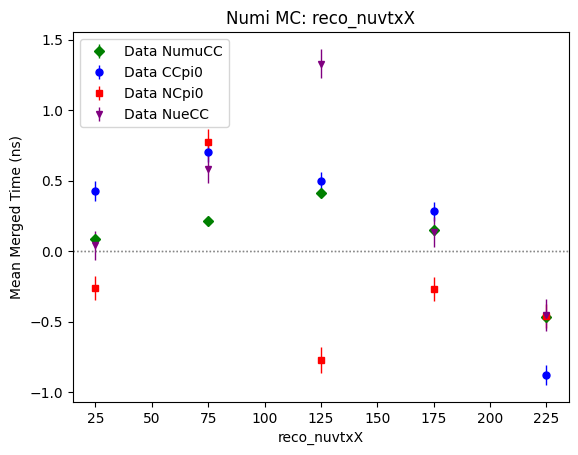

100%|██████████| 440/440 [00:00<00:00, 439612.62it/s]


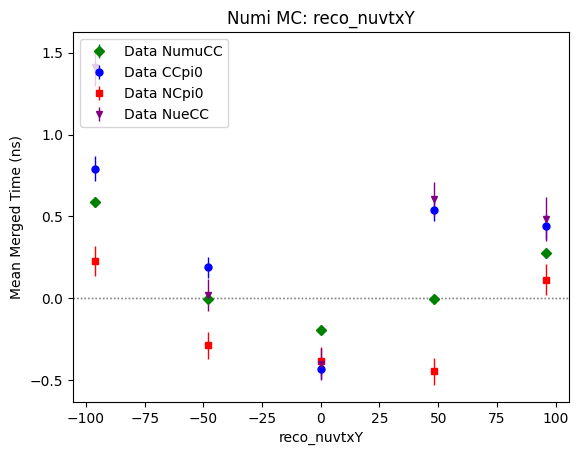

100%|██████████| 440/440 [00:00<00:00, 439612.62it/s]


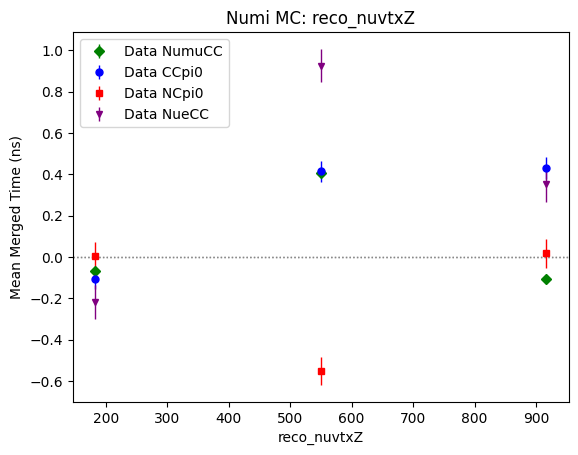

100%|██████████| 440/440 [00:00<00:00, 219649.34it/s]


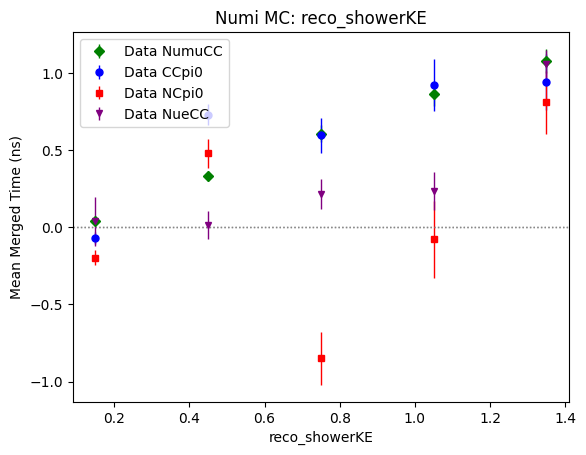

In [66]:
plot_merge_time_spread("reco_nuvtxX", np.linspace(0, 250, 6), 30, "nue_score > 4")
plt.show()
plot_merge_time_spread("reco_nuvtxY", np.linspace(-120,120, 6), 30, "nue_score > 4")
plt.show()
plot_merge_time_spread("reco_nuvtxZ", np.linspace(0, 1100, 4), 30, "nue_score > 4")
plt.show()
plot_merge_time_spread("reco_showerKE", np.linspace(0, 1.5, 6), 30, "nue_score > 4")
plt.show()


In [67]:
'''plot_merge_time_spread("gamma_1_mom_0", np.linspace(-200, 200, 6), 20)
plt.text(1.2, 1, "Sorted by Energy", transform=plt.gca().transAxes, va='center')
plt.show()

plot_merge_time_spread("gamma_2_mom_0", np.linspace(-100, 100, 6), 20)
plt.text(1.2, 1, "Sorted by Energy", transform=plt.gca().transAxes, va='center')
plt.show()

plot_merge_time_spread("gamma_lead_mom_0", np.linspace(-200, 200, 6), 20)
plt.text(1.2, 1, "Sorted by Momentum", transform=plt.gca().transAxes, va='center')
plt.show()

plot_merge_time_spread("gamma_trail_mom_0", np.linspace(-100, 100, 6), 20)
plt.text(1.2, 1, "Sorted by Momentum", transform=plt.gca().transAxes, va='center')
plt.show()

plot_merge_time_spread("reco_pi0_mom", np.linspace(0, 500, 5), 20)
plt.show()

plot_merge_time_spread("reco_pi0_mom_0", np.linspace(-200, 200, 6), 20)
plt.show()

plot_merge_time_spread("reco_pi0_mom_1", np.linspace(0, 120, 6), 15)
plt.text(1.2, 1, "Data vs MC", transform=plt.gca().transAxes, va='center')
plt.show()

plot_merge_time_spread("reco_pi0_mom_2", np.linspace(0, 120, 6), 10)
plt.show()

plot_merge_time_spread("reco_pi0_phi", np.linspace(-np.pi, np.pi, 6), 25)
plt.text(1.2, 1, "Data vs MC NCpi0", transform=plt.gca().transAxes, va='center')
plt.show()

plot_merge_time_spread("reco_pi0_cosphi", np.linspace(-1, 1, 6), 15)
plt.show()

plot_merge_time_spread("reco_pi0_theta", np.linspace(0, np.pi, 6), 20)
plt.show()

plot_merge_time_spread("reco_pi0_costheta", np.linspace(-1, 1, 4), 15)
plt.show()

plot_merge_time_spread("reco_pi0_costheta_CM", np.linspace(-1, 1, 6), 15)
plt.show()'''

'plot_merge_time_spread("gamma_1_mom_0", np.linspace(-200, 200, 6), 20)\nplt.text(1.2, 1, "Sorted by Energy", transform=plt.gca().transAxes, va=\'center\')\nplt.show()\n\nplot_merge_time_spread("gamma_2_mom_0", np.linspace(-100, 100, 6), 20)\nplt.text(1.2, 1, "Sorted by Energy", transform=plt.gca().transAxes, va=\'center\')\nplt.show()\n\nplot_merge_time_spread("gamma_lead_mom_0", np.linspace(-200, 200, 6), 20)\nplt.text(1.2, 1, "Sorted by Momentum", transform=plt.gca().transAxes, va=\'center\')\nplt.show()\n\nplot_merge_time_spread("gamma_trail_mom_0", np.linspace(-100, 100, 6), 20)\nplt.text(1.2, 1, "Sorted by Momentum", transform=plt.gca().transAxes, va=\'center\')\nplt.show()\n\nplot_merge_time_spread("reco_pi0_mom", np.linspace(0, 500, 5), 20)\nplt.show()\n\nplot_merge_time_spread("reco_pi0_mom_0", np.linspace(-200, 200, 6), 20)\nplt.show()\n\nplot_merge_time_spread("reco_pi0_mom_1", np.linspace(0, 120, 6), 15)\nplt.text(1.2, 1, "Data vs MC", transform=plt.gca().transAxes, va=\'ce

In [68]:
'''plot_merge_time_spread("kine_pio_theta_lead", np.linspace(0, 180, 4), 80)
plt.show()

plot_merge_time_spread("kine_pio_theta_trail", np.linspace(0, 180, 4), 70)
plt.show()

plot_merge_time_spread("kine_pio_phi_lead", np.linspace(-2*np.pi, 2*np.pi, 4), 80)
plt.show()

plot_merge_time_spread("kine_pio_phi_trail", np.linspace(-2*np.pi, 2*np.pi, 4), 10)
plt.show()



plot_merge_time_spread("kine_pio_dis_lead", np.linspace(0, 120, 6), 20)
plt.show()

plot_merge_time_spread("kine_pio_dis_trail", np.linspace(0, 100, 4), 20)
plt.show()
'''

'plot_merge_time_spread("kine_pio_theta_lead", np.linspace(0, 180, 4), 80)\nplt.show()\n\nplot_merge_time_spread("kine_pio_theta_trail", np.linspace(0, 180, 4), 70)\nplt.show()\n\nplot_merge_time_spread("kine_pio_phi_lead", np.linspace(-2*np.pi, 2*np.pi, 4), 80)\nplt.show()\n\nplot_merge_time_spread("kine_pio_phi_trail", np.linspace(-2*np.pi, 2*np.pi, 4), 10)\nplt.show()\n\n\n\nplot_merge_time_spread("kine_pio_dis_lead", np.linspace(0, 120, 6), 20)\nplt.show()\n\nplot_merge_time_spread("kine_pio_dis_trail", np.linspace(0, 100, 4), 20)\nplt.show()\n'

In [69]:
'''plot_merge_time_spread("kine_reco_Enu", np.linspace(0, 2000, 6), 40)
plt.show()

plot_merge_time_spread("Ehadron", np.linspace(0,2500, 6), 40)
plt.show()

plot_merge_time_spread("reco_proton_costheta", np.linspace(-1,1,6), 90)
plt.show()

plot_merge_time_spread("reco_proton_phi", np.linspace(-np.pi, np.pi, 6), 30)
plt.show()

#[0, 250, 400, 550, 700, 900, 2000], low stats(most in -1000)
plot_merge_time_spread("reco_Emuon", np.linspace(0, 2000, 6), 20)
plt.show()

#muon doesn't apply to pi0
plot_merge_time_spread("reco_muon_costheta", np.linspace(-1, 1, 6), 60)
plt.show()

plot_merge_time_spread("reco_muon_phi", np.linspace(-np.pi, np.pi, 6), 30)
plt.show()

plot_merge_time_spread("pio_mass", np.linspace(0, 300, 6), 40)
plt.show()

#plot_merge_time_spread("kine_pio_vtx_dis", np.linspace(0, 30, 6), 80) high grouping

plot_merge_time_spread("kine_pio_energy_1", np.linspace(0, 600, 6), 100)
plt.show()

plot_merge_time_spread("kine_pio_energy_2", np.linspace(0, 600, 6), 100)
plt.show()

plot_merge_time_spread("kine_pio_theta_1", np.linspace(0, 180, 6), 80)
plt.show()

plot_merge_time_spread("kine_pio_theta_2", np.linspace(0, 180, 6), 70)
plt.show()

plot_merge_time_spread("kine_pio_phi_1", np.linspace(-2*np.pi, 2*np.pi, 6), 80)
plt.show()

plot_merge_time_spread("kine_pio_dis_1", np.linspace(0, 100, 6), 30)
plt.show()

plot_merge_time_spread("kine_pio_dis_2", np.linspace(0, 100, 6), 30)
plt.show()

plot_merge_time_spread("kine_pio_angle", np.linspace(0, 180, 6), 80)
plt.show()'''

'plot_merge_time_spread("kine_reco_Enu", np.linspace(0, 2000, 6), 40)\nplt.show()\n\nplot_merge_time_spread("Ehadron", np.linspace(0,2500, 6), 40)\nplt.show()\n\nplot_merge_time_spread("reco_proton_costheta", np.linspace(-1,1,6), 90)\nplt.show()\n\nplot_merge_time_spread("reco_proton_phi", np.linspace(-np.pi, np.pi, 6), 30)\nplt.show()\n\n#[0, 250, 400, 550, 700, 900, 2000], low stats(most in -1000)\nplot_merge_time_spread("reco_Emuon", np.linspace(0, 2000, 6), 20)\nplt.show()\n\n#muon doesn\'t apply to pi0\nplot_merge_time_spread("reco_muon_costheta", np.linspace(-1, 1, 6), 60)\nplt.show()\n\nplot_merge_time_spread("reco_muon_phi", np.linspace(-np.pi, np.pi, 6), 30)\nplt.show()\n\nplot_merge_time_spread("pio_mass", np.linspace(0, 300, 6), 40)\nplt.show()\n\n#plot_merge_time_spread("kine_pio_vtx_dis", np.linspace(0, 30, 6), 80) high grouping\n\nplot_merge_time_spread("kine_pio_energy_1", np.linspace(0, 600, 6), 100)\nplt.show()\n\nplot_merge_time_spread("kine_pio_energy_2", np.linspace

["truth_nuEnergy", "truth_nu_pos", "truth_nu_momentum", "truth_vtxX", "truth_vtxY", "truth_vtxZ", "truth_nuTime", "truth_isCC",
                        "truth_muonMomentum", "truth_muonvtxX", "truth_muonvtxY", "truth_muonvtxZ",
                        "truth_muonendX", "truth_muonendY", "truth_muonendZ", "truth_startMomentum", "truth_endMomentum",]


In [70]:
df_numi_mc["truth_nu_momentum_0"] = df_numi_mc["truth_nu_momentum"].apply(lambda x: x[0])
df_numi_mc["truth_nu_momentum_1"] = df_numi_mc["truth_nu_momentum"].apply(lambda x: x[1])
df_numi_mc["truth_nu_momentum_2"] = df_numi_mc["truth_nu_momentum"].apply(lambda x: x[2])
df_numi_mc["truth_nu_momentum_3"] = df_numi_mc["truth_nu_momentum"].apply(lambda x: x[3])

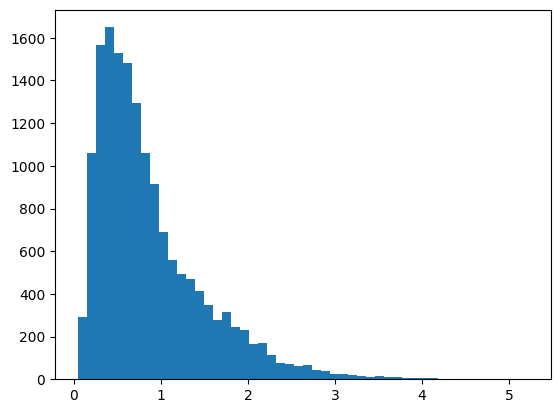

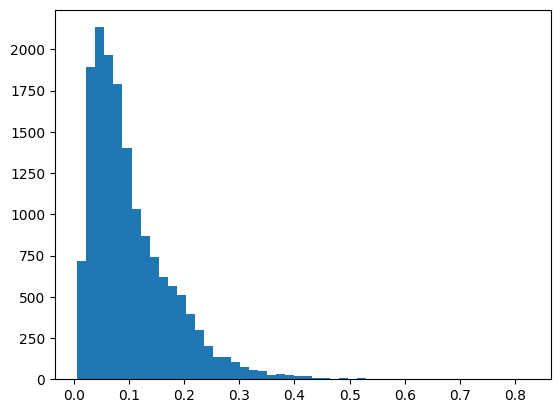

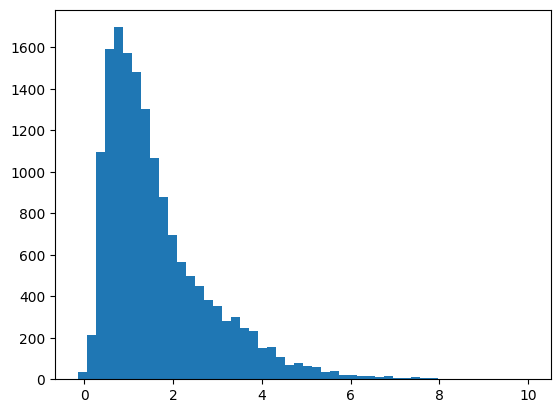

In [71]:
plt.hist(df_numi_mc["truth_nu_momentum_0"], bins=50)
plt.show()
plt.hist(df_numi_mc["truth_nu_momentum_1"], bins=50)
plt.show()
plt.hist(df_numi_mc["truth_nu_momentum_2"], bins=50)
plt.show()

100%|██████████| 440/440 [00:00<00:00, 219701.64it/s]


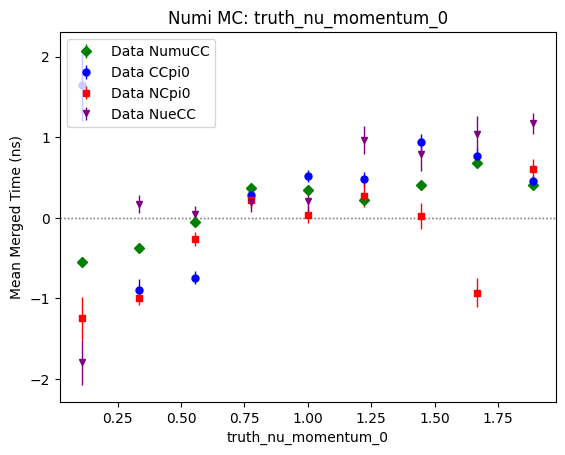

100%|██████████| 440/440 [00:00<00:00, 447826.68it/s]


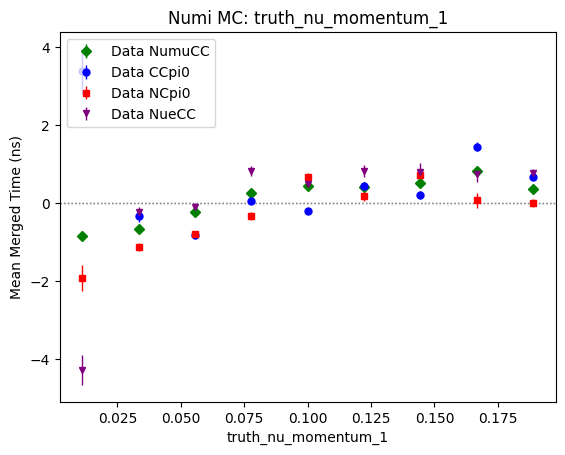

100%|██████████| 440/440 [00:00<00:00, 440241.83it/s]


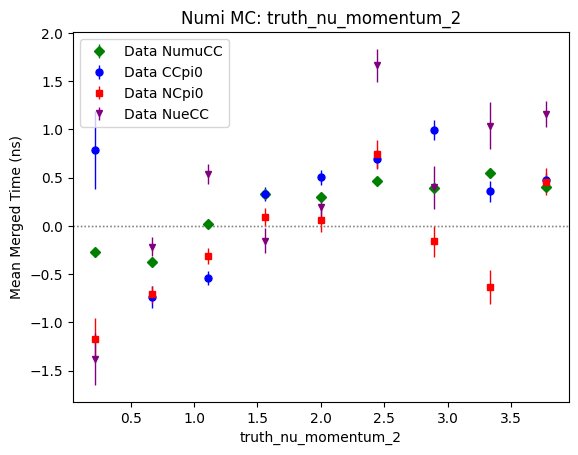

In [72]:
plot_merge_time_spread("truth_nu_momentum_0", np.linspace(0, 2, 10), 40)
plt.show()

plot_merge_time_spread("truth_nu_momentum_1", np.linspace(0, 0.2, 10), 40)
plt.show()

plot_merge_time_spread("truth_nu_momentum_2", np.linspace(0, 4, 10), 40)
plt.show()


In [73]:
def get_angle(momentum_0,momentum_1,momentum_2,to_numi=False):
    momentum_0_new = momentum_0
    momentum_1_new = momentum_1
    momentum_2_new = momentum_2    
    if to_numi:
        R = np.array([[0.9210,0.0227,0.3889], 
        [0.00005,0.9983,-0.0584],
        [-0.3895,0.05383,0.9195]])
        R = np.linalg.inv(R)
        momentum_0_new = momentum_0*R[0][0] + momentum_1*R[0][1] + momentum_2*R[0][2] 
        momentum_1_new = momentum_0*R[1][0] + momentum_1*R[1][1] + momentum_2*R[1][2]
        momentum_2_new = momentum_0*R[2][0] + momentum_1*R[2][1] + momentum_2*R[2][2]
    
    momentum_perp = np.sqrt(momentum_0_new * momentum_0_new + momentum_1_new * momentum_1_new)
    # defined in https://root.cern/doc/master/TVector3_8cxx_source.html
    theta = np.arctan2(momentum_perp, momentum_2_new)
    phi = np.arctan2(momentum_1_new, momentum_0_new)
    return theta, phi

In [74]:
df_numi_mc["truth_nu_theta"], df_numi_mc["truth_nu_phi"] = get_angle(df_numi_mc["truth_nu_momentum_0"], df_numi_mc["truth_nu_momentum_1"], df_numi_mc["truth_nu_momentum_2"], to_numi=True)

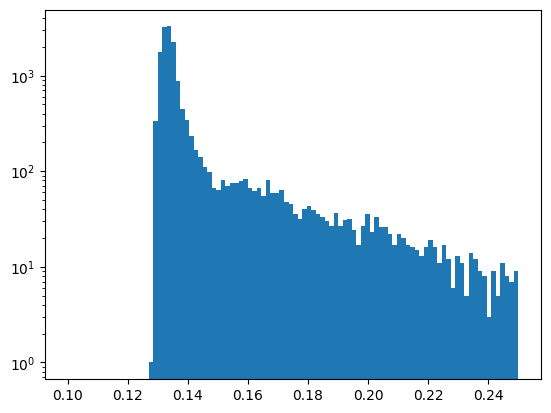

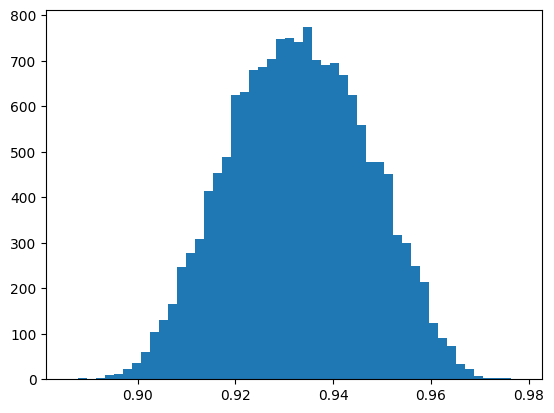

In [75]:
plt.hist(df_numi_mc["truth_nu_theta"], bins=100, range=(0.1,0.25))
plt.yscale('log')
plt.show()
plt.hist(df_numi_mc["truth_nu_phi"], bins=50)
plt.show()

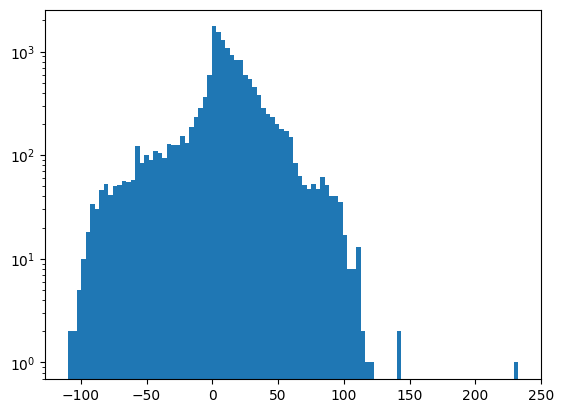

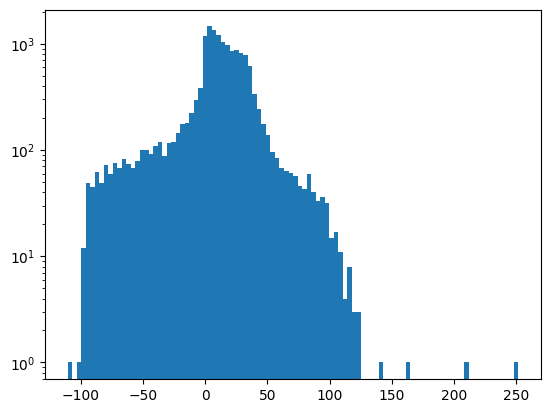

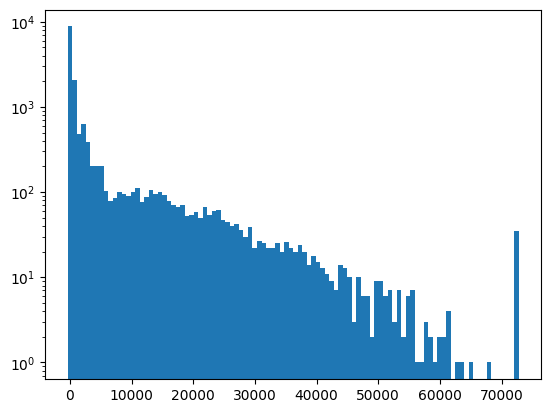

In [76]:
plt.hist(df_numi_mc["mcflux_vx"], bins=100)
plt.yscale('log')
plt.show()

plt.hist(df_numi_mc["mcflux_vy"], bins=100)
plt.yscale('log')
plt.show()

plt.hist(df_numi_mc["mcflux_vz"], bins=100)
plt.yscale('log')
plt.show()

100%|██████████| 440/440 [00:00<00:00, 219963.50it/s]


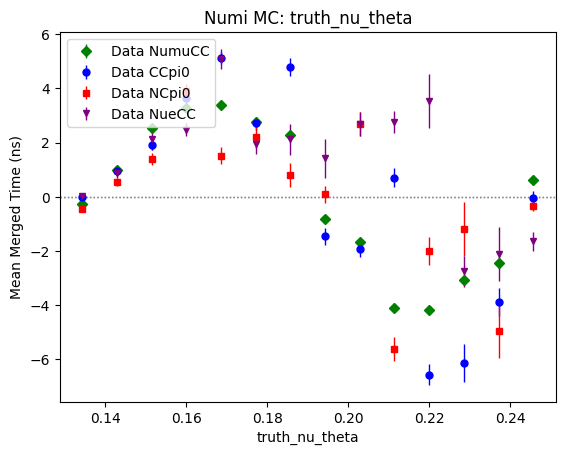

100%|██████████| 440/440 [00:00<00:00, 145371.70it/s]


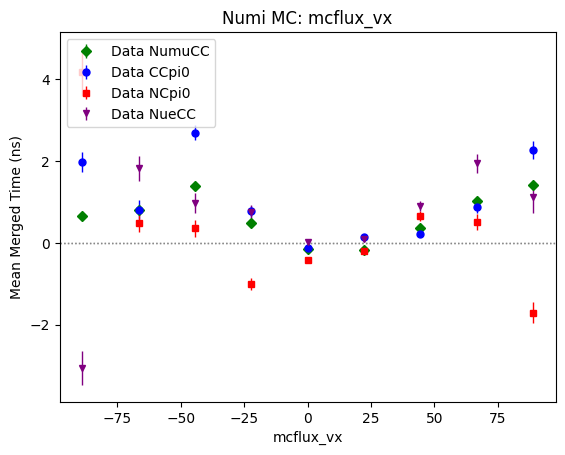

100%|██████████| 440/440 [00:00<00:00, 165056.23it/s]


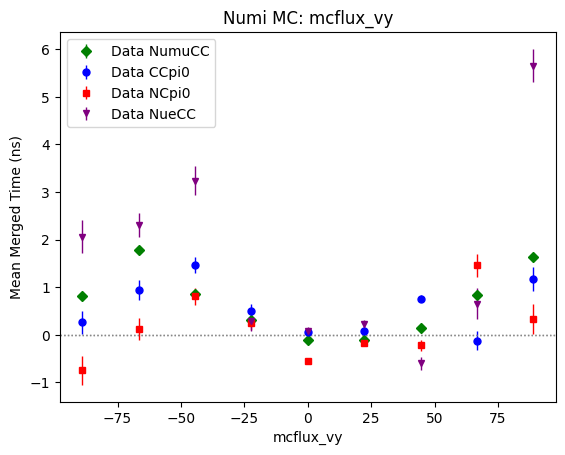

100%|██████████| 440/440 [00:00<00:00, 272800.26it/s]


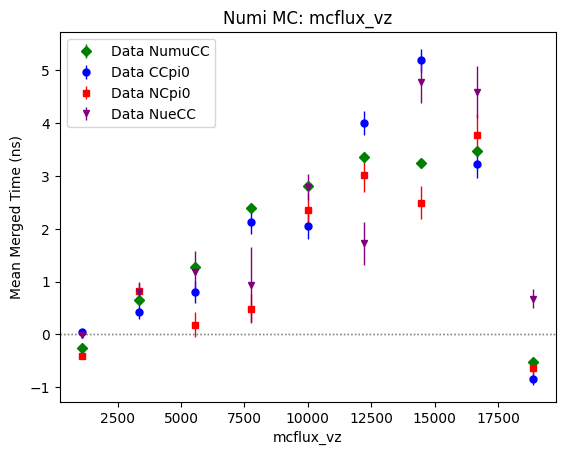

In [77]:
plot_merge_time_spread("truth_nu_theta", np.linspace(0.13, 0.25, 15), 40)
plt.show()
plot_merge_time_spread("mcflux_vx", np.linspace(-100,100,10), 40)
plt.show()
plot_merge_time_spread("mcflux_vy", np.linspace(-100,100,10), 40)
plt.show()
plot_merge_time_spread("mcflux_vz", np.linspace(0,20000,10), 40)
plt.show()

In [78]:
target_dir = np.array([-0.46, -0.05, -0.885])
min_a = -122.86902944472968  
min_b = 80.60659897339974 
min_c = 59.34119182916038
min_d = 0.02753117290126994

x = df_numi_mc['truth_vtxX'].to_numpy()
y = df_numi_mc['truth_vtxY'].to_numpy()
z = df_numi_mc['truth_vtxZ'].to_numpy()

times_adjusted = []

for i in range(len(x)):

    #find the correct correction
    dist = ( (min_a-x[i])*target_dir[0] + (min_b-y[i])*target_dir[1] + (min_c-z[i])*target_dir[2] ) / np.sqrt(target_dir[0]**2 + target_dir[1]**2 + target_dir[2]**2 )
    new_time_cor = dist*0.033356

        
    times_adjusted.append(new_time_cor)

df_numi_mc["times_adjusted"] = times_adjusted

In [79]:
gap = 18.83050847457627
Shift = -113.3

ns_time =  df_numi_mc['cor_nu_time'].to_numpy()-df_numi_mc["times_adjusted"].to_numpy()

merge_times = []
abs_merge_times = []
for i in range(len(ns_time)):
    
    TThelp = ns_time[i]-Shift+gap*0.5
    TT_merged=-9999

    if TThelp>=0:
        TT_merged=(TThelp-(int((TThelp)/gap))*gap)-gap*0.5
        abs_merge_times.append(abs(TT_merged))
    else: abs_merge_times.append(-999)
        
    merge_times.append(TT_merged)

df_numi_mc["merge_time_truth"] = merge_times
df_numi_mc["abs_merge_time_truth"] = abs_merge_times

data1: Gaussian      mean: -0.4425   std: 2.615   C: 132.4725
data2: Gaussian      mean: 0.3265   std: 2.4777   C: 14.8528
data3: Gaussian      mean: 1.1423   std: 2.44   C: 6.5927
data4: Gaussian      mean: 1.9276   std: 2.8402   C: 2.7995


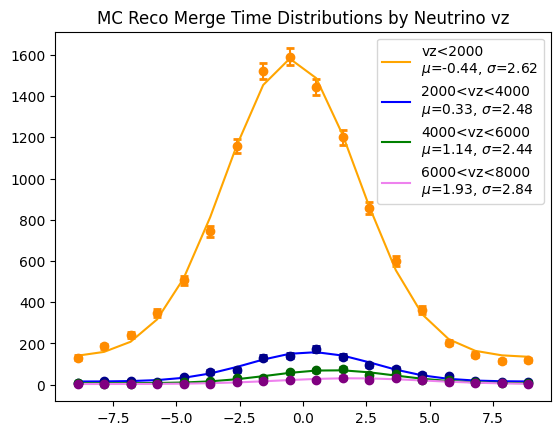

In [80]:
label = "MC Reco Merge Time Distributions by Neutrino vz"
time_col = "merge_time"
nbins = 18
time_query = f"{time_col}>-9.42 and {time_col}<9.42"

# --- Range 1: mcflux_vz < 2000 ---
data1 = df_numi_mc.query(time_query).query("mcflux_vz<2000")[time_col].to_numpy()
norm1 = 1
y1, xbins = np.histogram(data1, bins=nbins, range=(-9.42, 9.42))
x1 = get_bin_centers(xbins)
popt1, pcov1 = curve_fit(gaus, x1, y1 / norm1)
print("data1: Gaussian      mean:", round(popt1[1], 4), "  std:", round(popt1[2], 4), "  C:", round(popt1[3], 4))

# --- Range 2: 2000 < mcflux_vz < 4000 ---
data2 = df_numi_mc.query(time_query).query("mcflux_vz>2000 and mcflux_vz<4000")[time_col].to_numpy()
norm2 = 1
y2, _ = np.histogram(data2, bins=nbins, range=(-9.42, 9.42))
x2 = get_bin_centers(xbins)
popt2, pcov2 = curve_fit(gaus, x2, y2 / norm2)
print("data2: Gaussian      mean:", round(popt2[1], 4), "  std:", round(popt2[2], 4), "  C:", round(popt2[3], 4))

# --- Range 3: 4000 < mcflux_vz < 6000 ---
data3 = df_numi_mc.query(time_query).query("mcflux_vz>4000 and mcflux_vz<6000")[time_col].to_numpy()
norm3 = 1
y3, _ = np.histogram(data3, bins=nbins, range=(-9.42, 9.42))
x3 = get_bin_centers(xbins)
popt3, pcov3 = curve_fit(gaus, x3, y3 / norm3)
print("data3: Gaussian      mean:", round(popt3[1], 4), "  std:", round(popt3[2], 4), "  C:", round(popt3[3], 4))

# --- Range 4: 6000 < mcflux_vz < 8000 ---
data4 = df_numi_mc.query(time_query).query("mcflux_vz>6000 and mcflux_vz<8000")[time_col].to_numpy()
norm4 = 1
y4, _ = np.histogram(data4, bins=nbins, range=(-9.42, 9.42))
x4 = get_bin_centers(xbins)
popt4, pcov4 = curve_fit(gaus, x4, y4 / norm4)
print("data4: Gaussian      mean:", round(popt4[1], 4), "  std:", round(popt4[2], 4), "  C:", round(popt4[3], 4))

# --- Plot ---
plt.figure()
plt.title(label)

plt.errorbar(x1, y1 / norm1, yerr=np.sqrt(y1) / norm1, fmt='o', color='darkorange', ecolor='darkorange', capsize=3, capthick=2)
plt.plot(x1, gaus(x1, *popt1), color='orange', label='vz<2000\n' + f"$\mu$={round(popt1[1],2)}, $\\sigma$={round(abs(popt1[2]),2)}")

plt.errorbar(x2, y2 / norm2, yerr=np.sqrt(y2) / norm2, fmt='o', color='darkblue', ecolor='darkblue', capsize=3, capthick=2)
plt.plot(x2, gaus(x2, *popt2), color='blue', label='2000<vz<4000\n' + f"$\mu$={round(popt2[1],2)}, $\\sigma$={round(abs(popt2[2]),2)}")

plt.errorbar(x3, y3 / norm3, yerr=np.sqrt(y3) / norm3, fmt='o', color='darkgreen', ecolor='darkgreen', capsize=3, capthick=2)
plt.plot(x3, gaus(x3, *popt3), color='green', label='4000<vz<6000\n' + f"$\mu$={round(popt3[1],2)}, $\\sigma$={round(abs(popt3[2]),2)}")

plt.errorbar(x4, y4 / norm4, yerr=np.sqrt(y4) / norm4, fmt='o', color='purple', ecolor='purple', capsize=3, capthick=2)
plt.plot(x4, gaus(x4, *popt4), color='violet', label='6000<vz<8000\n' + f"$\mu$={round(popt4[1],2)}, $\\sigma$={round(abs(popt4[2]),2)}")

plt.legend()
plt.show()


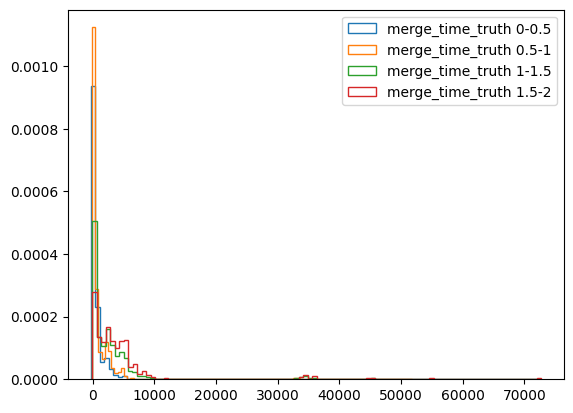

In [81]:
plt.hist(df_numi_mc.query("merge_time_truth>0 and merge_time_truth<0.5")["mcflux_vz"], bins=100, histtype='step', label='merge_time_truth 0-0.5', density=True)
plt.hist(df_numi_mc.query("merge_time_truth>0.5 and merge_time_truth<1")["mcflux_vz"], bins=100, histtype='step', label='merge_time_truth 0.5-1', density=True)
plt.hist(df_numi_mc.query("merge_time_truth>1 and merge_time_truth<2")["mcflux_vz"], bins=100, histtype='step', label='merge_time_truth 1-1.5', density=True)
plt.hist(df_numi_mc.query("merge_time_truth>1.5 and merge_time_truth<2")["mcflux_vz"], bins=100, histtype='step', label='merge_time_truth 1.5-2', density=True)
plt.legend()
plt.show()

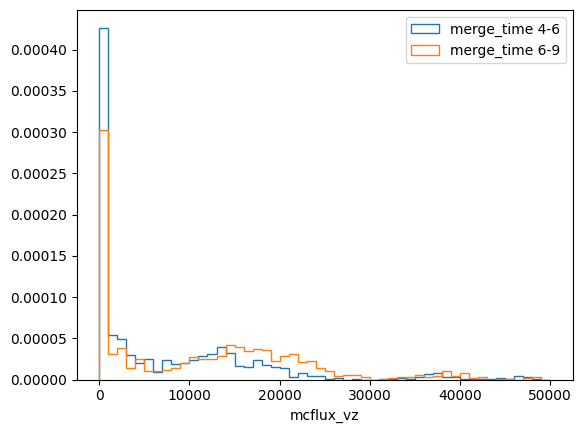

In [82]:
#plt.hist(df_numi_mc.query("merge_time>0.5")["mcflux_vz"], bins=50, range=(5000, 50000), histtype='step', label='merge_time>0.5', density=True)
plt.hist(df_numi_mc.query("merge_time>4 and merge_time<6")["mcflux_vz"], bins=50, range=(0, 50000), histtype='step', label='merge_time 4-6', density=True)
plt.hist(df_numi_mc.query("merge_time>6 and merge_time<9")["mcflux_vz"], bins=50, range=(0, 50000), histtype='step', label='merge_time 6-9', density=True)
#plt.hist(df_numi_mc.query("merge_time>8")["mcflux_vz"], bins=50, range=(5000, 50000), histtype='step', label='merge_time>8', density=True)
plt.xlabel("mcflux_vz")
plt.legend()
plt.show()


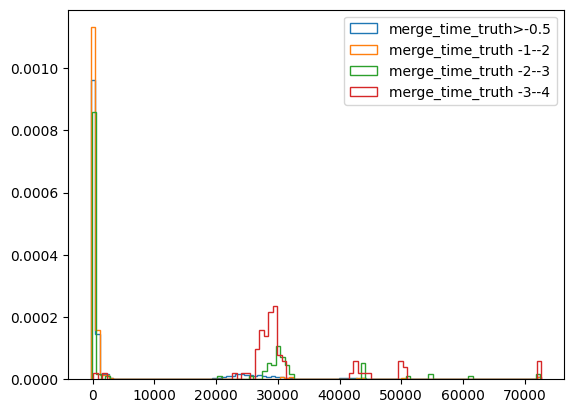

In [83]:
plt.hist(df_numi_mc.query("merge_time_truth<-0.5")["mcflux_vz"], bins=100, histtype='step', label='merge_time_truth>-0.5', density=True)
plt.hist(df_numi_mc.query("merge_time_truth<-1 and merge_time_truth>-2")["mcflux_vz"], bins=100, histtype='step', label='merge_time_truth -1--2', density=True)
plt.hist(df_numi_mc.query("merge_time_truth<-2 and merge_time_truth>-3")["mcflux_vz"], bins=100, histtype='step', label='merge_time_truth -2--3', density=True)
plt.hist(df_numi_mc.query("merge_time_truth<-3 and merge_time_truth>-4")["mcflux_vz"], bins=100, histtype='step', label='merge_time_truth -3--4', density=True)
plt.legend()
plt.show()

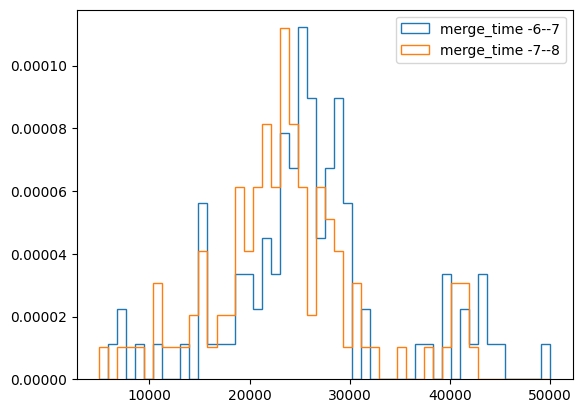

In [84]:
#plt.hist(df_numi_mc.query("merge_time<-0.5")["mcflux_vz"], bins=50, range=(5000, 50000), histtype='step', label='merge_time<-0.5', density=True)
plt.hist(df_numi_mc.query("merge_time<-6 and merge_time>-7")["mcflux_vz"], bins=50, range=(5000, 50000), histtype='step', label='merge_time -6--7', density=True)
plt.hist(df_numi_mc.query("merge_time<-7 and merge_time>-8")["mcflux_vz"], bins=50, range=(5000, 50000), histtype='step', label='merge_time -7--8', density=True)
#plt.hist(df_numi_mc.query("merge_time<-8")["mcflux_vz"], bins=50, range=(5000, 50000), histtype='step', label='merge_time<-8', density=True)
plt.legend()
plt.show()


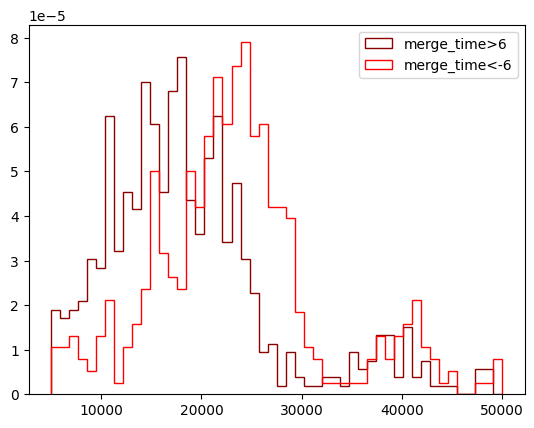

In [85]:
#plt.hist(df_numi_mc.query("merge_time>3 and merge_time<6")["mcflux_vz"],range=(5000,50000), bins=50, histtype='step', label='merge_time>3 and <6', density=True, color="darkblue")
#plt.hist(df_numi_mc.query("merge_time<-3 and merge_time>-6")["mcflux_vz"],range=(5000,50000), bins=50, histtype='step', label='merge_time<-3 and >-6', density=True, color="blue")
plt.hist(df_numi_mc.query("merge_time>6")["mcflux_vz"], range=(5000,50000), bins=50, histtype='step', label='merge_time>6', density=True, color="darkred")
plt.hist(df_numi_mc.query("merge_time<-6")["mcflux_vz"],  range=(5000,50000), bins=50, histtype='step', label='merge_time<-6', density=True, color="red")
plt.legend()
plt.show()

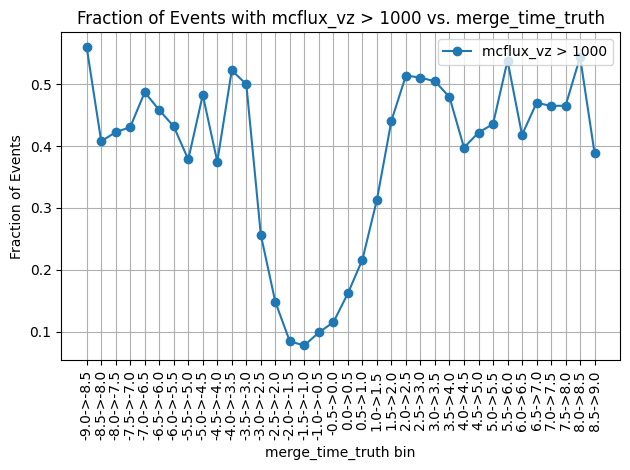

In [131]:
bin_edges = np.arange(-9, 9, 0.5)
xticks = [f"{round(i,1)}->{round(i+0.5,1)}" for i in bin_edges]

fractions = []
for i in bin_edges:
    cut = f"merge_time_truth > {i} and merge_time_truth < {i+0.5}"
    df_cut = df_numi_mc.query(cut)
    total = len(df_cut)
    if total > 0:
        passing = len(df_cut.query("mcflux_vy < 0"))
        fraction = passing / total
    else:
        fraction = np.nan
    fractions.append(fraction)

plt.figure()
plt.plot(xticks, fractions, marker='o', label="mcflux_vz > 1000")
plt.xticks(rotation=90)
plt.ylabel("Fraction of Events")
plt.xlabel("merge_time_truth bin")
plt.title("Fraction of Events with mcflux_vz > 1000 vs. merge_time_truth")
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

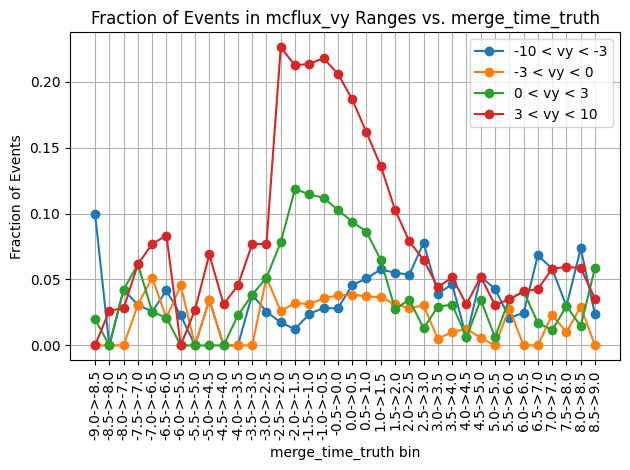

In [135]:
bin_edges = np.arange(-9, 9, 0.5)
vz_ranges = [
    (-10, -3),
    (-3, 0),
    (0, 3),
    (3, 10)
]
    
labels = [f"{low} < vy < {high}" for (low, high) in vz_ranges]
xticks = [f"{round(i,1)}->{round(i+0.5,1)}" for i in bin_edges]

plt.figure()

for (vz_min, vz_max), label in zip(vz_ranges, labels):
    fractions = []
    for i in bin_edges:
        cut = f"merge_time_truth > {i} and merge_time_truth < {i+0.5}"
        df_cut = df_numi_mc.query(cut)
        total = len(df_cut)
        if total > 0:
            passing = len(df_cut.query(f"mcflux_vy > {vz_min} and mcflux_vy < {vz_max}"))
            fraction = passing / total
        else:
            fraction = np.nan
        fractions.append(fraction)

    plt.plot(xticks, fractions, marker='o', label=label)

plt.xticks(rotation=90)
plt.ylabel("Fraction of Events")
plt.xlabel("merge_time_truth bin")
plt.title("Fraction of Events in mcflux_vy Ranges vs. merge_time_truth")
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


In [127]:
variables_to_hist = [
    "reco_nuvtxX", "reco_nuvtxY", "truth_vtxY", "reco_nuvtxZ",
    "flash_measPe", "kine_reco_Enu", "Ehadron",
    "reco_proton_costheta", "reco_proton_phi",
    "kine_pio_energy_1", "kine_pio_energy_2",
    "kine_pio_theta_1", "kine_pio_theta_2",
    "kine_pio_phi_1", "kine_pio_dis_1", "kine_pio_dis_2",
    "kine_pio_angle", "kine_pio_theta_lead", "kine_pio_theta_trail",
    "kine_pio_phi_lead", "kine_pio_phi_trail",
    "kine_pio_dis_lead", "kine_pio_dis_trail",
    "gamma_1_mom_0", "gamma_2_mom_0", "gamma_lead_mom_0", "gamma_trail_mom_0",
    "reco_pi0_mom", "reco_pi0_mom_0", "reco_pi0_mom_1", "reco_pi0_mom_2",
    "reco_pi0_phi", "reco_pi0_cosphi", "reco_pi0_theta",
    "reco_pi0_costheta", "reco_pi0_costheta_CM", "kine_pio_phi_lead", "kine_pio_dis_trail", "reco_pi0_costheta",
    "truth_nuEnergy"
]

'''selections = [
    "merge_time_truth<-4 or merge_time_truth>3",
    "merge_time_truth>-4 and merge_time_truth<3"
]'''

'''selections = [
    "merge_time<-7 or merge_time>4",
    "merge_time>-7 and merge_time<4"
]'''

selections = [
    "mcflux_vz >= 0 and mcflux_vz < 100",
    #"mcflux_vz >= 100 and mcflux_vz < 500",
    "mcflux_vz >= 1000"
]

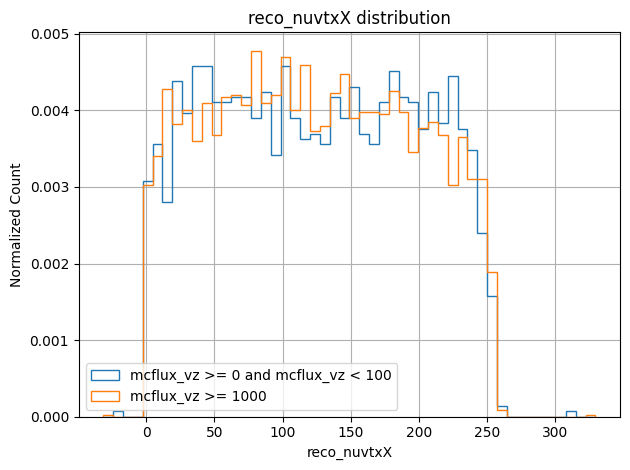

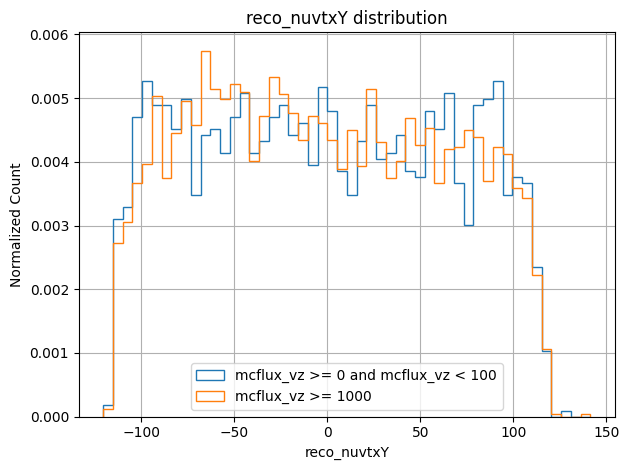

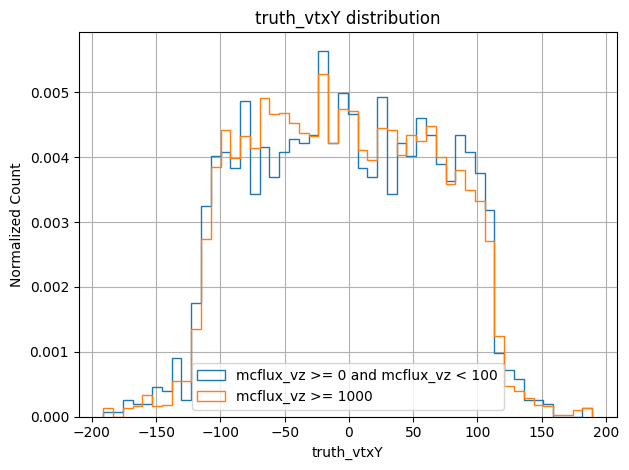

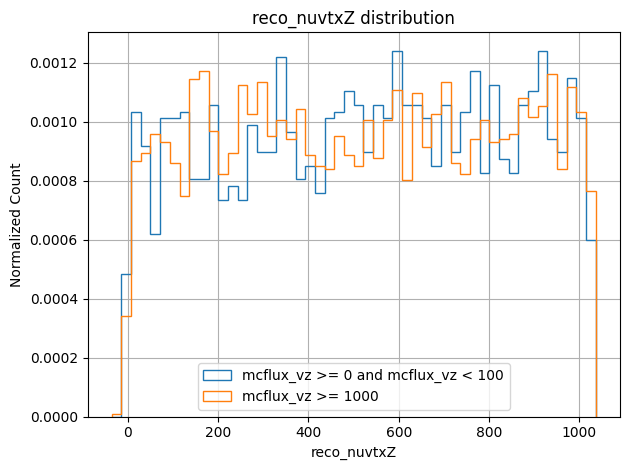

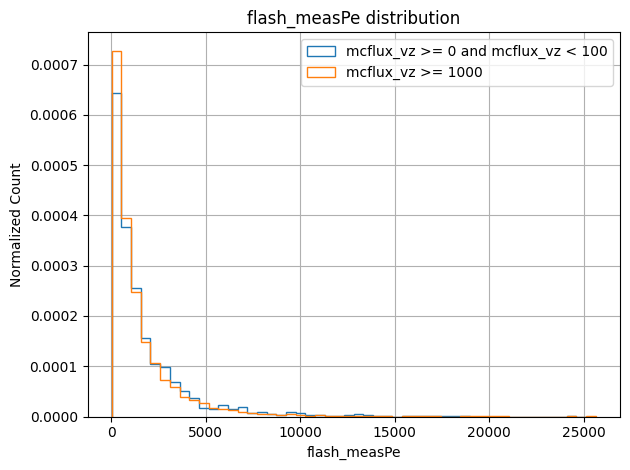

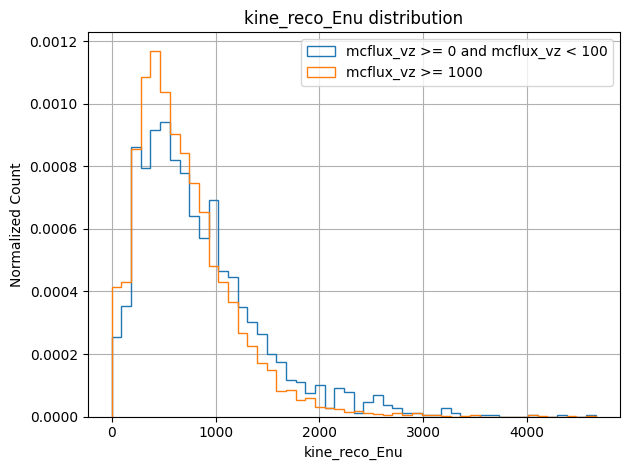

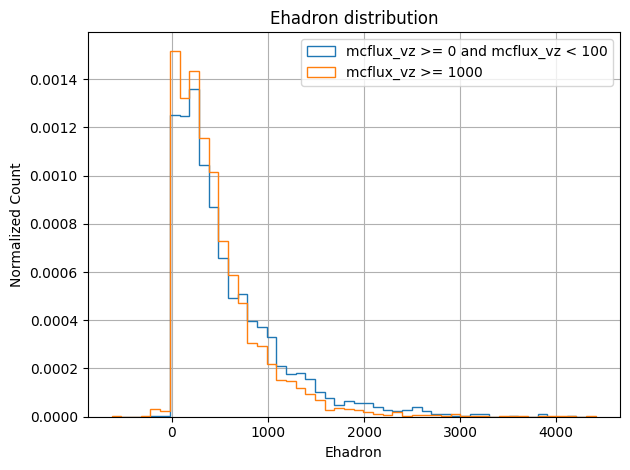

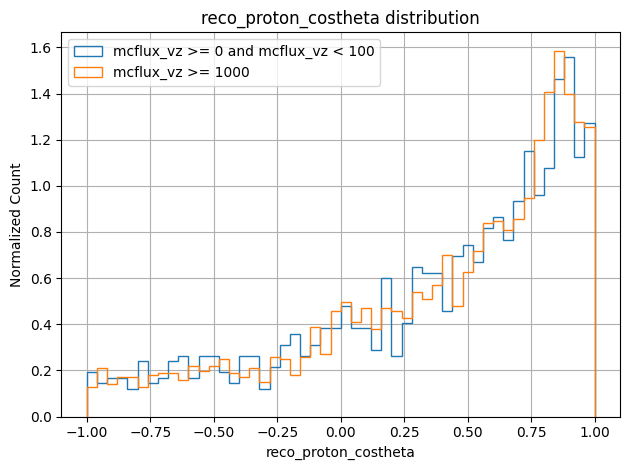

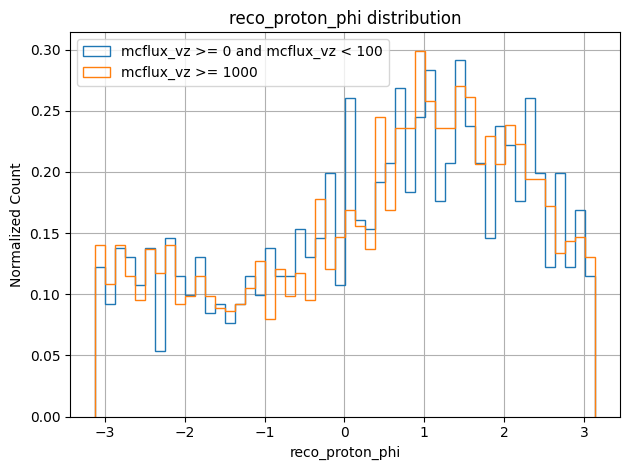

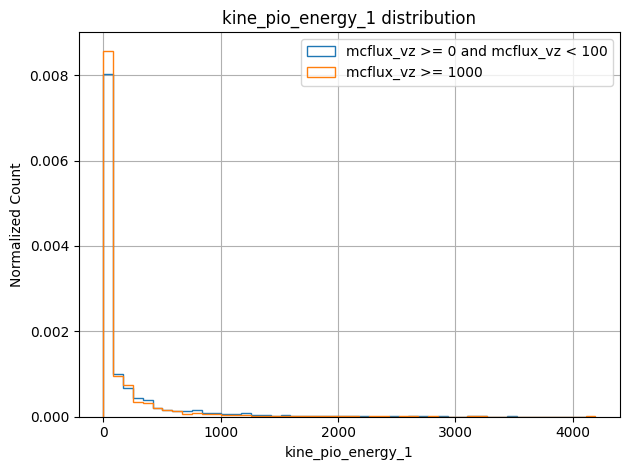

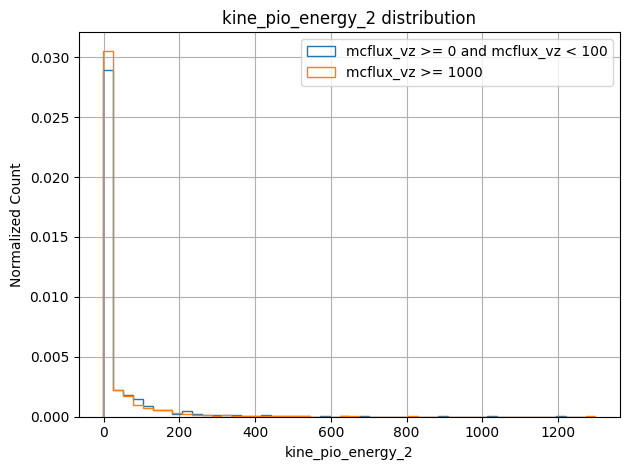

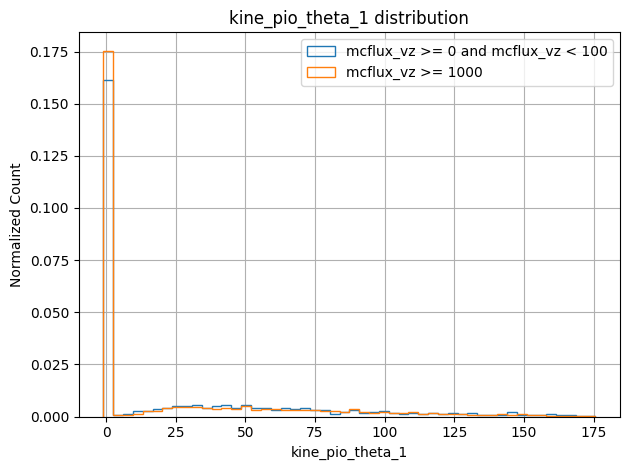

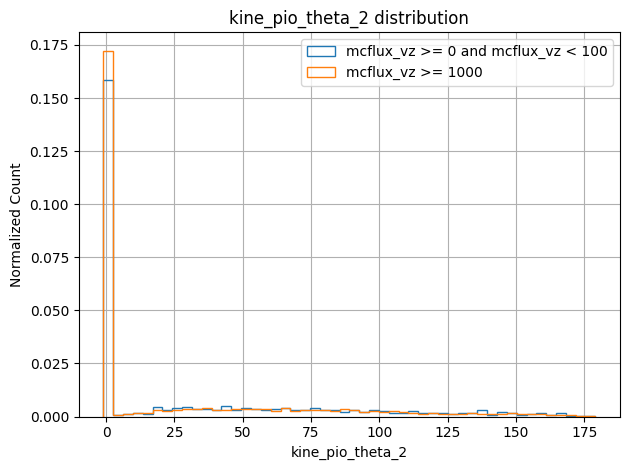

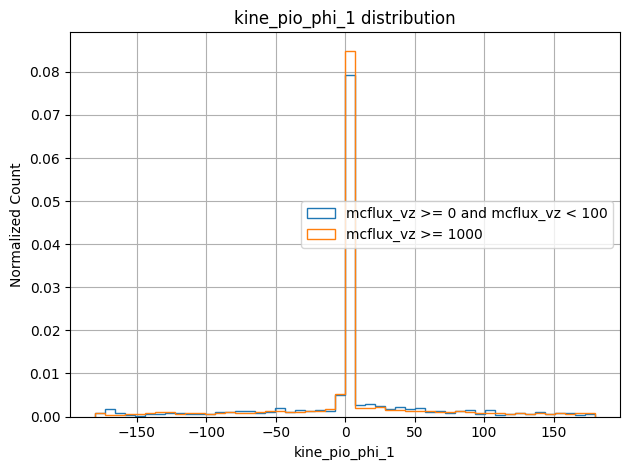

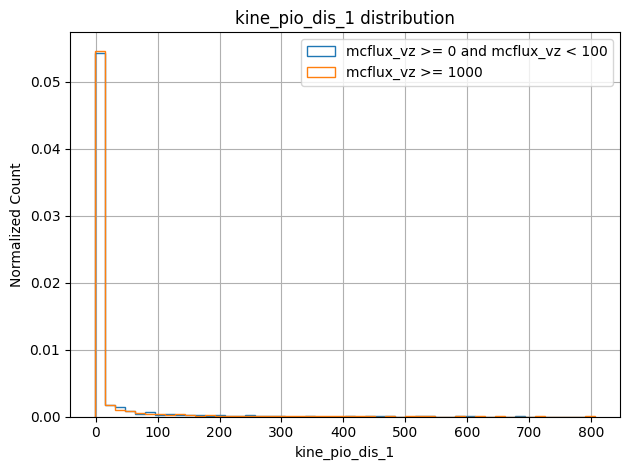

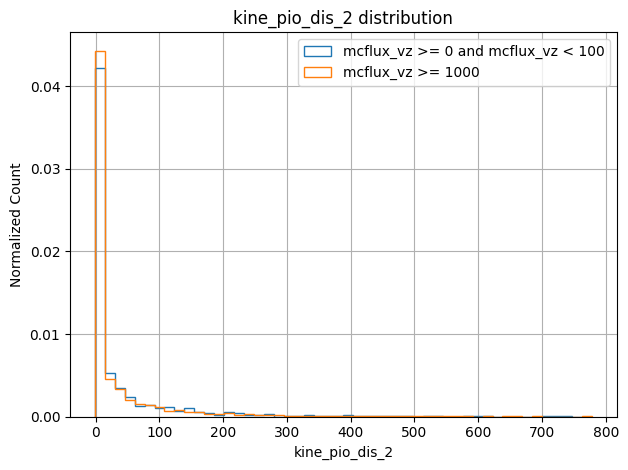

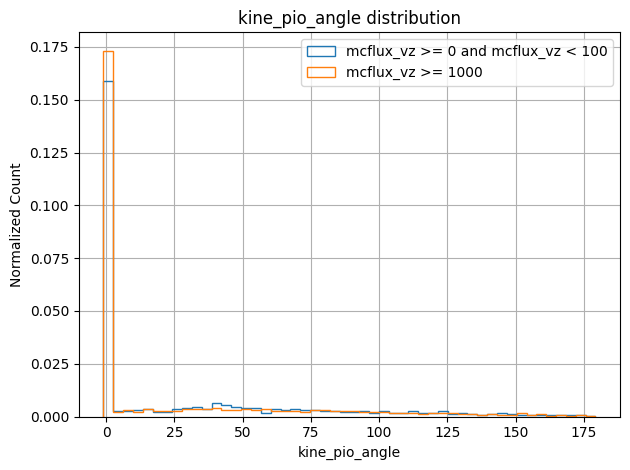

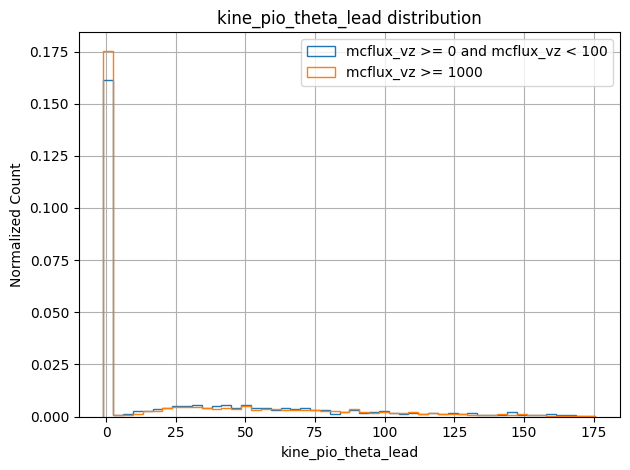

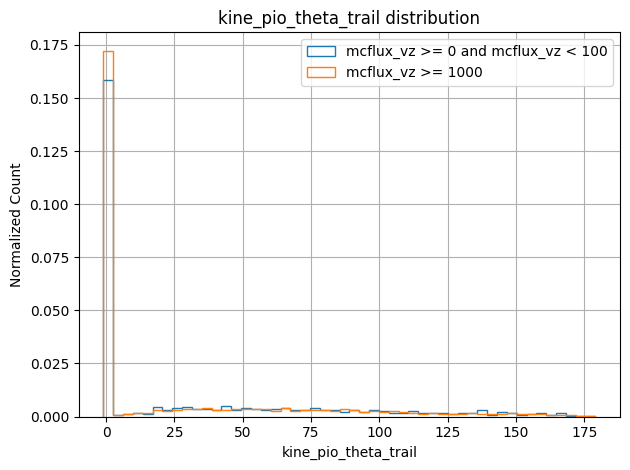

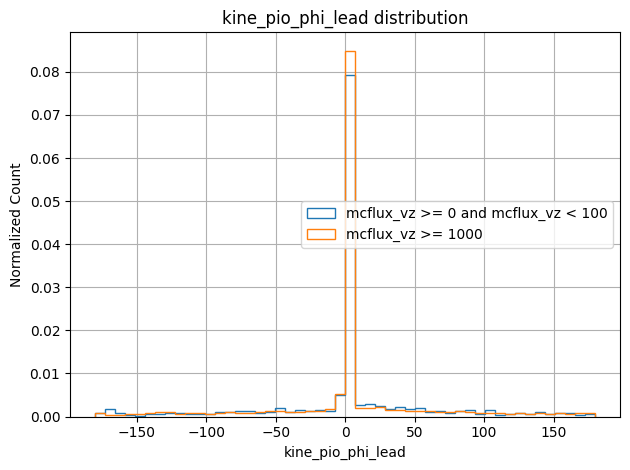

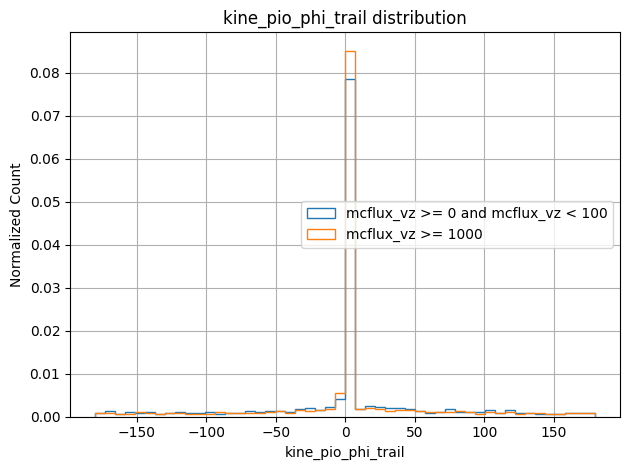

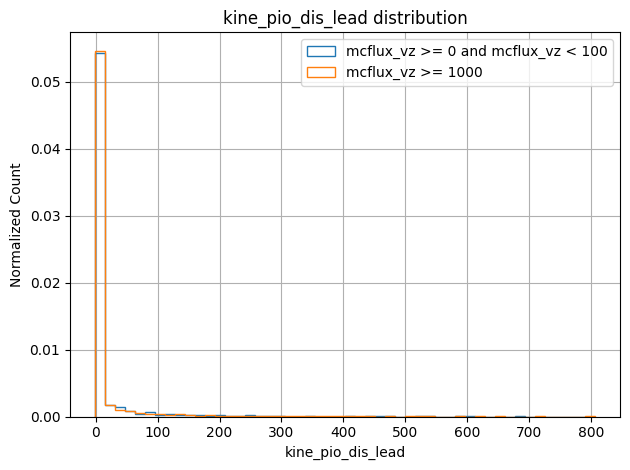

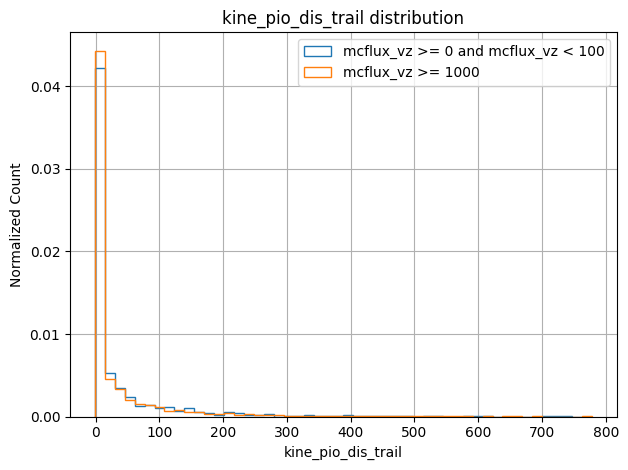

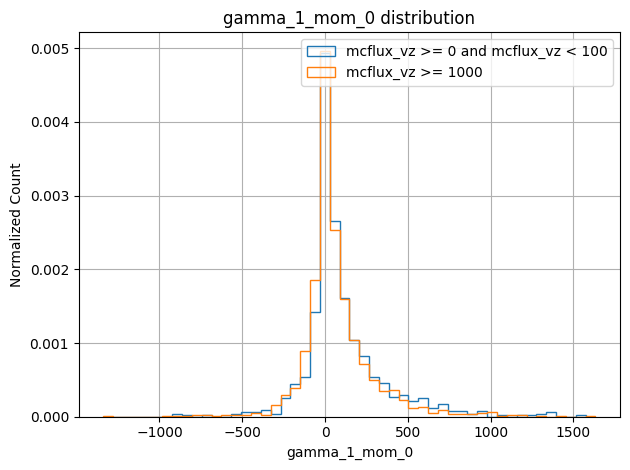

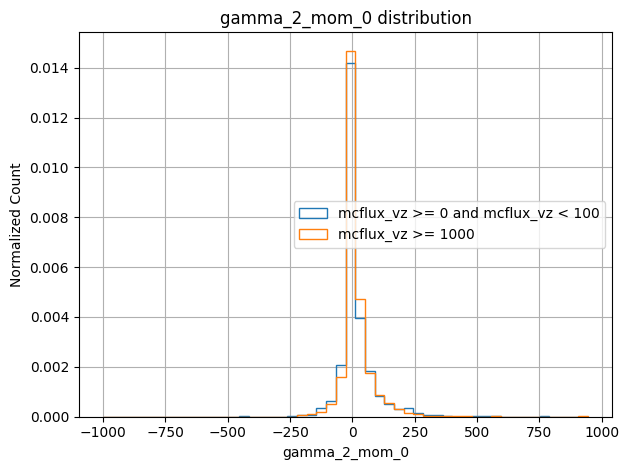

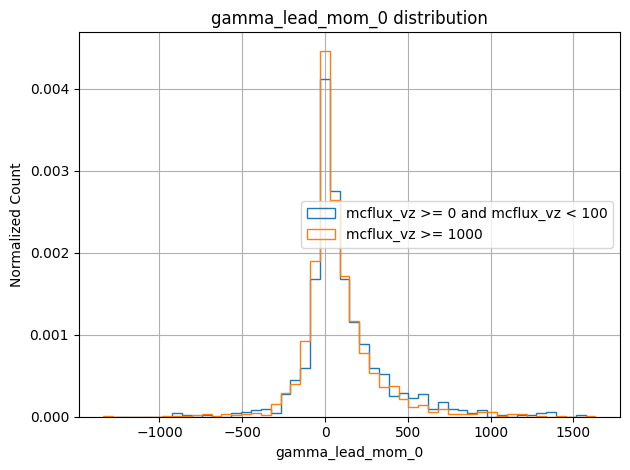

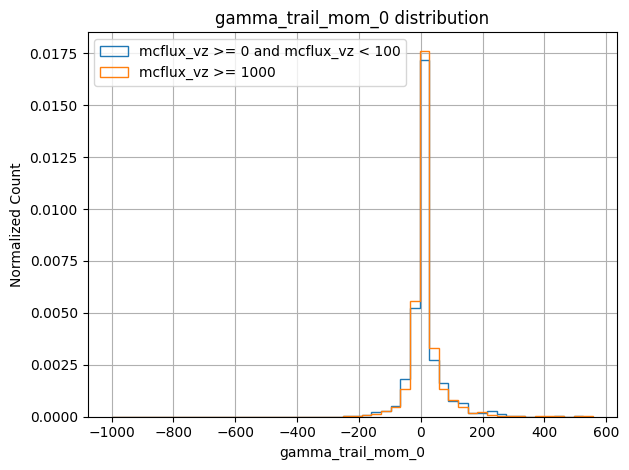

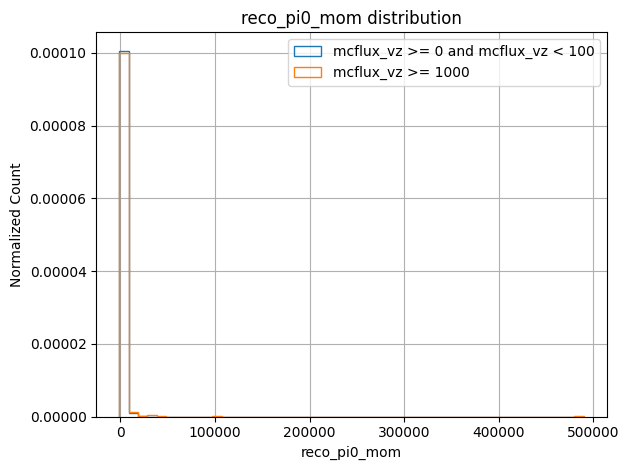

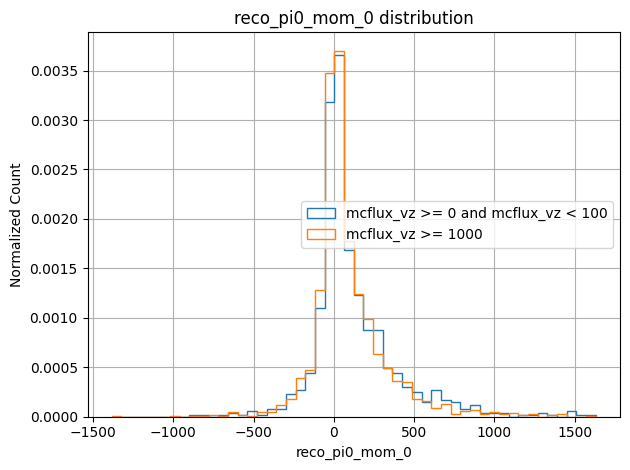

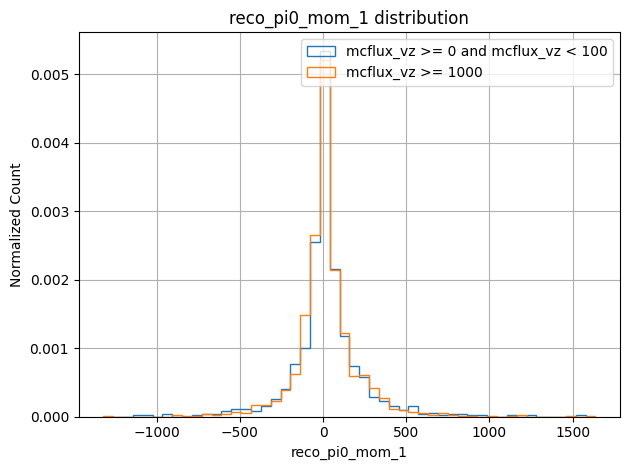

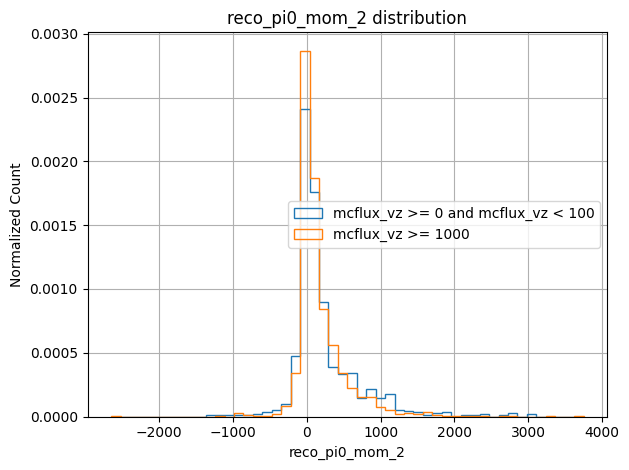

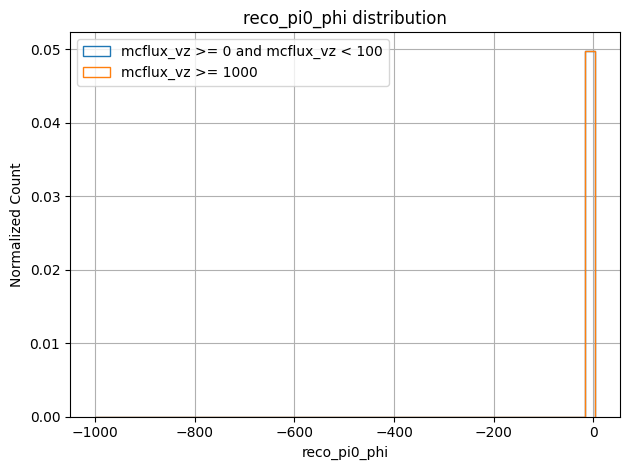

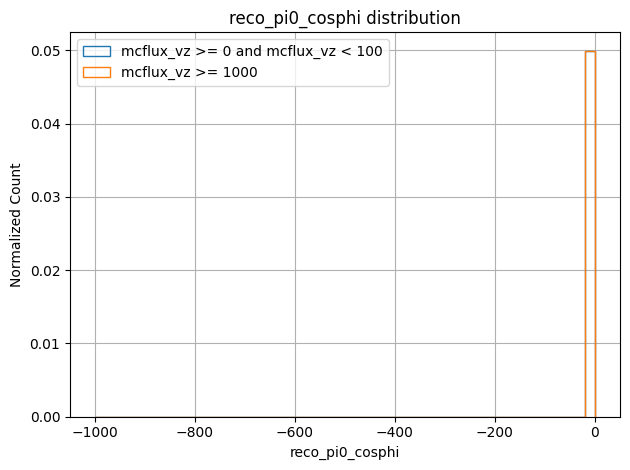

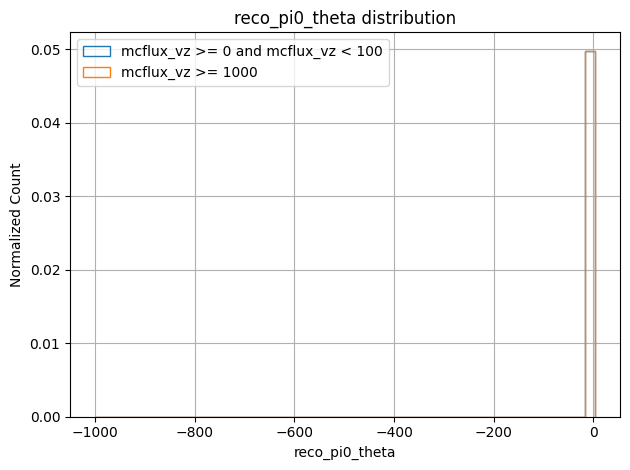

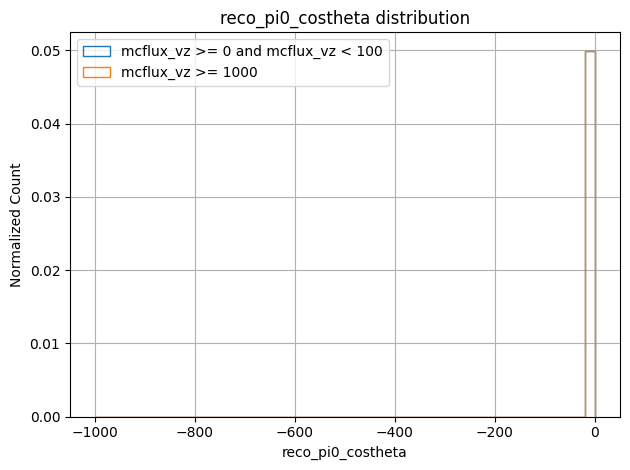

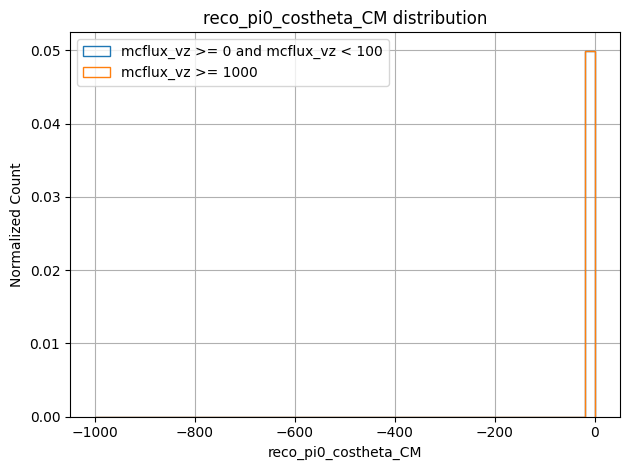

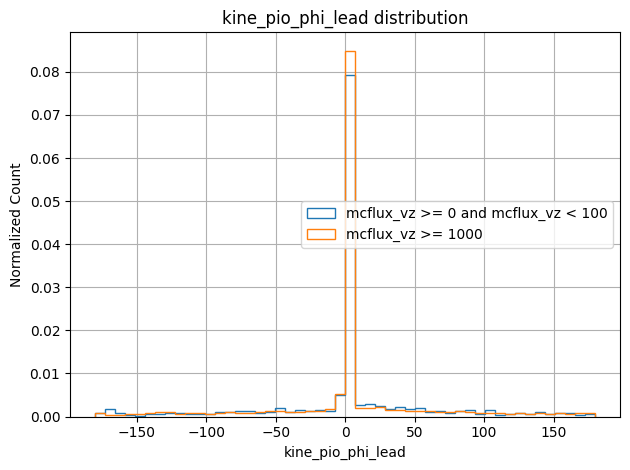

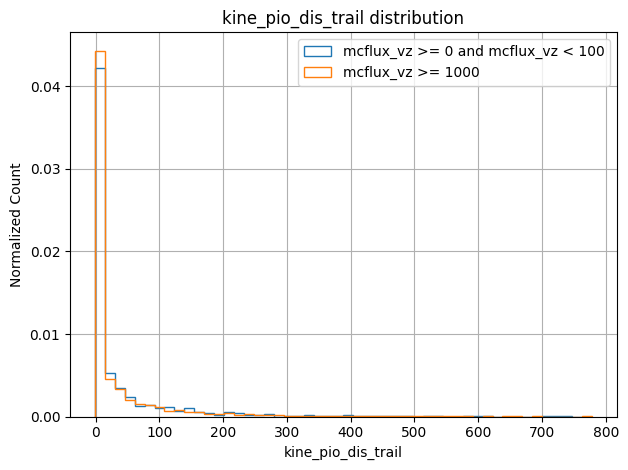

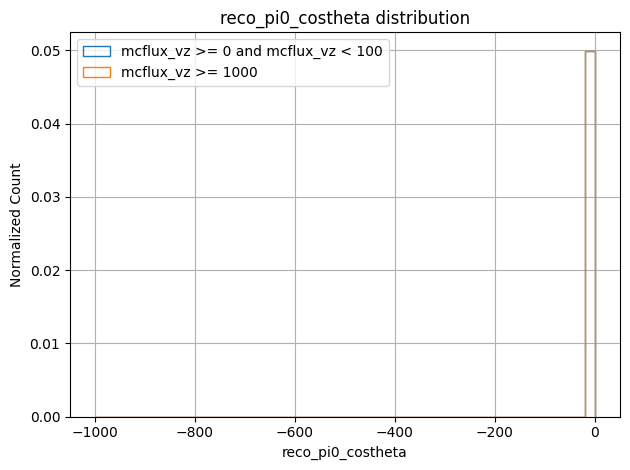

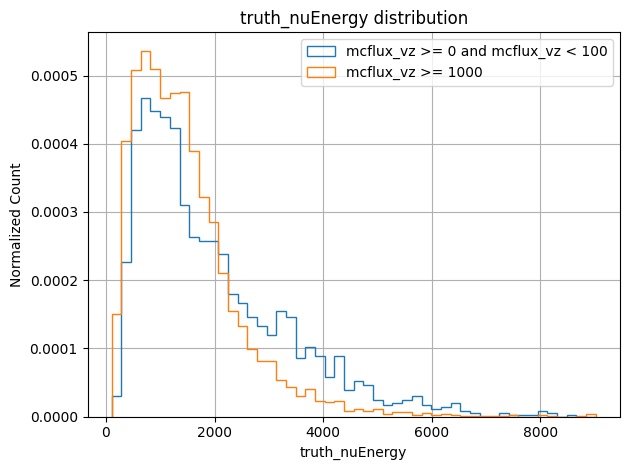

In [128]:
for var in variables_to_hist:
    plt.figure()
    all_data = df_numi_mc.query(sel)[var].dropna()
    min_val, max_val = all_data.min(), all_data.max()
    bins = np.linspace(min_val, max_val, 51)
    for sel in selections:
        data = df_numi_mc.query(sel)[var].dropna()
        data = data[~data.isin([-999, -9999, -1000])]
        plt.hist(data, bins=bins, histtype='step', density=True, label=sel)
    plt.title(f"{var} distribution")
    plt.xlabel(var)
    plt.ylabel("Normalized Count")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [89]:
def plot_merge_time_spread_double( x_var, bins, nbins=18, selection_query=CCpi0_query):
    decay_selection = "merge_time_truth<-4 or merge_time_truth>3"
    target_selection = "merge_time_truth>-4 and merge_time_truth<3"
    base_selections = ["numu_score > 0.9", CCpi0_query, NCpi0_query, "nue_score > 4"]
    selections_decay = [f"({sel}) and ({decay_selection})" for sel in base_selections]
    selections_target = [f"({sel}) and ({target_selection})" for sel in base_selections]
    
    for selection in selections_decay:
        selection_query = selection
        means_data, mean_errors_data, stds_data, std_errors_data = get_stats(
            df_numi_mc, selection_query, x_var, "merge_time", bins, nbins
        )
        label_select = "CCpi0"
        marker_select = "o"
        color_data = "blue"
        color_mc = "cyan"
        if selection_query == f"({NCpi0_query}) and ({decay_selection})":
            label_select = "NCpi0"
            marker_select = "s"
            color_data = "red"
            color_mc = "orange"
        if selection_query == f"(numu_score > 0.9) and ({decay_selection})":
            label_select = "NumuCC"
            marker_select = "D"
            color_data = "green"
            color_mc = "lime"
        if selection_query == f"(nue_score > 4) and ({decay_selection})":
            label_select = "NueCC"
            marker_select = "v"
            color_data = "purple"
            color_mc = "violet"
        bin_centers = get_bin_centers(bins)
        plt.title("Numi MC Decay Pipe: " + x_var)
        plt.errorbar(bin_centers, means_data, yerr=mean_errors_data, lw=0, ms=5, marker = marker_select, elinewidth=1, label="Data " + label_select, color = color_data)
        plt.xlabel(x_var)
        plt.ylabel("Mean Merged Time (ns)")
        plt.axhline(0, color='gray', linestyle=':', linewidth=1, alpha=0.5) 
        plt.legend(loc='upper left')
        
    plt.show() 
    
    for selection in selections_target:
        selection_query = selection
        means_data, mean_errors_data, stds_data, std_errors_data = get_stats(
            df_numi_mc, selection_query, x_var, "merge_time", bins, nbins
        )
        label_select = "CCpi0"
        marker_select = "o"
        color_data = "blue"
        color_mc = "cyan"
        if selection_query == f"({NCpi0_query}) and ({target_selection})":
            label_select = "NCpi0"
            marker_select = "s"
            color_data = "red"
            color_mc = "orange"
        if selection_query == f"(numu_score > 0.9) and ({target_selection})":
            label_select = "NumuCC"
            marker_select = "D"
            color_data = "green"
            color_mc = "lime"
        if selection_query == f"(nue_score > 4) and ({target_selection})":
            label_select = "NueCC"
            marker_select = "v"
            color_data = "purple"
            color_mc = "violet"
        bin_centers = get_bin_centers(bins)
        plt.title("Numi MC Target: " + x_var)
        plt.errorbar(bin_centers, means_data, yerr=mean_errors_data, lw=0, ms=5, marker = marker_select, elinewidth=1, label="Data " + label_select, color = color_data)
        plt.xlabel(x_var)
        plt.ylabel("Mean Merged Time (ns)")
        plt.axhline(0, color='gray', linestyle=':', linewidth=1, alpha=0.5) 
        plt.legend(loc='upper left')

In [90]:
'''plot_merge_time_spread_double("reco_nuvtxX", np.linspace(0, 250, 6), 15)
plt.show()

plot_merge_time_spread_double("reco_nuvtxY", np.linspace(-120,120, 6), 10)
plt.show()

plot_merge_time_spread_double("reco_nuvtxZ", np.linspace(0, 1100, 6), 20)
plt.show()

plot_merge_time_spread_double("kine_reco_Enu", np.linspace(0, 2000, 6), 40)
plt.show()

plot_merge_time_spread_double("Ehadron", np.linspace(0,2500, 6), 40)
plt.show()

plot_merge_time_spread_double("reco_proton_costheta", np.linspace(-1,1,6), 90)
plt.show()

plot_merge_time_spread_double("reco_proton_phi", np.linspace(-np.pi, np.pi, 6), 30)
plt.show()

#[0, 250, 400, 550, 700, 900, 2000], low stats(most in -1000)
plot_merge_time_spread_double("reco_Emuon", np.linspace(0, 2000, 6), 20)
plt.show()

#muon doesn't apply to pi0
plot_merge_time_spread_double("reco_muon_costheta", np.linspace(-1, 1, 6), 60)
plt.show()

plot_merge_time_spread_double("reco_muon_phi", np.linspace(-np.pi, np.pi, 6), 30)
plt.show()

plot_merge_time_spread_double("pio_mass", np.linspace(0, 300, 6), 40)
plt.show()

#plot_merge_time_spread("kine_pio_vtx_dis", np.linspace(0, 30, 6), 80) high grouping

plot_merge_time_spread_double("kine_pio_energy_1", np.linspace(0, 600, 6), 100)
plt.show()

plot_merge_time_spread_double("kine_pio_energy_2", np.linspace(0, 600, 6), 100)
plt.show()

plot_merge_time_spread_double("kine_pio_theta_1", np.linspace(0, 180, 6), 80)
plt.show()

plot_merge_time_spread_double("kine_pio_theta_2", np.linspace(0, 180, 6), 70)
plt.show()

plot_merge_time_spread_double("kine_pio_phi_1", np.linspace(-2*np.pi, 2*np.pi, 6), 80)
plt.show()

plot_merge_time_spread_double("kine_pio_dis_1", np.linspace(0, 100, 6), 30)
plt.show()

plot_merge_time_spread_double("kine_pio_dis_2", np.linspace(0, 100, 6), 30)
plt.show()

plot_merge_time_spread_double("kine_pio_angle", np.linspace(0, 180, 6), 80)
plt.show()

plot_merge_time_spread_double("kine_reco_Enu", np.linspace(0, 2000, 6), 40)
plt.show()'''

'plot_merge_time_spread_double("reco_nuvtxX", np.linspace(0, 250, 6), 15)\nplt.show()\n\nplot_merge_time_spread_double("reco_nuvtxY", np.linspace(-120,120, 6), 10)\nplt.show()\n\nplot_merge_time_spread_double("reco_nuvtxZ", np.linspace(0, 1100, 6), 20)\nplt.show()\n\nplot_merge_time_spread_double("kine_reco_Enu", np.linspace(0, 2000, 6), 40)\nplt.show()\n\nplot_merge_time_spread_double("Ehadron", np.linspace(0,2500, 6), 40)\nplt.show()\n\nplot_merge_time_spread_double("reco_proton_costheta", np.linspace(-1,1,6), 90)\nplt.show()\n\nplot_merge_time_spread_double("reco_proton_phi", np.linspace(-np.pi, np.pi, 6), 30)\nplt.show()\n\n#[0, 250, 400, 550, 700, 900, 2000], low stats(most in -1000)\nplot_merge_time_spread_double("reco_Emuon", np.linspace(0, 2000, 6), 20)\nplt.show()\n\n#muon doesn\'t apply to pi0\nplot_merge_time_spread_double("reco_muon_costheta", np.linspace(-1, 1, 6), 60)\nplt.show()\n\nplot_merge_time_spread_double("reco_muon_phi", np.linspace(-np.pi, np.pi, 6), 30)\nplt.sho

In [99]:
print(df_numi_mc.query("merge_time_truth<-4 or merge_time_truth>3")["truth_nuPdg"].value_counts())
print(df_numi_mc.query("merge_time_truth>-4 and merge_time_truth<3")["truth_nuPdg"].value_counts())


truth_nuPdg
 14    1721
-14     372
 12     112
-12      34
Name: count, dtype: int64
truth_nuPdg
 14    10626
-14     2244
 12      596
-12      152
Name: count, dtype: int64


In [100]:
print(df_numi_mc.query("merge_time_truth<-4 or merge_time_truth>3")["truth_nuPdg"].value_counts()/df_numi_mc.query("merge_time_truth<-4 or merge_time_truth>3").shape[0])
print(df_numi_mc.query("merge_time_truth>-4 and merge_time_truth<3")["truth_nuPdg"].value_counts()/df_numi_mc.query("merge_time_truth>-4 and merge_time_truth<3").shape[0])


truth_nuPdg
 14    0.768647
-14    0.166146
 12    0.050022
-12    0.015185
Name: count, dtype: float64
truth_nuPdg
 14    0.780291
-14    0.164782
 12    0.043766
-12    0.011162
Name: count, dtype: float64


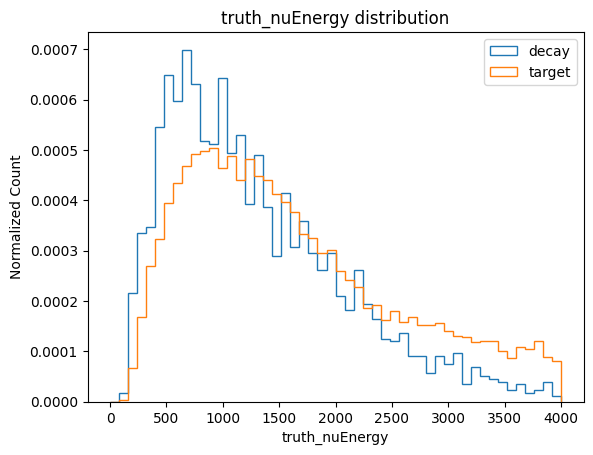

In [92]:
selections = [
    "merge_time_truth<-4 or merge_time_truth>3",
    "merge_time_truth>-4 and merge_time_truth<3"
]
plt.hist(df_numi_mc.query("merge_time_truth<-4 or merge_time_truth>3")["truth_nuEnergy"], label="decay",bins=50, histtype='step', density=True, range=(0,4000))
plt.hist(df_numi_mc.query("merge_time_truth>-4 and merge_time_truth<3")["truth_nuEnergy"], label="target",bins=50, histtype='step', density=True, range=(0,4000))
plt.ylabel("Normalized Count")
plt.xlabel("truth_nuEnergy")
plt.title("truth_nuEnergy distribution")
plt.legend()
plt.show()

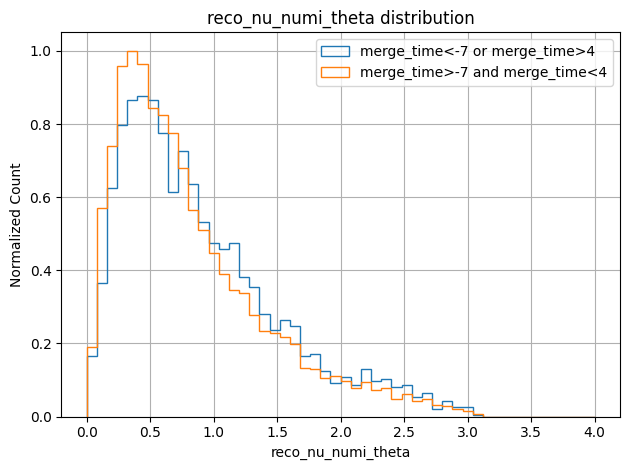

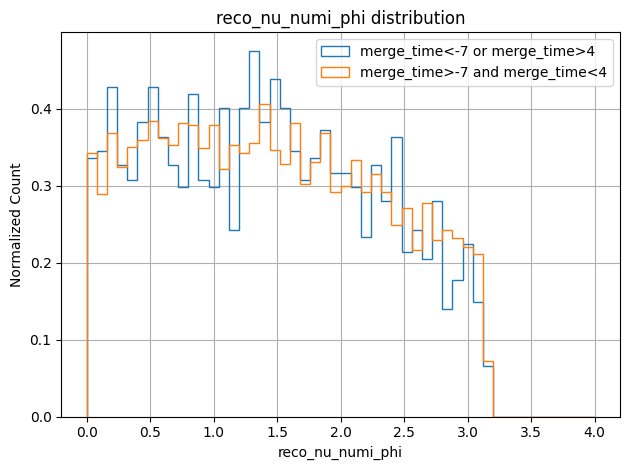

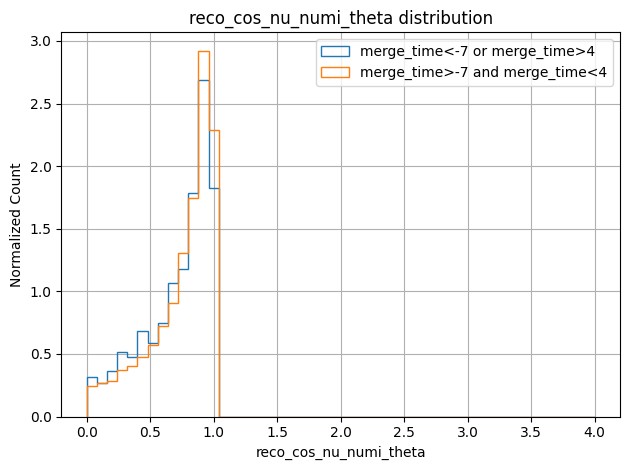

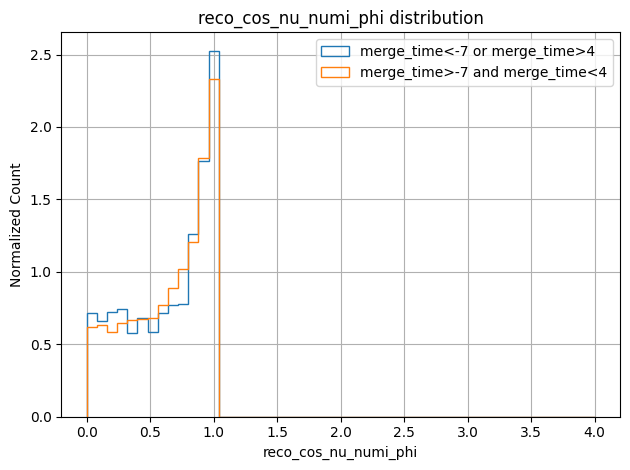

In [101]:
variables_to_hist = [
    "reco_nu_numi_theta", "reco_nu_numi_phi", "reco_cos_nu_numi_theta", "reco_cos_nu_numi_phi"
]

selections = [
    "merge_time<-7 or merge_time>4",
    "merge_time>-7 and merge_time<4"
]


for var in variables_to_hist:
    plt.figure()
    for sel in selections:
        data = df_numi_mc.query(sel)[var].dropna()
        plt.hist(data, range=(0,4), bins=50, histtype='step', density=True, label=sel)
    plt.title(f"{var} distribution")
    plt.xlabel(var)
    plt.ylabel("Normalized Count")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()